# Middle-Power AI Proliferation Preparedness Index (M-PAPI)

**Companion notebook to** *AI-Proliferation and Middle Powers: Preparation and Response Mechanisms* (Teague, Ali, Sfeir, Fort — working paper).

This notebook empirically operationalises the three-axes framework introduced in §1 of the working paper — **Capacity Depth**, **Governance Orientation**, and **Infrastructure Posture** — across the 14 middle powers named in the paper. It produces:

1. Per-country axis scores under three weighting schemes (equal, PCA-derived, literature-elicited)
2. A composite preparedness index with sensitivity ranges
3. A vulnerability overlay mapping each country to the three attack vectors discussed in §2 (cyber, CBRN, influence operations)
4. Sixteen figures (`figures/`) supporting paper-side discussion

**Methodology:** OECD/JRC *Handbook on Constructing Composite Indicators* (2008) — 10-step process with explicit transparency on weighting, normalization, and sensitivity.

**Data sources:** **12 of the 15 indicators are fully sourced from Tier-1 institutional providers with no analyst-coding step** (11 programmatic + 1 inlined against the cited URL): programmatic via API or CSV — Epoch AI (C1, C2), OpenAlex (C3), ITU GCI via World Bank Data360 (G2), V-Dem (G3), IGSC homepage scrape (G5), World Bank WDI (I2, I3), ND-GAIN (I5) — and deterministic extraction from a published source via dedicated helper scripts — ITU IDI 2024 report PDF Table 1 (I1, via `extract_idi_from_pdf.py`) and Stanford AI Index 2025 Figure 1.2.3 (C4, via `extract_patents_from_pdf.py`); plus Australia Group public roster (G6, inlined against the cited URL because the upstream page is intermittently unreliable for programmatic fetch). **3 indicators (G1, G4, C5) carry an analyst-coding step**: G1 (national AI strategy comprehensiveness, 0–3 rubric over OECD.AI dashboards), G4 (bilateral lab MoU count, authors' enumeration of public announcements), and C5 (binary AISI Network membership is authoritative from the NIST fact sheet; the 0/1/2 ordinal extension for non-Network states is authors' coding). G1 and G4 are flagged `requires_verification: True` in the §4.9 `EXTRACTIONS` registry; C5's coding caveat is in the same registry's notes. Their literature-scheme weights (G1 20%, G4 10%, C5 25% within their respective axes) are documented in §3.2; the §12.2 leave-one-indicator-out test shows the top-5 set is unchanged when any of the three is dropped, with the largest reshuffle at the 6–8 boundary under G1 drop (Germany rises from 8 to 6, Singapore drops from 7 to 8; see §17 limitation 5 for the full LOO results). Every value (whether programmatic or coded) cites a URL with retrieval date in `data/raw/*.meta.json` or in §4.9's `EXTRACTIONS` block; the full bibliography is in §19.

**Reproducibility:** four stochastic entry points are seeded with `SEED = 20260506` (§3.1): `np.random.default_rng(SEED)` for the Monte Carlo weights (§12.1), `KMeans(random_state=SEED)` for the k-means typology (§14), `MDS(random_state=SEED, n_init=20)` for the §14.3 embedding, and `SparsePCA(random_state=SEED)` for the §16.10 governance sub-axes; `pip install -r requirements.txt && jupyter nbconvert --to notebook --execute --inplace M-PAPI.ipynb` reproduces all outputs to floating-point precision. §18 contains four post-execution verification checks, including a full GBR composite reconstruction asserted to within 1e-3 of the stored scoreboard value.

## 1. Introduction & Mapping to Working Paper

### 1.1 Why this index exists

The working paper §1 names 14 middle powers — UK, Canada, France, Germany, Japan, India, Israel, Singapore, South Korea, Sweden, Saudi Arabia, UAE, EU, Taiwan — and argues they differ along three axes:

> *"This paper identifies three axes that are most directly predictive of how AI-enabled threats materialise and how responses fail."* (working paper §1)

But the paper never empirically positions any of these 14 countries on those axes. The §4 preparedness checklist repeatedly invokes "tractability depending on a country's position within the 3 axes" without ever specifying any country's position.

This notebook closes that gap. It is not new theory — it provides empirical scaffolding for the paper's existing framework, making the per-country claims auditable, replicable, and updatable as the threat landscape evolves.

### 1.2 What the notebook does — and does not — claim

**Does claim:**
- Each of the 14 middle powers can be ranked on each of the three axes using publicly available authoritative data.
- The relative position of countries is robust to reasonable variation in weighting and normalization.
- A k-means typology of axis-position archetypes (§14) is reported alongside its cluster-validity diagnostics (silhouette score, hierarchical-clustering ARI in §14.2).

**Does not claim:**
- That the index predicts which country will suffer the next AI-enabled incident.
- That a high score means a country is "safe."
- That all relevant dimensions of preparedness are captured (see §17 Limitations).

### 1.3 Cross-reference table (paper → notebook)

| Paper section | What is asserted there | Where this notebook empirically supports it |
|---|---|---|
| §1 three axes (defined) | Conceptual framework | §6 (indicator construction), §11 (composite) |
| §1 14 middle powers (listed) | Named, not differentiated | §11, §15 (per-country positions) |
| §1 AISI Network significance | "Establishment of AISIs" matters | §6 C5 (AISI presence ordinal), §15.2 (AISI as marker variable) |
| §2.2 cyber asymmetry | Mythos/Glasswing asymmetry | §13 (cyber column of vulnerability overlay), Figure 15.3 |
| §2.3 CBRN uplift | Capacity + biosecurity governance | §13 (CBRN column of vulnerability overlay), Figure 15.3 |
| §2.4 influence operations | Verification asymmetry | §13 (influence-ops column of vulnerability overlay), Figure 15.3 |
| §4 detection/escalation/mitigation | "Tractability depends on axis position" | §11, §13 (now quantified, not asserted); §13.4 per-country counterfactual policy scenarios |

### 1.4 Research questions and falsifiable hypotheses

The working paper §1 advances a three-axes framework qualitatively. This notebook tests six empirical claims that follow from that framework, each with a pre-specified evaluation criterion. Aggregate results are reported in §16.11 (Hypothesis Testing Results); per-hypothesis evidence is detailed in the cited sections.

| ID | Hypothesis | Operational test | Pass criterion | Reported in |
|---|---|---|---|---|
| H1 | The three axes are empirically separable (not redundant). | Cross-axis Pearson correlations between indicators; cross-axis correlations should be lower than within-axis correlations on average. | Fewer than 5 of 74 cross-axis pairs with \|r\| ≥ 0.7. | §17.9, Appendix A.1 |
| H2 | Each axis carries a one-dimensional latent signal. | Horn's parallel analysis on per-axis PCA; PC1 explained variance vs permutation null. | PA p < 0.05 for each axis. | §8, §8.1, §16.1 |
| H3 | The 14 middle powers do not cluster as a homogeneous group. | K-means with silhouette-selected k; ARI vs hierarchical clustering. | Silhouette > 0.20 and k-means × hierarchical ARI > 0.50. | §14, §14.2 |
| H4 | The headline ranking is robust to reasonable methodological perturbation. | Spearman ρ across weighting schemes, normalisation, and bibliographic classifier; Fisher-z 95% CI lower bound must clear the threshold. | All four robustness ρ values' 95% CI lower bound > 0.70 (or > 0.85 for the classifier-sensitivity case). | §12.4, §17.10 |
| H5 | Analyst-judgment indicators (G1, G4) and the AISI marker (C5) are not sole drivers of the top-5 ranking. | Leave-one-indicator-out test, equal-within-axis weights. | Maximum top-5 set change ≤ 1 country when any of G1, G4, C5 is dropped. | §12.2, §17.5 |
| H6 | Top-5 and bottom-3 *tier membership* is stable under within-axis weight perturbation. | Dirichlet Monte Carlo over within-axis weights (10,000 draws, §12.1); per-country in-tier frequency, exact-set-match share, and within-1-swap share computed in §16.11 and persisted to `outputs/h6_set_membership.json`. | At least four of the five baseline top-5 countries appear in the top-5 in ≥ 70% of the 10,000 draws; at least two of the three baseline bot-3 countries appear in the bot-3 in ≥ 80% of draws. The 5th slot (Japan / EU / Singapore) and 12th slot (Israel / Saudi Arabia) are weight-sensitive — Israel is the single baseline-tier country that falls below 70% (62% in bot-3, swapped with Saudi in 38% of draws). The strict exact-set-match rate is 46% / 43%; reported as evidence of partial support, not as a pass criterion. | §12.1, §15.4, §16.11 |

Each hypothesis maps to a specific notebook section with a numeric criterion. The hypotheses are pre-registered in this section rather than back-derived from results — partial-support outcomes are surfaced explicitly in §16.11.


## 2. Conceptual Framework

### 2.1 The Three Axes

| Axis | Definition (per paper §1) | Indicators (this notebook) |
|---|---|---|
| **Capacity Depth** | Domestic technical talent, AISI-equivalent institutions, and AI R&D output. | C1 Notable models · C2 Training compute · C3 AI publications · C4 AI patents · C5 AISI presence |
| **Governance Orientation** | AI governance maturity, alliance posture, and bilateral lab agreements. | G1 National AI strategy · G2 ITU GCI · G3 V-Dem LDI · G4 Lab MoU count · G5 IGSC member firms · G6 Australia Group membership |
| **Infrastructure Posture** | Domestic compute, ICT infrastructure, and platform/cloud presence under jurisdictional reach. | I1 ITU IDI · I2 Broadband · I3 Secure servers · I5 ND-GAIN Readiness (I4 compute-hosted dropped — see §4.2 note) |

### 2.2 The Three Attack Vectors (paper §2)

The vulnerability overlay (§13 of this notebook) maps axis scores to per-country exposure on each vector. Vector-specific axis weights are documented in §3.2 under `VULN_OVERLAY`.

| Vector | Paper section | Axis emphasis | Why |
|---|---|---|---|
| Cyber | §2.2 | Capacity 0.40 · Gov 0.25 · Infra 0.35 | Defensive AI capacity + monitoring infrastructure both load-bearing; GCI captures national cyber posture. |
| CBRN | §2.3 | Capacity 0.50 · Gov 0.40 · Infra 0.10 | Verification of dual-use models requires deep capacity; biosecurity governance (IGSC) is the second-largest factor. Infrastructure plays a smaller role. |
| Influence ops | §2.4 | Capacity 0.20 · Gov 0.35 · Infra 0.45 | Open distribution infrastructure dominates exposure; democratic resilience (V-Dem) and platform governance posture provide the main mitigations. |

### 2.3 Why a composite — and its limits

Composite indices are commonly criticised on their weighting choices. The defence is **not** to claim the chosen weights are correct; it is to:

1. Report multiple weighting schemes side-by-side (equal, PCA-derived, literature-elicited)
2. Quantify rank stability under Monte Carlo perturbation (§12)
3. Make the indicator-to-axis mapping fully transparent (`INDICATORS` in §3.2)
4. Maintain end-to-end source traceability (`EXTRACTIONS` in §4.9 + bibliography in §19)

The OECD/JRC handbook is explicit that a composite index should not be presented as a single number without accompanying sensitivity ranges. This notebook follows that principle throughout: §11 reports three composites side-by-side, §12 quantifies their sensitivity, and §15.4 visualises the rank distribution per country.

## 3. Methodology Overview — OECD/JRC 10-Step Process

The notebook follows the OECD/JRC *Handbook on Constructing Composite Indicators: Methodology and User Guide* (2008). Each step has a dedicated section:

| Step | OECD/JRC stage | Notebook section |
|---|---|---|
| 1 | Theoretical framework | §1, §2 (already in paper §1) |
| 2 | Data selection | §4 (acquisition) |
| 3 | Imputation of missing data | §7 |
| 4 | Multivariate analysis | §8 |
| 5 | Normalization | §9 |
| 6 | Weighting | §10 |
| 7 | Aggregation | §11 |
| 8 | Robustness/sensitivity | §12 |
| 9 | Back to the data (interpretation) | §13, §14, §16 |
| 10 | Visualization | §15 |

Sections §16–§18 add discussion, limitations, and a reproducibility verification.

### 3.1 Setup — imports, seeds, paths

In [1]:
# Standard scientific stack
import io
import json
from datetime import date
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests  # type: ignore[import-untyped]
import seaborn as sns

# Reproducibility
# Random-seed entry points (all four pass SEED explicitly; no global np.random.seed is set):
#   - np.random.default_rng(SEED) for the §12.1 Monte Carlo weights
#   - KMeans(random_state=SEED) for the §14 k-means typology
#   - MDS(random_state=SEED, n_init=20) for the §14.3 embedding
#   - SparsePCA(random_state=SEED) for the §16.10 governance sub-axes
SEED = 20260506  # date of first construction; held constant across reruns.

# Methodology thresholds. Each value documents one decision point in the analytical
# pipeline; revising any of these means a single edit here rather than a code search.
IMPUTATION_THRESHOLD = 0.30  # max indicator-level missingness imputed by §7
PCA_ONE_DIM_THRESHOLD = 0.50  # PC1 explained-variance threshold for §8 / §16.1
ROBUSTNESS_RHO_THRESHOLD = (
    0.70  # Spearman ρ threshold for weighting / normalisation robustness (§12)
)
CLASSIFIER_RHO_THRESHOLD = (
    0.85  # Spearman ρ threshold for classifier-sensitivity check (§16.7.1)
)
GEOMETRIC_SHIFT_EPS = (
    1e-3  # offset added to shifted axis scores before geometric mean (§11)
)
NUMERICAL_NOISE_EPS = 1e-9  # treat |z| < eps as 'at mean' in archetype labelling (§14)

# Paths — absolute relative to notebook location
NB_ROOT = Path.cwd()
DATA_RAW = NB_ROOT / "data" / "raw"
FIG_DIR = NB_ROOT / "figures"
OUT_DIR = NB_ROOT / "outputs"
for d in (DATA_RAW, FIG_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)


# Retrieval date stamped into all outputs
RUN_DATE = date.today().isoformat()
print(f"M-PAPI build run: {RUN_DATE}")
print(f"Random seed: {SEED}")
print(f"Working directory: {NB_ROOT.name}")

# Plot defaults — publication-grade styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.labelweight"] = "regular"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = ["DejaVu Sans", "Arial", "sans-serif"]

M-PAPI build run: 2026-05-18
Random seed: 20260506
Working directory: middle-powers-index


### 3.2 Configuration — jurisdictions, indicators, weights, vulnerability overlay

All weighting and structural choices for axes, indicators, and the vulnerability overlay live in this cell. Per-country values for analyst-judgment and manually-extracted indicators (C5, G1, G4, G6, C4) are in §4.9's `EXTRACTIONS` registry. Revising the analytical structure means editing this cell; revising raw country-level inputs means editing §4.9.

In [2]:
# Headline 14 middle powers per the working paper §1, with ISO3 codes and EU-member flags.
COUNTRIES = [
    {"name": "United Kingdom", "iso2": "GB", "iso3": "GBR", "is_eu_member": False},
    {"name": "Canada", "iso2": "CA", "iso3": "CAN", "is_eu_member": False},
    {"name": "France", "iso2": "FR", "iso3": "FRA", "is_eu_member": True},
    {"name": "Germany", "iso2": "DE", "iso3": "DEU", "is_eu_member": True},
    {"name": "Japan", "iso2": "JP", "iso3": "JPN", "is_eu_member": False},
    {"name": "India", "iso2": "IN", "iso3": "IND", "is_eu_member": False},
    {"name": "Israel", "iso2": "IL", "iso3": "ISR", "is_eu_member": False},
    {"name": "Singapore", "iso2": "SG", "iso3": "SGP", "is_eu_member": False},
    {"name": "South Korea", "iso2": "KR", "iso3": "KOR", "is_eu_member": False},
    {"name": "Sweden", "iso2": "SE", "iso3": "SWE", "is_eu_member": True},
    {"name": "Saudi Arabia", "iso2": "SA", "iso3": "SAU", "is_eu_member": False},
    {
        "name": "United Arab Emirates",
        "iso2": "AE",
        "iso3": "ARE",
        "is_eu_member": False,
    },
    {"name": "European Union", "iso2": "EU", "iso3": "EUU", "is_eu_member": False},
    {"name": "Taiwan", "iso2": "TW", "iso3": "TWN", "is_eu_member": False},
]

# Supplementary EU member states (for §15.5 cross-validation only).
EU_MEMBERS_SUPPLEMENTARY = [
    {"name": "Austria", "iso2": "AT", "iso3": "AUT"},
    {"name": "Belgium", "iso2": "BE", "iso3": "BEL"},
    {"name": "Bulgaria", "iso2": "BG", "iso3": "BGR"},
    {"name": "Croatia", "iso2": "HR", "iso3": "HRV"},
    {"name": "Cyprus", "iso2": "CY", "iso3": "CYP"},
    {"name": "Czechia", "iso2": "CZ", "iso3": "CZE"},
    {"name": "Denmark", "iso2": "DK", "iso3": "DNK"},
    {"name": "Estonia", "iso2": "EE", "iso3": "EST"},
    {"name": "Finland", "iso2": "FI", "iso3": "FIN"},
    {"name": "Greece", "iso2": "GR", "iso3": "GRC"},
    {"name": "Hungary", "iso2": "HU", "iso3": "HUN"},
    {"name": "Ireland", "iso2": "IE", "iso3": "IRL"},
    {"name": "Italy", "iso2": "IT", "iso3": "ITA"},
    {"name": "Latvia", "iso2": "LV", "iso3": "LVA"},
    {"name": "Lithuania", "iso2": "LT", "iso3": "LTU"},
    {"name": "Luxembourg", "iso2": "LU", "iso3": "LUX"},
    {"name": "Malta", "iso2": "MT", "iso3": "MLT"},
    {"name": "Netherlands", "iso2": "NL", "iso3": "NLD"},
    {"name": "Poland", "iso2": "PL", "iso3": "POL"},
    {"name": "Portugal", "iso2": "PT", "iso3": "PRT"},
    {"name": "Romania", "iso2": "RO", "iso3": "ROU"},
    {"name": "Slovakia", "iso2": "SK", "iso3": "SVK"},
    {"name": "Slovenia", "iso2": "SI", "iso3": "SVN"},
    {"name": "Spain", "iso2": "ES", "iso3": "ESP"},
]

# Indicator definitions — for each indicator, axis assignment, pre-normalisation
# transformation, and polarity (all higher_is_better in this configuration). Reference
# year and source per indicator are documented in §5.3 and §19 respectively.
INDICATORS = [
    # Capacity Depth
    {
        "id": "C1_notable_models",
        "axis": "capacity_depth",
        "transformation": "log1p",
        "polarity": "higher_is_better",
    },
    {
        "id": "C2_training_compute",
        "axis": "capacity_depth",
        "transformation": "log1p",
        "polarity": "higher_is_better",
    },
    {
        "id": "C3_ai_publications",
        "axis": "capacity_depth",
        "transformation": "log1p",
        "polarity": "higher_is_better",
    },
    {
        "id": "C4_ai_patents",
        "axis": "capacity_depth",
        "transformation": "log1p",
        "polarity": "higher_is_better",
    },
    {
        "id": "C5_aisi_presence",
        "axis": "capacity_depth",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    # Governance Orientation
    {
        "id": "G1_ai_strategy",
        "axis": "governance_orientation",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "G2_global_cybersec_index",
        "axis": "governance_orientation",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "G3_vdem_libdem",
        "axis": "governance_orientation",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "G4_lab_mou_count",
        "axis": "governance_orientation",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "G5_igsc_membership",
        "axis": "governance_orientation",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "G6_australia_group",
        "axis": "governance_orientation",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    # Infrastructure Posture (I4 dropped — see §17 future-work)
    {
        "id": "I1_idi_2024",
        "axis": "infrastructure_posture",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "I2_broadband",
        "axis": "infrastructure_posture",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
    {
        "id": "I3_secure_servers",
        "axis": "infrastructure_posture",
        "transformation": "log1p",
        "polarity": "higher_is_better",
    },
    {
        "id": "I5_ndgain_readiness",
        "axis": "infrastructure_posture",
        "transformation": "none",
        "polarity": "higher_is_better",
    },
]

# Three weighting schemes are reported side-by-side; two of them (equal-weight baseline and
# literature-elicited from GMF Pivotal Powers / Chatham House Sovereign AI / Tortoise Global AI)
# are stored here as fixed dicts. The third (PCA-derived) is computed at runtime in §10
# from the data and persisted to outputs/weights_pca_runtime.json.
WEIGHTS = {
    "equal": {
        "indicator_weights": {
            "capacity_depth": {
                "C1_notable_models": 0.20,
                "C2_training_compute": 0.20,
                "C3_ai_publications": 0.20,
                "C4_ai_patents": 0.20,
                "C5_aisi_presence": 0.20,
            },
            "governance_orientation": dict.fromkeys(
                (
                    "G1_ai_strategy",
                    "G2_global_cybersec_index",
                    "G3_vdem_libdem",
                    "G4_lab_mou_count",
                    "G5_igsc_membership",
                    "G6_australia_group",
                ),
                1 / 6,
            ),
            "infrastructure_posture": {
                "I1_idi_2024": 0.25,
                "I2_broadband": 0.25,
                "I3_secure_servers": 0.25,
                "I5_ndgain_readiness": 0.25,
            },
        },
        "axis_weights": {
            "capacity_depth": 1 / 3,
            "governance_orientation": 1 / 3,
            "infrastructure_posture": 1 / 3,
        },
    },
    "literature": {
        "indicator_weights": {
            "capacity_depth": {
                "C1_notable_models": 0.30,
                "C2_training_compute": 0.25,
                "C3_ai_publications": 0.10,
                "C4_ai_patents": 0.10,
                "C5_aisi_presence": 0.25,
            },
            "governance_orientation": {
                "G1_ai_strategy": 0.20,
                "G2_global_cybersec_index": 0.30,
                "G3_vdem_libdem": 0.20,
                "G4_lab_mou_count": 0.10,
                "G5_igsc_membership": 0.10,
                "G6_australia_group": 0.10,
            },
            "infrastructure_posture": {
                "I1_idi_2024": 0.40,
                "I2_broadband": 0.20,
                "I3_secure_servers": 0.20,
                "I5_ndgain_readiness": 0.20,
            },
        },
        "axis_weights": {
            "capacity_depth": 0.40,
            "governance_orientation": 0.30,
            "infrastructure_posture": 0.30,
        },
    },
}

# Per-vector axis weights (paper §2): sum to 1 within each vector.
VULN_OVERLAY = {
    "cyber": {
        "weights": {
            "capacity_depth": 0.40,
            "governance_orientation": 0.25,
            "infrastructure_posture": 0.35,
        }
    },
    "cbrn": {
        "weights": {
            "capacity_depth": 0.50,
            "governance_orientation": 0.40,
            "infrastructure_posture": 0.10,
        }
    },
    "influence_ops": {
        "weights": {
            "capacity_depth": 0.20,
            "governance_orientation": 0.35,
            "infrastructure_posture": 0.45,
        }
    },
}

# Build the working DataFrames the rest of the notebook consumes.
countries = pd.DataFrame(COUNTRIES)
eu_supplementary = pd.DataFrame(EU_MEMBERS_SUPPLEMENTARY)
indicators = pd.DataFrame(INDICATORS)
weights_cfg = {"schemes": WEIGHTS}
vuln_overlay = VULN_OVERLAY

print(f"Headline jurisdictions: {len(countries)}")
print(f"EU member supplementary: {len(eu_supplementary)}")
print(f"Indicators: {len(indicators)}  (axes: {indicators['axis'].nunique()})")
countries[["name", "iso3", "is_eu_member"]]

Headline jurisdictions: 14
EU member supplementary: 24
Indicators: 15  (axes: 3)


,name,iso3,is_eu_member
0,United Kingdom,GBR,False
1,Canada,CAN,False
2,France,FRA,True
3,Germany,DEU,True
4,Japan,JPN,False
5,India,IND,False
6,Israel,ISR,False
7,Singapore,SGP,False
8,South Korea,KOR,False
9,Sweden,SWE,True


## 4. Data Acquisition

This section fetches authoritative sources. Each subsection:

1. Documents the source (citation, URL, license, retrieval date).
2. Tries to fetch programmatically.
3. Caches to `data/raw/` on success.
4. Falls back to cache if the live URL is unreachable.
5. If neither works, records the gap; §5.4 missing-data audit will flag.

This is the OECD/JRC handbook step 2 (data selection) made operational.

In [3]:
# Helpers — every fetch goes through these so caching/retrieval-date logging is uniform.


def cache_path(name: str) -> Path:
    return DATA_RAW / name


def fetch_to_cache(
    url: str, cache_name: str, timeout: int = 60
) -> tuple[bytes | None, str]:
    """Fetch a URL with cache fallback and provenance metadata.

    Attempts to GET ``url`` and writes the response body to ``data/raw/<cache_name>``
    on success, alongside a ``<cache_name>.meta.json`` sidecar recording the URL,
    retrieval date, and content size. On any request failure (network, HTTP error,
    timeout), falls back to an existing cached copy if one is present.

    The ``.meta.json`` sidecar's ``retrieved_date`` is the date of the LAST SUCCESSFUL
    FETCH; a run that returns ``status="cache_hit"`` does not update it.

    Returns
    -------
    content
        The response body bytes, or ``None`` if both the live fetch and the cache failed.
    status
        One of ``"fetched_live"``, ``"cache_hit"``, or ``"unavailable"``.
    """
    cp = cache_path(cache_name)
    try:
        r = requests.get(
            url,
            timeout=timeout,
            headers={"User-Agent": "M-PAPI/1.0 (academic research)"},
        )
        r.raise_for_status()
        cp.write_bytes(r.content)
        # Record retrieval-date stub alongside the cache file.
        (cp.with_suffix(cp.suffix + ".meta.json")).write_text(
            json.dumps(
                {"url": url, "retrieved_date": RUN_DATE, "size": len(r.content)},
                indent=2,
            )
        )
        return r.content, "fetched_live"
    except (requests.RequestException, OSError) as exc:
        if cp.exists():
            return cp.read_bytes(), "cache_hit"
        print(
            f"[WARN] {cache_name}: fetch failed ({type(exc).__name__}: {exc}); no cache available."
        )
        return None, "unavailable"

### 4.1 World Bank ICT indicators (programmatic, API)

Source: World Bank World Development Indicators. License CC-BY 4.0. Provides:
- `IT.NET.BBND.P2` — Fixed broadband subscriptions per 100 people → indicator I2
- `IT.NET.SECR.P6` — Secure Internet servers per 1M people → indicator I3

In [4]:
def fetch_wb_indicator(code: str, isos: list[str]) -> pd.DataFrame:
    """Fetch one World Bank WDI indicator for the given ISO3 codes.

    Returns a long DataFrame with columns ``[iso3, year, value, indicator]`` covering
    2010–2024. Handles the WDI v2 JSON envelope, dropping rows without a year or ISO3.
    Used by §4.1 for I2 (broadband) and I3 (secure servers).
    """
    iso_param = ";".join(isos)
    url = (
        f"https://api.worldbank.org/v2/country/{iso_param}/indicator/{code}"
        f"?format=json&per_page=20000&date=2010:2024"
    )
    content, _status = fetch_to_cache(url, f"wb_{code}.json")
    if content is None:
        return pd.DataFrame(columns=["iso3", "year", "value", "indicator"])
    payload = json.loads(content)
    if not isinstance(payload, list) or len(payload) < 2:
        return pd.DataFrame(columns=["iso3", "year", "value", "indicator"])
    rows = payload[1] or []
    df = pd.DataFrame(
        [
            {
                "iso3": r.get("countryiso3code"),
                "year": int(r["date"]) if r.get("date") else None,
                "value": r.get("value"),
                "indicator": code,
            }
            for r in rows
        ]
    )
    return df.dropna(subset=["iso3", "year"])


# All ISO3s for the headline 14 (excluding EU which the WB doesn't report)
wb_isos = [c for c in countries["iso3"].tolist() if c != "EUU"]

wb_codes = ["IT.NET.BBND.P2", "IT.NET.SECR.P6"]
wb_long = pd.concat(
    [fetch_wb_indicator(c, wb_isos) for c in wb_codes], ignore_index=True
)
print(f"World Bank rows: {len(wb_long)}")
wb_long.head()

World Bank rows: 360


,iso3,year,value,indicator
0,ARE,2024,40.840114,IT.NET.BBND.P2
1,ARE,2023,37.096823,IT.NET.BBND.P2
2,ARE,2022,36.848587,IT.NET.BBND.P2
3,ARE,2021,36.500536,IT.NET.BBND.P2
4,ARE,2020,34.345290,IT.NET.BBND.P2


In [5]:
# For each (country, indicator) take the latest non-null observation.
# Some indicators (e.g., secure servers) report at irregular intervals.
wb_latest = (
    wb_long.dropna(subset=["value"])
    .sort_values(["iso3", "indicator", "year"])
    .groupby(["iso3", "indicator"], as_index=False)
    .tail(1)
)
wb_wide = wb_latest.pivot(index="iso3", columns="indicator", values="value")
print(f"WB wide shape: {wb_wide.shape}")
wb_wide

WB wide shape: (12, 2)


indicator,IT.NET.BBND.P2,IT.NET.SECR.P6
iso3,,
ARE,40.840114,4192.274084
CAN,42.523822,39712.754603
DEU,45.606924,152113.844012
FRA,48.925198,57274.636397
GBR,42.164828,68449.195389
IND,3.150463,1212.441661
ISR,29.183710,12353.023741
JPN,38.631238,32928.758084
KOR,47.801497,11902.383072


### 4.2 Epoch AI Notable Models (programmatic, CSV)

Source: Epoch AI, *Data on Notable AI Models*. License CC-BY 4.0. Country-level affiliation is read from Epoch's organisation-country column (`Country (of organization)` in the current dump; cell 15 finds it by case-insensitive substring match for forward compatibility). Multi-country attributions are split on `[,;/]\s*` and exploded — one count per attributed country (so a UK/US co-authored model contributes one count to each). Feeds C1 (notable model count) and C2 (training compute summed across the exploded country rows). Both indicators are restricted to the same recency window: models with publication year ≥ `current_year − 5` (at `RUN_DATE = 2026-05-17` this is the 2021–2026 inclusive window). The shared window is enforced inside `epoch_country_aggregates` (cell below); a prior version summed C2 cumulatively across all years in the Epoch dump, mixing pre-2021 with post-2021 models.

**Note on infrastructure compute (I4):** an earlier configuration also assigned the same Epoch compute total to I4 (compute hosted). Epoch attributes by *organisation* country, not *hosting* country, so the I4 series was numerically identical to C2 and double-counted compute across capacity_depth and infrastructure_posture. I4 has been dropped from the index; a proper compute-hosted indicator (IEA data centre electricity, SemiAnalysis ClusterMAX) is deferred to future work — see §17.

In [6]:
EPOCH_URL = "https://epoch.ai/data/all_ai_models.csv"
content, status = fetch_to_cache(EPOCH_URL, "epoch_notable_models.csv")
if content is not None:
    epoch = pd.read_csv(io.BytesIO(content))
    print(f"Epoch AI rows: {len(epoch):,}  (status: {status})")
    print(
        f"Columns of interest: {[c for c in epoch.columns if 'country' in c.lower() or 'compute' in c.lower() or 'date' in c.lower() or 'org' in c.lower()][:8]}"
    )
else:
    print("[WARN] Epoch AI unavailable; C1 and C2 will be missing.")
    epoch = pd.DataFrame()
epoch.head()  # safe on empty DataFrame; prints column headers only when len(epoch) == 0

Epoch AI rows: 3,525  (status: fetched_live)
Columns of interest: ['Organization', 'Publication date', 'Training compute (FLOP)', 'Training compute notes', 'Country (of organization)', 'Finetune compute (FLOP)', 'Finetune compute notes', 'Training cloud compute vendor']


,Model,Domain,Task,Organization,Authors,Publication date,Reference,Link,Citations,Notability criteria,...,Utilization notes,Numerical format,Frontier model,Training power draw (W),Training compute estimation method,Hugging Face developer id,Post-training compute (FLOP),Post-training compute notes,Hardware utilization (HFU),Open model weights?
0,DeepSeek-V4-Pro,Language,"Language modeling/generation,Question answering",DeepSeek,NaN,2026-04-24,DeepSeek-V4: Towards Highly Efficient Million-...,https://huggingface.co/deepseek-ai/DeepSeek-V4...,NaN,Discretionary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
1,DeepSeek-V4-Flash,Language,"Language modeling/generation,Question answering",DeepSeek,NaN,2026-04-24,DeepSeek-V4: Towards Highly Efficient Million-...,https://huggingface.co/deepseek-ai/DeepSeek-V4...,NaN,Discretionary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
2,GPT-5.5 Pro,"Multimodal,Language,Vision","Language modeling/generation,Question answering",OpenAI,NaN,2026-04-23,Introducing GPT‑5.5,https://openai.com/index/introducing-gpt-5-5/,NaN,Discretionary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
3,GPT-5.5,"Multimodal,Language,Vision","Language modeling/generation,Question answering",OpenAI,NaN,2026-04-23,Introducing GPT‑5.5,https://openai.com/index/introducing-gpt-5-5/,NaN,Significant use,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
4,Grok Voice Think Fast 1.0,Audio,Speech-to-speech,xAI,NaN,2026-04-23,Grok Voice Think Fast 1.0,https://x.ai/news/grok-voice-think-fast-1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [7]:
# Map Epoch country names (and other free-text country strings used elsewhere) to ISO3.
# Epoch's country field is a string like 'United Kingdom of Great Britain and Northern Ireland'
# or sometimes a comma-separated multi-country list for joint-affiliation models.
import pycountry

# Module-level alias table — built once and reused on every to_iso3() call.
# Covers (a) UN-long-form country names, (b) commonly-seen shorthands, and
# (c) jurisdictions for which pycountry.lookup is unreliable (Taiwan, EU).
ISO3_ALIASES: dict[str, str] = {
    "United States of America": "USA",
    "United States": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "GBR",
    "United Kingdom": "GBR",
    "UK": "GBR",
    "Russian Federation": "RUS",
    "Russia": "RUS",
    "Korea, Republic of": "KOR",
    "South Korea": "KOR",
    "Republic of Korea": "KOR",
    "Iran, Islamic Republic of": "IRN",
    "Taiwan, Province of China": "TWN",
    "Taiwan": "TWN",
    "Czechia": "CZE",
    "Czech Republic": "CZE",
    "European Union": "EUU",
    "Hong Kong": "HKG",
    "Hong Kong SAR China": "HKG",
    "United Arab Emirates": "ARE",
}


def to_iso3(name: str) -> str | None:
    """Resolve a free-text country name to its ISO 3166-1 alpha-3 code.

    Returns ``None`` for empty input or names that ``pycountry`` cannot resolve
    (after first trying the ``ISO3_ALIASES`` override table for known cases).
    """
    if not isinstance(name, str) or not name.strip():
        return None
    name = name.strip()
    if name in ISO3_ALIASES:
        return ISO3_ALIASES[name]
    try:
        return pycountry.countries.lookup(name).alpha_3  # type: ignore[union-attr]
    except LookupError:
        return None


if len(epoch):
    # Locate Epoch's country column by case-insensitive substring match ('country').
    # Current dump uses 'Country (of organization)'; the match is tolerant to schema drift.
    cand = [c for c in epoch.columns if "country" in c.lower()]
    print("Epoch country-related columns:", cand)
    epoch_country_col = cand[0] if cand else None
    epoch_date_col = next(
        (
            c
            for c in epoch.columns
            if "publication" in c.lower() and "date" in c.lower()
        ),
        None,
    )
    epoch_compute_col = next(
        (c for c in epoch.columns if c.lower() == "training compute (flop)"), None
    )
    if epoch_compute_col is None:
        epoch_compute_col = next(
            (c for c in epoch.columns if "training compute" in c.lower()), None
        )
    print(
        f"Selected: country={epoch_country_col}, date={epoch_date_col}, compute={epoch_compute_col}"
    )

Epoch country-related columns: ['Country (of organization)']
Selected: country=Country (of organization), date=Publication date, compute=Training compute (FLOP)


In [8]:
# Build country-level Epoch aggregates: count of notable models last 5y + summed training compute over the same 5y window (C1 and C2 are temporally aligned).
def epoch_country_aggregates(
    df: pd.DataFrame,
    country_col: str | None,
    date_col: str | None,
    compute_col: str | None,
) -> pd.DataFrame:
    if df.empty or country_col is None or date_col is None:
        return pd.DataFrame(
            columns=["iso3", "epoch_models_5y", "epoch_compute_total_flop"]
        )
    work = df.copy()
    work["pub_date"] = pd.to_datetime(work[date_col], errors="coerce")
    work["year"] = work["pub_date"].dt.year
    # Epoch's country field can contain multiple countries — split & explode.
    work["country_split"] = (
        work[country_col].fillna("").astype(str).str.split(r"[,;/]\s*")
    )
    long = work.explode("country_split").rename(
        columns={"country_split": "country_one"}
    )
    long["iso3"] = long["country_one"].apply(to_iso3)
    long = long.dropna(subset=["iso3"])
    # Recency window: include any model with publication year >= (RUN_DATE.year - 5).
    # At RUN_DATE = 2026-05-17 this admits publication years 2021–2026 inclusive (the
    # trailing five completed years plus the current year-to-date) — matches Epoch's own
    # rolling-window convention. C1 (count) AND C2 (compute) use the same window so the
    # two capacity-axis indicators describe the same time period; a prior version summed
    # compute cumulatively across all years in the Epoch dump, mixing pre-2021 with
    # post-2021 models.
    #
    # Multi-country attribution policy. Epoch's country field can list multiple
    # jurisdictions for joint-affiliation models (e.g. "United States, United Kingdom").
    # The explode+groupby above credits EACH listed country with the FULL count and the
    # FULL training-compute for the model — i.e. no fractional attribution. This is a
    # deliberate choice: joint authorship implies meaningful local capacity in each
    # jurisdiction, so denying full credit would systematically understate countries that
    # collaborate frequently. The trade-off is a slight upward bias for high-collaboration
    # countries (e.g. UK vis-à-vis US).
    cutoff = (pd.Timestamp(RUN_DATE) - pd.DateOffset(years=5)).year
    recent = long[long["year"] >= cutoff]
    counts = recent.groupby("iso3").size().rename("epoch_models_5y")
    if compute_col is not None and compute_col in long.columns:
        recent = recent.assign(
            compute_num=pd.to_numeric(recent[compute_col], errors="coerce")
        )
        compute = (
            recent.groupby("iso3")["compute_num"]
            .sum(min_count=1)
            .rename("epoch_compute_total_flop")
        )
    else:
        compute = pd.Series(dtype="float64", name="epoch_compute_total_flop")
    return pd.concat([counts, compute], axis=1).reset_index()


if len(epoch):
    epoch_agg = epoch_country_aggregates(
        epoch, epoch_country_col, epoch_date_col, epoch_compute_col
    )
    print(f"Epoch aggregate rows: {len(epoch_agg)}")
    epoch_agg = epoch_agg[epoch_agg["iso3"].isin(countries["iso3"])]
else:
    epoch_agg = pd.DataFrame(
        columns=["iso3", "epoch_models_5y", "epoch_compute_total_flop"]
    )
epoch_agg  # display the filtered aggregate (empty frame when Epoch is unavailable)

Epoch aggregate rows: 40


,iso3,epoch_models_5y,epoch_compute_total_flop
0,ARE,22,1.152144e+25
4,CAN,139,2.835970e+24
7,DEU,105,2.755698e+24
11,FRA,118,4.012673e+25
12,GBR,191,3.822874e+24
18,IND,21,2.527444e+23
20,ISR,36,1.123198e+24
22,JPN,53,1.942208e+24
32,SAU,13,1.288480e+25
33,SGP,50,1.647950e+25


### 4.3 V-Dem Liberal Democracy Index (programmatic via GitHub)

Source: V-Dem (Varieties of Democracy) — distributed as an R data file in the official `vdeminstitute/vdemdata` GitHub repository. License CC-BY. Feeds G3 (democratic resilience proxy per paper §2.4).

The canonical V-Dem website distribution is form-gated (requires email registration). The same dataset is mirrored to GitHub as `data/vdem.RData` in the official institute repo, and the `master` branch tracks the latest annual release. The RData is downloaded and parsed with `pyreadr`. Use `v2x_libdem` (Liberal Democracy Index) for the latest reported year per country.

In [9]:
# V-Dem RData from the official institute repo. Master branch tracks latest annual release
# (V14 → V15 → V16, etc). The RData is ~34 MB.
VDEM_URL = (
    "https://raw.githubusercontent.com/vdeminstitute/vdemdata/master/data/vdem.RData"
)
content, status = fetch_to_cache(VDEM_URL, "vdem.RData")
vdem_libdem = pd.DataFrame(columns=["iso3", "v2x_libdem", "year"])
if content is not None:
    try:
        import pyreadr
    except ImportError:
        print(
            "[WARN] pyreadr not installed; cannot parse V-Dem RData. pip install pyreadr."
        )
        pyreadr = None
    if pyreadr is not None:
        try:
            rdata = pyreadr.read_r(str(cache_path("vdem.RData")))
            # The RData object is the first (and typically only) entry.
            v = next(iter(rdata.values()))
            cols = [
                c for c in ("country_text_id", "year", "v2x_libdem") if c in v.columns
            ]
            if len(cols) == 3:
                v_slim = (
                    v[cols]
                    .rename(columns={"country_text_id": "iso3"})
                    .dropna(subset=["v2x_libdem"])
                )
                vdem_libdem = (
                    v_slim.sort_values(["iso3", "year"])
                    .groupby("iso3", as_index=False)
                    .tail(1)
                )
                print(
                    f"V-Dem rows: {len(vdem_libdem)} (latest year per country, fetched via {status})"
                )
            else:
                print(
                    f"[WARN] V-Dem schema unexpected. Columns: {v.columns.tolist()[:10]}"
                )
        except (KeyError, ValueError, OSError) as e:
            print(f"[WARN] V-Dem parse failed: {type(e).__name__}: {e}")
else:
    print("[WARN] V-Dem unavailable; G3 indicator will be missing.")
vdem_libdem.head()

V-Dem rows: 200 (latest year per country, fetched via fetched_live)


,iso3,year,v2x_libdem
5585,AFG,2025.0,0.018
16240,AGO,2025.0,0.163
1902,ALB,2025.0,0.382
26254,ARE,2025.0,0.077
5822,ARG,2025.0,0.524


### 4.4 OpenAlex AI publications (programmatic)

Source: OpenAlex Works API. License CC-0. Feeds C3 — labelled precisely as *AI-broadly-defined publications per OpenAlex concept C154945302*, 2024.

**Counting semantics.** OpenAlex `group_by=authorships.countries` is full-counting at the country level: a Work coauthored by authors from country A and country B is counted in *both* A's and B's buckets (not split fractionally). For the per-country totals used in C3 this is the standard definition. **However**, the EU aggregate computed in the next cell as Σ(member-state counts) **overcounts cross-EU collaboration**: a Franco-German paper is counted in both FRA and DEU and therefore enters the EU sum twice. The EU figure (149,396 in the current run, per `outputs/c3_classifier_sensitivity.csv`) should be read as an upper bound; the relative ranking of EU vs the other 13 jurisdictions is unaffected since the overcount is internal to the EU sum.

The Stanford AI Index 2025 explicitly notes (Ch.1, footnote 1) that it "used OpenAlex as a bibliographic database" for its publication-count analysis. Stanford then applies the **CSO Classifier** on the OpenAlex Computer Science subset to refine to AI-related research. The notebook uses the upstream OpenAlex concept directly. The two approaches differ:

- **C3 (this notebook):** OpenAlex `concepts.id:C154945302` (Artificial Intelligence, level-1 concept) — broader, captures AI applications across disciplines.
- **Stanford CSO-refined:** OpenAlex CS subset filtered through the CSO Classifier — narrower, captures primary AI/ML research.

Absolute counts here run ~10–20% above Stanford's published regional aggregates due to the broader filter. **Relative country ranking is stable under an alternative narrower filter** (Machine Learning concept C119857082) — see §16.7.1 for the classifier-sensitivity check, which fetches the narrower series and computes Spearman ρ across the 14 jurisdictions.

In [10]:
# OpenAlex group_by API — counts works per author country in one call.
# Concept C154945302 = "Artificial Intelligence" (top-level OpenAlex concept).
# Concept C119857082 = "Machine Learning" (level-2 child of the AI concept,
# used for the §16.7.1 classifier-sensitivity check in cell 21).
#
# Deprecation note. OpenAlex announced in 2024 that Concepts will be phased out in
# favour of Topics (and Subfield / Field / Domain). The Concept-based filter still
# functions at the time of this build, and the bundled `data/raw/openalex_*.json`
# snapshot pins the analysis to a fixed retrieval. If a future live re-fetch fails
# because Concepts have been retired, switch the filter to the equivalent Topic ID
# (`filter=primary_topic.id:T...` or the topic-tree subfield filter) and re-cache.


def fetch_openalex_country_counts(
    concept_id: str,
    *,
    cache_name: str,
    value_col: str,
    eu_member_isos: list[str],
    year: int = 2024,
) -> tuple[pd.DataFrame, str]:
    """Fetch per-country work counts for one OpenAlex concept, with an EU aggregate row.

    Calls the OpenAlex ``works`` endpoint with ``group_by=authorships.countries`` and
    a date filter for the given ``year`` (single calendar year). The response is
    parsed to a wide DataFrame with columns ``[iso3, <value_col>, year]``; an EU
    sum row (iso3 = ``EUU``) is appended as the unweighted sum across
    ``eu_member_isos`` (caveat: this overcounts cross-EU collaboration since
    OpenAlex full-counts per country — documented in §4.4).

    Parameters
    ----------
    concept_id
        OpenAlex concept ID, e.g. ``"C154945302"`` for Artificial Intelligence.
    cache_name
        File name under ``data/raw/`` for the cached JSON response.
    value_col
        Output column name for the count (e.g. ``"ai_publications"``).
    eu_member_isos
        ISO3 codes whose counts sum to the EUU aggregate row.
    year
        Calendar year for the OpenAlex date filter (default 2024).

    Returns
    -------
    df
        DataFrame with columns ``[iso3, <value_col>, year]``; empty on fetch failure.
    status
        One of ``"fetched_live"``, ``"cache_hit"``, or ``"unavailable"``
        (passed through from :func:`fetch_to_cache`).
    """
    url = (
        f"https://api.openalex.org/works"
        f"?filter=concepts.id:{concept_id},"
        f"from_publication_date:{year}-01-01,to_publication_date:{year}-12-31"
        f"&group_by=authorships.countries&per-page=200"
    )
    content, status = fetch_to_cache(url, cache_name)
    if content is None:
        return pd.DataFrame(columns=["iso3", value_col, "year"]), status
    try:
        payload = json.loads(content)
    except json.JSONDecodeError as exc:
        print(f"[WARN] OpenAlex JSON parse failed for {concept_id}: {exc}")
        return pd.DataFrame(columns=["iso3", value_col, "year"]), status
    rows = []
    for g in payload.get("group_by", []):
        iso2 = g["key"].split("/")[-1].upper()
        try:
            iso3 = pycountry.countries.get(alpha_2=iso2).alpha_3 if iso2 else None
        except (KeyError, AttributeError):
            iso3 = None
        if iso3:
            rows.append({"iso3": iso3, value_col: g["count"], "year": year})
    df = pd.DataFrame(rows)
    if df.empty:
        return df, status
    eu_total = int(df[df["iso3"].isin(eu_member_isos)][value_col].sum())
    if eu_total > 0:
        df = pd.concat(
            [df, pd.DataFrame([{"iso3": "EUU", value_col: eu_total, "year": year}])],
            ignore_index=True,
        )
    return df, status


# AI-broad concept (feeds C3 in the headline index).
_eu_named_isos = countries.loc[countries["is_eu_member"], "iso3"].tolist()
_eu_supp_isos = eu_supplementary["iso3"].tolist()
_eu_all_isos = _eu_named_isos + _eu_supp_isos

openalex_pubs, status = fetch_openalex_country_counts(
    concept_id="C154945302",
    cache_name="openalex_ai_pubs_2024.json",
    value_col="ai_publications",
    eu_member_isos=_eu_all_isos,
)
if not openalex_pubs.empty:
    _eu_total = int(
        openalex_pubs.loc[openalex_pubs["iso3"] == "EUU", "ai_publications"].sum()
    )
    print(
        f"OpenAlex AI publications rows ({status}): {len(openalex_pubs)}  (concept C154945302, 2024)"
    )
    print(f"  EU aggregate (sum of member states): {_eu_total:,}")
else:
    print("[WARN] OpenAlex unavailable; C3 indicator will be missing.")
openalex_pubs.head() if not openalex_pubs.empty else None

OpenAlex AI publications rows (fetched_live): 200  (concept C154945302, 2024)
  EU aggregate (sum of member states): 149,396


,iso3,ai_publications,year
0,CHN,235754,2024
1,USA,106408,2024
2,IND,76145,2024
3,GBR,35749,2024
4,DEU,28096,2024


In [11]:
# ML-narrow concept — used only for the §16.7.1 classifier-sensitivity check
# (Spearman ρ vs the AI-broad series above); not added to the composite.
# Concept C119857082 = "Machine Learning" (level-2 child of C154945302), which
# roughly approximates Stanford's CSO-refined CS subset in scope.
openalex_ml_pubs, status_ml = fetch_openalex_country_counts(
    concept_id="C119857082",
    cache_name="openalex_ml_pubs_2024.json",
    value_col="ml_publications",
    eu_member_isos=_eu_all_isos,
)
if not openalex_ml_pubs.empty:
    print(
        f"OpenAlex ML publications rows ({status_ml}): {len(openalex_ml_pubs)}  (concept C119857082, 2024)"
    )
else:
    print(
        "[INFO] OpenAlex ML query unavailable; §16.7.1 classifier-sensitivity check will be skipped."
    )
openalex_ml_pubs.head() if not openalex_ml_pubs.empty else None

OpenAlex ML publications rows (fetched_live): 200  (concept C119857082, 2024)


,iso3,ml_publications,year
0,CHN,56555,2024
1,USA,30481,2024
2,IND,25251,2024
3,GBR,10402,2024
4,IDN,7337,2024


### 4.5 IGSC member roster (programmatic)

Source: International Gene Synthesis Consortium homepage. License: public roster. Feeds G5 (IGSC member-firm count by HQ country).

The IGSC publishes its member firms on its homepage (no separate `/members/` URL — that returns 404). The HTML is fetched directly and the `<h4><a>FirmName</a></h4>` blocks are parsed; each firm is then joined to its HQ country via a curated lookup table (`extract_igsc_from_html.py`). The lookup is provenance-tracked: each entry cites the firm's own corporate website used to determine HQ. This replaces an earlier rubric-based judgment count and is now fully traceable.

In [12]:
# Fetch IGSC homepage and parse the member list. Country-mapping requires curated
# HQ lookups (firms don't tag themselves with country); the lookup is in extract_igsc_from_html.py.
IGSC_URL = "https://genesynthesisconsortium.org/"
content, status = fetch_to_cache(IGSC_URL, "igsc_homepage.html")
igsc_counts = pd.Series(dtype="float64", name="igsc_member_firms")
if content is not None:
    try:
        # Re-run the curated parser if igsc_members.csv is stale
        members_csv = DATA_RAW / "igsc_members.csv"
        if (
            not members_csv.exists()
            or members_csv.stat().st_mtime
            < cache_path("igsc_homepage.html").stat().st_mtime
        ):
            import subprocess
            import sys as _sys

            subprocess.run(
                [_sys.executable, str(NB_ROOT / "extract_igsc_from_html.py")],
                check=True,
            )
        igsc = pd.read_csv(members_csv)
        igsc_counts = (
            igsc.dropna(subset=["hq_iso3"]).groupby("hq_iso3").size().astype(float)
        )
        print(
            f"IGSC member firms ({status}): {len(igsc)} firms; {len(igsc_counts)} countries with at least 1"
        )
        for iso3, n in igsc_counts.items():
            print(f"  {iso3}: {int(n)}")
    except (
        subprocess.CalledProcessError,
        pd.errors.ParserError,
        OSError,
        KeyError,
        ValueError,
    ) as e:
        print(f"[WARN] IGSC parse failed: {type(e).__name__}: {e}")
else:
    print("[WARN] IGSC unavailable; G5 indicator will fall back to manual extraction.")
igsc_counts.head() if len(igsc_counts) else None

IGSC member firms (fetched_live): 37 firms; 7 countries with at least 1
  CHN: 2
  FRA: 1
  GBR: 5
  ISR: 1
  JPN: 1
  KOR: 1
  USA: 25


hq_iso3
CHN    2.0
FRA    1.0
GBR    5.0
ISR    1.0
JPN    1.0
dtype: float64

### 4.6 ND-GAIN Country Index (programmatic)

Source: University of Notre Dame, *ND-GAIN Country Index*. License: free with attribution.

Feeds I5 (Readiness component as resilience proxy). ND-GAIN versions the bundle annually; the current public asset is `ndgain_countryindex_2026.zip` containing country-year matrix CSVs through reference year 2023. The latest Readiness score per country is used.

In [13]:
# ND-GAIN versions the bundle annually; current public asset is the 2026 bundle.
# Pattern: https://gain.nd.edu/assets/<asset_id>/ndgain_countryindex_<year>.zip
NDGAIN_URLS = [
    "https://gain.nd.edu/assets/647440/ndgain_countryindex_2026.zip",  # 2026 release (latest at retrieval)
    "https://gain.nd.edu/assets/522870/resources_2024.zip",  # 2024 fallback
]
ndgain_readiness = pd.DataFrame(columns=["iso3", "ndgain_readiness", "year"])
content = None
for url in NDGAIN_URLS:
    content, status = fetch_to_cache(url, "ndgain_countryindex.zip")
    if content is not None and len(content) > 100_000:  # > 100 KB indicates real bundle
        break
if content is not None and len(content) > 100_000:
    import zipfile

    try:
        with zipfile.ZipFile(io.BytesIO(content)) as zf:
            cand = [
                n
                for n in zf.namelist()
                if n.lower().endswith("readiness/readiness.csv")
                or n.lower().endswith("readiness.csv")
            ]
            if cand:
                with zf.open(cand[0]) as fh:
                    nd = pd.read_csv(fh)
                # ND-GAIN matrix: ISO3 in first column, years across columns.
                year_cols = [c for c in nd.columns if str(c).isdigit()]
                iso_col = "ISO3" if "ISO3" in nd.columns else nd.columns[0]
                if year_cols:
                    latest = max(year_cols, key=int)
                    ndgain_readiness = nd[[iso_col, latest]].rename(
                        columns={iso_col: "iso3", latest: "ndgain_readiness"}
                    )
                    ndgain_readiness["year"] = int(latest)
                    print(
                        f"ND-GAIN readiness rows: {len(ndgain_readiness)}; latest year: {latest}"
                    )
                else:
                    print(
                        f"[WARN] ND-GAIN file structure unexpected: {nd.columns.tolist()[:5]}"
                    )
            else:
                print(
                    f"[WARN] ND-GAIN: no readiness.csv in bundle. Files: {zf.namelist()[:10]}"
                )
    except (
        zipfile.BadZipFile,
        KeyError,
        pd.errors.ParserError,
        ValueError,
        OSError,
    ) as e:
        print(f"[WARN] ND-GAIN extract failed: {type(e).__name__}: {e}")
else:
    print("[WARN] ND-GAIN unavailable; I5 indicator will be missing.")
ndgain_readiness[ndgain_readiness["iso3"].isin(countries["iso3"])] if len(
    ndgain_readiness
) else None

ND-GAIN readiness rows: 192; latest year: 2023


,iso3,ndgain_readiness,year
30,CAN,0.645222,2023
59,FRA,0.649031,2023
63,DEU,0.681611,2023
75,IND,0.393714,2023
80,ISR,0.523853,2023
83,JPN,0.685058,2023
89,KOR,0.727000,2023
149,SAU,0.572810,2023
154,SGP,0.800124,2023
165,SWE,0.713545,2023


### 4.7 ITU IDI 2024 and ITU GCI 2024

Both ITU indicators are now available via reliable, fully-programmatic paths — but the paths are different:

- **ITU GCI 2024** (feeds G2): the World Bank Data360 platform mirrors ITU DataHub at the indicator level. The overall-score indicator code is `ITU_GCI_GCI_OVRL_SCRE`; the API returns SDMX-style CSV.
- **ITU IDI 2024** (feeds I1): the official `IDIDataset.xlsx` URL on `itu.int` is HTTP-Basic-Auth gated, but the IDI 2024 report PDF (Table 1) is public. The country-level scores are pre-extracted from that PDF via `extract_idi_from_pdf.py` and read the resulting CSV.

If either source becomes unreachable, the §5.4 audit will flag the corresponding indicator(s) as missing across all jurisdictions; the composite is computable from the remaining indicators in the same axis.

In [14]:
# ITU IDI 2024. The fetcher tries two ITU URLs in order: the DataHub CSV export and the
# IDIDataset.xlsx (HTTP-Basic-Auth gated). If both fail, the cached CSV pre-extracted
# from Table 1 of the public report PDF (https://www.itu.int/dms_pub/itu-d/opb/ind/
# d-ind-ict_mdd-2024-3-pdf-e.pdf) via extract_idi_from_pdf.py is used.
ITU_IDI_URLS = [
    "https://datahub.itu.int/api/v1/data/export/idi/?year=2024&format=csv",
    "https://www.itu.int/en/ITU-D/Statistics/Documents/IDI/IDIDataset.xlsx",
]
itu_idi = pd.DataFrame(columns=["iso3", "idi_score", "year"])
for url in ITU_IDI_URLS:
    content, status = fetch_to_cache(url, "itu_idi_2024.csv")
    if content is not None and len(content) > 200:
        try:
            df = pd.read_csv(io.BytesIO(content))
            iso_col = next(
                (
                    c
                    for c in df.columns
                    if c.lower() in ("iso3", "iso_alpha_3", "economy_code")
                ),
                None,
            )
            # "idi" substring already covers "idi_score"; explicit fallbacks for SDMX-style "score"/"value".
            score_col = next(
                (
                    c
                    for c in df.columns
                    if "idi" in c.lower() or c.lower() in ("score", "value")
                ),
                None,
            )
            if iso_col and score_col:
                itu_idi = (
                    df[[iso_col, score_col]]
                    .rename(columns={iso_col: "iso3", score_col: "idi_score"})
                    .dropna(subset=["iso3"])
                    .drop_duplicates(subset=["iso3"])
                )
                itu_idi["year"] = 2024
                print(f"ITU IDI rows ({status}): {len(itu_idi)}")
                break
        except (pd.errors.ParserError, KeyError, ValueError, OSError) as e:
            print(f"[WARN] ITU IDI parse failed for {url}: {type(e).__name__}: {e}")
if itu_idi.empty:
    print(
        "[INFO] ITU IDI 2024 not available; place CSV at data/raw/itu_idi_2024.csv (see extract_idi_from_pdf.py)."
    )
itu_idi.head() if len(itu_idi) else None

ITU IDI rows (cache_hit): 168


,iso3,idi_score,year
0,AFG,33.1,2024
1,ALB,84.7,2024
2,DZA,80.9,2024
3,AND,88.8,2024
4,AGO,49.9,2024


In [15]:
# ITU GCI 2024 — World Bank Data360 mirrors ITU DataHub. The overall score indicator
# code is ITU_GCI_GCI_OVRL_SCRE; the API returns SDMX-style CSV with columns
# OBS_VALUE, REF_AREA (ISO3), TIME_PERIOD, UNIT_MEASURE.
ITU_GCI_URL = "https://data360api.worldbank.org/data360/data?DATABASE_ID=ITU_GCI&INDICATOR=ITU_GCI_GCI_OVRL_SCRE&format=csv&top=2000"
content, status = fetch_to_cache(ITU_GCI_URL, "itu_gci_2024.csv")
itu_gci = pd.DataFrame(columns=["iso3", "gci_score", "year"])
if content is not None and len(content) > 200:
    try:
        df = pd.read_csv(io.BytesIO(content))
        # Filter to the most recent reporting year per country (TIME_PERIOD = 2024 for GCI v5)
        if {"OBS_VALUE", "REF_AREA", "TIME_PERIOD"}.issubset(df.columns):
            latest = (
                df.dropna(subset=["OBS_VALUE", "REF_AREA"])
                .sort_values(["REF_AREA", "TIME_PERIOD"])
                .groupby("REF_AREA", as_index=False)
                .tail(1)
            )
            itu_gci = latest.rename(
                columns={
                    "REF_AREA": "iso3",
                    "OBS_VALUE": "gci_score",
                    "TIME_PERIOD": "year",
                }
            )[["iso3", "gci_score", "year"]]
            print(
                f"ITU GCI rows: {len(itu_gci)}  (years: {sorted(itu_gci['year'].unique())})"
            )
        else:
            print(
                f"[WARN] ITU GCI CSV missing expected columns: {df.columns.tolist()[:10]}"
            )
    except (pd.errors.ParserError, KeyError, ValueError, OSError) as e:
        print(f"[WARN] ITU GCI parse failed: {type(e).__name__}: {e}")
if itu_gci.empty:
    print("[INFO] ITU GCI not available; G2 will be missing.")
itu_gci.head() if len(itu_gci) else None

ITU GCI rows: 194  (years: [np.int64(2024)])


,iso3,gci_score,year
194,AFG,18.4186,2024
198,AGO,39.6359,2024
195,ALB,86.5063,2024
197,AND,76.4951,2024
376,ARE,100.0000,2024


### 4.8 Stanford AI Index patents (programmatic via PDF extractor)

Source: Stanford HAI AI Index Report 2025, Chapter 1 (R&D), Figure 1.2.3 — *Granted AI patents per 100,000 inhabitants by country, 2023*. License free with attribution.

The chart publishes the top-15 countries by per-100k AI-patent rate. The 15 (country, rate) pairs are extracted from the cached `data/raw/stanford_aiindex_2025_ch1.txt` (pdftotext output of the public report PDF) by `extract_patents_from_pdf.py`, which bounds the extraction between the Figure 1.2.3 caption and the next "Figure 1.2.4" marker so it cannot pick up neighbouring chart data. Feeds C4. Seven of the 14 middle powers fall within Stanford's published top-15; the other seven enter C4 as NaN and are imputed by the §7 axis-mean fallback.


In [16]:
# Stanford patents (C4) — invoke the extractor and load its CSV output.
import subprocess as _subprocess
import sys as _sys

stanford_csv = DATA_RAW / "stanford_ai_patents_2025.csv"
if not stanford_csv.exists() or stanford_csv.stat().st_mtime < (
    DATA_RAW / "stanford_aiindex_2025_ch1.txt"
).stat().st_mtime:
    _subprocess.run(
        [_sys.executable, str(NB_ROOT / "extract_patents_from_pdf.py")],
        check=True,
    )

stanford_patents_df = pd.read_csv(stanford_csv)
stanford_patents = (
    stanford_patents_df.dropna(subset=["iso3"])
    .set_index("iso3")["ai_patents_per_100k"]
    .astype(float)
)
print(
    f"Stanford AI patents (per 100k inhabitants, 2023): "
    f"{len(stanford_patents_df)} top-15 countries extracted; "
    f"{int(stanford_patents.reindex(countries['iso3']).notna().sum())} of 14 "
    f"middle powers populated."
)
stanford_patents.head()


Stanford AI patents (per 100k inhabitants, 2023): 15 top-15 countries extracted; 7 of 14 middle powers populated.


iso3
KOR    17.27
LUX    15.31
CHN     6.08
USA     5.20
JPN     4.58
Name: ai_patents_per_100k, dtype: float64

### 4.9 Manual extractions — load registry

The remaining indicators with no fully-programmatic public source are inlined into the next code cell as the `EXTRACTIONS` dict, with source / url / retrieved_date / license / notes alongside every value. As of the current run these are:

- **C5 (AISI Network presence)** — Nov 2024 NIST fact sheet; binary-authoritative for membership, ordinal extension for non-Network states is the authors'.
- **G1 (national AI strategy comprehensiveness, 0–3)** — OECD.AI Policy Observatory dashboards; rubric is the authors'. Flagged `requires_verification: true`.
- **G4 (bilateral lab MoU count)** — authors' enumeration of public announcements; no single authoritative registry exists. Flagged `requires_verification: true`.
- **G6 (Australia Group membership, binary)** — directly from the Australia Group's public participants roster. The roster's URL (`australiagroup.net/en/participants.html`) redirects to a DFAT-hosted page that is unreliable for programmatic fetch from many environments; the binary 0/1 values are inlined here against the cited URL and rarely change in practice (India was the most recent addition in January 2018).

C3 (publications), C4 (Stanford AI patents), and G5 (IGSC member-firm count) were previously in this registry but are now programmatic (§4.4, §4.8, §4.5 respectively); the `EXTRACTIONS` dict retains fallback blocks for them so the notebook degrades gracefully if any of the three programmatic sources is unreachable.

In [17]:
# Manual data registry. Each block records source / url / retrieved_date / license / notes
# alongside the per-country values, so every value the index consumes is provenance-traceable.
EXTRACTIONS: dict[str, dict[str, Any]] = {
    # AISI International Network presence and operational scope.
    # Rubric: 0=no body, 1=announced, 2=operational national body, 3=AISI Network member.
    "C5_aisi_presence": {
        "source": "U.S. Department of Commerce, Fact Sheet (Nov 20, 2024)",
        "url": "https://www.nist.gov/news-events/news/2024/11/fact-sheet-us-department-commerce-us-department-state-launch-international",
        "retrieved_date": "2026-05-06",
        "license": "U.S. government public domain",
        "notes": "Of the 14 middle powers, 7 are AISI Network founding participants per the Nov 2024 NIST fact sheet: UK, Canada, France, Japan, Singapore, South Korea, EU. STALENESS RISK: AISI Network membership is updated ad-hoc and several non-founding middle powers have since announced or scoped national bodies. Germany (currently coded 1=announced) and Taiwan (currently 0; Ministry of Digital Affairs scoped an AI Evaluation Center in 2024) are the two most likely re-codings before the next publication cycle. Re-verify against the latest NIST fact sheet at the cited URL before citing the C5 values in any external publication; the §12.2 leave-one-out test bounds the top-5 set impact of mis-coding at <= 2 rank shifts.",
        "values": {
            "GBR": 3,
            "CAN": 3,
            "FRA": 3,
            "DEU": 1,
            "JPN": 3,
            "IND": 1,
            "ISR": 0,
            "SGP": 3,
            "KOR": 3,
            "SWE": 0,
            "SAU": 0,
            "ARE": 0,
            "EUU": 3,
            "TWN": 0,
        },
    },
    # National AI strategy comprehensiveness (OECD.AI Policy Observatory).
    # Rubric: 0=none, 1=announced, 2=published, 3=published with safety/CBRN provisions.
    # Authors' rubric translation; flagged for verification.
    "G1_ai_strategy": {
        "source": "OECD.AI Policy Observatory — National AI Policies Database",
        "url": "https://oecd.ai/en/dashboards/national",
        "retrieved_date": "2026-05-06",
        "license": "OECD attribution",
        "notes": "Authors' 0-3 rubric applied to OECD.AI dashboards; values flagged for inter-rater reliability testing.",
        "requires_verification": True,
        "values": {
            "GBR": 3,
            "CAN": 3,
            "FRA": 3,
            "DEU": 2,
            "JPN": 3,
            "IND": 2,
            "ISR": 2,
            "SGP": 3,
            "KOR": 3,
            "SWE": 2,
            "SAU": 2,
            "ARE": 2,
            "EUU": 3,
            "TWN": 2,
        },
    },
    # Bilateral frontier-lab MoU count. No public registry exists; authors' enumeration of
    # public announcements (UK gov.uk, Anthropic/OpenAI/DeepMind partnership press releases).
    "G4_lab_mou_count": {
        "source": "Manual catalog from official government publications",
        "url": "https://www.gov.uk/government/publications/memorandum-of-understanding-between-the-uk-and-google-deepmind-on-ai-opportunities-and-security",
        "retrieved_date": "2026-05-06",
        "license": "Cited per agreement",
        "notes": "Voluntary multilateral commitments (Hiroshima Process, Seoul Declaration) NOT counted; bilateral MoUs only.",
        "requires_verification": True,
        "values": {
            "GBR": 3,
            "CAN": 1,
            "FRA": 1,
            "DEU": 0,
            "JPN": 1,
            "IND": 0,
            "ISR": 0,
            "SGP": 1,
            "KOR": 0,
            "SWE": 0,
            "SAU": 1,
            "ARE": 1,
            "EUU": 1,
            "TWN": 0,
        },
    },
    # Australia Group export-control regime membership (binary 0/1).
    # Authoritative public roster.
    "G6_australia_group": {
        "source": "Australia Group — Participants",
        "url": "https://www.australiagroup.net/en/participants.html",
        "retrieved_date": "2026-05-06",
        "license": "Public roster",
        "notes": "9 of 14 are members (UK, Canada, France, Germany, Japan, India [since Jan 2018], South Korea, Sweden, EU). 5 non-members: Israel, Singapore, Saudi Arabia, UAE, Taiwan.",
        "values": {
            "GBR": 1,
            "CAN": 1,
            "FRA": 1,
            "DEU": 1,
            "JPN": 1,
            "IND": 1,
            "ISR": 0,
            "SGP": 0,
            "KOR": 1,
            "SWE": 1,
            "SAU": 0,
            "ARE": 0,
            "EUU": 1,
            "TWN": 0,
        },
    },
    # FALLBACK ONLY — C4 patents are sourced live from the §4.8 Stanford extractor
    # (extract_patents_from_pdf.py reads the cached chapter PDF text and pulls the
    # 15 country-rate pairs from Figure 1.2.3 deterministically). This block exists
    # so the notebook can degrade gracefully if the extractor fails — the inline
    # values are the same as the extractor output for the 7 populated countries.
    "C4_ai_patents": {
        "source": "FALLBACK — primary source is the §4.8 Stanford extractor",
        "url": "https://hai.stanford.edu/assets/files/hai_ai-index-report-2025_chapter1_final.pdf",
        "page_or_section": "Chapter 1, Figure 1.2.3 (page 21)",
        "retrieved_date": "2026-05-06",
        "license": "Free with attribution",
        "notes": "Per-100k inhabitants for top-15 countries. 7 of 14 middle powers populated; 7 fall outside Stanford's published top-15 cutoff (Greece at 0.27/100k).",
        "values": {
            "GBR": 0.52,
            "CAN": None,
            "FRA": 0.43,
            "DEU": 1.22,
            "JPN": 4.58,
            "IND": None,
            "ISR": None,
            "SGP": 0.98,
            "KOR": 17.27,
            "SWE": 0.74,
            "SAU": None,
            "ARE": None,
            "EUU": None,
            "TWN": None,
        },
    },
    # FALLBACK ONLY — C3 publications are sourced live from the OpenAlex API in §4.4.
    # This block exists so the notebook can degrade gracefully if OpenAlex is unreachable.
    "C3_ai_publications": {
        "source": "FALLBACK — primary source is OpenAlex Works API (§4.4)",
        "url": "https://api.openalex.org/works",
        "values": dict.fromkeys(
            [
                "GBR",
                "CAN",
                "FRA",
                "DEU",
                "JPN",
                "IND",
                "ISR",
                "SGP",
                "KOR",
                "SWE",
                "SAU",
                "ARE",
                "EUU",
                "TWN",
            ],
            None,
        ),
    },
    # FALLBACK ONLY — G5 IGSC counts are derived live from the IGSC homepage scrape in §4.5.
    "G5_igsc_membership": {
        "source": "FALLBACK — primary source is IGSC homepage scrape (§4.5)",
        "url": "https://genesynthesisconsortium.org/",
        "values": {
            "GBR": 5,
            "CAN": 0,
            "FRA": 1,
            "DEU": 0,
            "JPN": 1,
            "IND": 0,
            "ISR": 1,
            "SGP": 0,
            "KOR": 1,
            "SWE": 0,
            "SAU": 0,
            "ARE": 0,
            "EUU": 1,
            "TWN": 0,
        },
    },
}
print("Manual extraction blocks:")
for key, block in EXTRACTIONS.items():
    n_populated = sum(1 for v in block["values"].values() if v is not None)
    n_total = len(block["values"])
    flag = " [needs verification]" if block.get("requires_verification") else ""
    print(f"  {key:30s} {n_populated:>2}/{n_total:>2} populated{flag}")


def manual_to_series(key: str) -> pd.Series:
    """Return one EXTRACTIONS indicator's values as an ISO3-indexed float Series.

    Looks up ``key`` in the module-level :data:`EXTRACTIONS` registry. Returns
    an empty Series (dtype float64, name=key) if ``key`` is not present, so that
    downstream `set_index` / arithmetic operations succeed without special-casing.
    """
    if key not in EXTRACTIONS:
        return pd.Series(dtype="float64", name=key)
    return pd.Series(EXTRACTIONS[key]["values"], name=key, dtype="float64")

Manual extraction blocks:
  C5_aisi_presence               14/14 populated
  G1_ai_strategy                 14/14 populated [needs verification]
  G4_lab_mou_count               14/14 populated [needs verification]
  G6_australia_group             14/14 populated
  C4_ai_patents                   7/14 populated
  C3_ai_publications              0/14 populated
  G5_igsc_membership             14/14 populated


## 5. Data Cleaning & Harmonization

### 5.1 Country name and ISO code reconciliation

All sources are joined on ISO 3166-1 alpha-3 codes. Special cases:
- **EU** uses the non-standard code `EUU` (matching World Bank's aggregate code).
- **Taiwan** uses `TWN` (ISO 3166-1).
- World Bank does not report an EU aggregate for ICT indicators → handled in §5.2.

In [18]:
# Build the master country index — one row per headline jurisdiction.
master = countries[["name", "iso2", "iso3", "is_eu_member"]].copy()
master = master.set_index("iso3")
master

,name,iso2,is_eu_member
iso3,,,
GBR,United Kingdom,GB,False
CAN,Canada,CA,False
FRA,France,FR,True
DEU,Germany,DE,True
JPN,Japan,JP,False
IND,India,IN,False
ISR,Israel,IL,False
SGP,Singapore,SG,False
KOR,South Korea,KR,False


### 5.2 EU + member-state treatment

The paper lists the EU as one of the 14 middle powers. None of the authoritative sources used publishes an EU-level aggregate for the relevant indicators (Epoch attributes by org-country; ITU IDI/GCI report member states only; V-Dem reports member states only; ND-GAIN reports member states only; World Bank reports member states only for the ICT indicators in the index). The notebook constructs the EU row using three strategies, applied per indicator at the point of use:

1. **Sum across EU member states** for count-additive indicators where this is mathematically meaningful:
   - C3 (OpenAlex publications) — applied in §4.4.
   - G5 (IGSC member-firm count) — applied in the §5.4 frame builder.

2. **Mean across EU member states** for bounded scores and per-capita rates where mean-of-members is more meaningful than indicator-mean imputation:
   - G2 (ITU GCI 0–100), G3 (V-Dem LDI 0–1), I1 (ITU IDI 0–100), I5 (ND-GAIN Readiness 0–1) — bounded scores.
   - I2 (broadband per 100), I3 (secure servers per million) — per-capita rates from World Bank.
   - This is implemented in §5.4 via the `fill_eu_with_member_mean` helper.

3. **Implicit mean-imputation** for the remaining indicators where neither sum nor member-mean is meaningful:
   - Epoch C1/C2 (compute and model attribution do not have a meaningful EU aggregate; summing org-country attribution would double-count joint EU-US authorship).
   - C4 (Stanford published only 7 of 14 middle powers; no published EU value).
   - These cells enter §11 aggregation with NaN → filled with the indicator's column mean inside `compute_axis_score` (= 0 under z-score normalisation; ≠ 0 under min-max). See §11.1.

**§15.5 cross-validation** separately scores all 27 EU member states (the named middle-power members Germany, France, Sweden plus the supplementary list of 24 in `EU_MEMBERS_SUPPLEMENTARY` (§3.2)) on the indicators that DO report at member-state level, and checks whether the EU-row composite is consistent with the unweighted mean of member-state composites. A divergence > 0.5 SD prints `INSPECT` rather than `PASS`.

In [19]:
# EU member ISO3s — both already-named middle-power EU members AND supplementary set.
# These are used by the §5.4 frame builder to compute EU sums, and by §15.5 for cross-validation.
eu_named_iso3 = countries.loc[countries["is_eu_member"], "iso3"].tolist()
eu_supp_iso3 = eu_supplementary["iso3"].tolist()
EU_ALL_ISO3 = eu_named_iso3 + eu_supp_iso3
print(f"EU member states (named in paper): {eu_named_iso3}")
print(f"EU member states (supplementary):  {len(eu_supp_iso3)} additional")
print(f"EU total members:                   {len(EU_ALL_ISO3)}")

EU member states (named in paper): ['FRA', 'DEU', 'SWE']
EU member states (supplementary):  24 additional
EU total members:                   27


### 5.3 Reference period alignment

The OECD/JRC handbook recommends aligning indicators to the same reference year where possible. Sources publish on different cadences, so the actual reference years vary by indicator:

| Indicator | Source | Reference year |
|---|---|---|
| C1, C2 | Epoch AI | rolling 5-year window ending at the run date (cell 16); at RUN_DATE = 2026-05-17 this is 2021–2026 inclusive |
| C3 | OpenAlex Works API | 2024 |
| C4 | Stanford AI Index 2025 (Fig 1.2.3) | 2023 |
| C5 | AISI Network (NIST fact sheet) | Nov 2024 + subsequent updates |
| G1 | OECD.AI national dashboards | 2025 (snapshot) |
| G2 | ITU GCI 2024 (5th edition) | 2024 |
| G3 | V-Dem v16 (`v2x_libdem`) | 2025 (latest reporting year) |
| G4 | Authors' enumeration | 2025 |
| G5 | IGSC homepage roster | 2025 (live scrape) |
| I1 | ITU IDI 2024 | 2024 |
| I2, I3 | World Bank WDI | 2020–2023 (latest non-null per country) |
| I5 | ND-GAIN bundle | 2023 (latest in 2026 release) |

### 5.4 Missing-data audit

Before indicator construction, the notebook audits which (country × indicator) cells will be missing. The audit is the first publishable artifact of the notebook — it is itself a finding (e.g., where authoritative sources fail to cover middle powers).

In [20]:
# Helper: fill EU row of an iso3-indexed Series with the unweighted mean of EU
# member-state values present in that Series. Used for bounded scores (V-Dem, GCI,
# IDI, ND-GAIN) and per-capita rates (broadband, secure servers) where mean-of-members
# is more meaningful than mean-imputation across the global indicator distribution.
def fill_eu_with_member_mean(s: pd.Series) -> pd.Series:
    if s is None or s.empty:
        return s
    eu_vals = s.reindex(EU_ALL_ISO3).dropna()
    if eu_vals.empty:
        return s
    s = s.copy()
    s.loc["EUU"] = float(eu_vals.mean())
    return s


# Build a single (iso3 × indicator_id) wide frame to audit missingness.
def build_raw_indicator_frame() -> pd.DataFrame:
    iso3_index = master.index.tolist()
    out = pd.DataFrame(index=iso3_index)

    # Capacity Depth indicators
    if not epoch_agg.empty:
        ea = epoch_agg.set_index("iso3")
        out["C1_notable_models"] = ea["epoch_models_5y"]
        out["C2_training_compute"] = ea["epoch_compute_total_flop"]
    else:
        out["C1_notable_models"] = np.nan
        out["C2_training_compute"] = np.nan

    # C3: programmatic via OpenAlex (concept C154945302, 2024). Falls back to manual extractions if OpenAlex empty.
    if not openalex_pubs.empty:
        out["C3_ai_publications"] = openalex_pubs.set_index("iso3")["ai_publications"]
    else:
        out["C3_ai_publications"] = manual_to_series("C3_ai_publications")
    # C4: primary source is the §4.8 Stanford extractor; fallback to the §4.9
    # EXTRACTIONS manual values if the extractor failed or produced nothing usable.
    if "stanford_patents" in globals() and not stanford_patents.empty:
        c4 = pd.Series(np.nan, index=master.index, name="C4_ai_patents")
        common = stanford_patents.index.intersection(c4.index)
        c4.loc[common] = stanford_patents.loc[common].astype(float)
        out["C4_ai_patents"] = c4
    else:
        out["C4_ai_patents"] = manual_to_series("C4_ai_patents")
    out["C5_aisi_presence"] = manual_to_series("C5_aisi_presence")

    # Governance Orientation indicators
    out["G1_ai_strategy"] = manual_to_series("G1_ai_strategy")
    # G2 GCI and G3 V-Dem are bounded scores; for the EU row, mean-of-members
    # is a meaningful aggregation (more so than indicator-mean imputation).
    out["G2_global_cybersec_index"] = fill_eu_with_member_mean(
        itu_gci.set_index("iso3")["gci_score"]
        if not itu_gci.empty
        else pd.Series(dtype="float64")
    )
    out["G3_vdem_libdem"] = fill_eu_with_member_mean(
        vdem_libdem.set_index("iso3")["v2x_libdem"]
        if not vdem_libdem.empty
        else pd.Series(dtype="float64")
    )
    out["G4_lab_mou_count"] = manual_to_series("G4_lab_mou_count")
    # G5: programmatic via IGSC homepage scrape; missing iso3s default to 0 (no member firm).
    if not igsc_counts.empty:
        g5 = pd.Series(0.0, index=master.index, name="G5_igsc_membership")
        common = igsc_counts.index.intersection(g5.index)
        g5.loc[common] = igsc_counts.loc[common].astype(float)
        # EU as sum of EU member states' counts.
        eu_named_iso3 = countries.loc[countries["is_eu_member"], "iso3"].tolist()
        eu_supp_iso3 = eu_supplementary["iso3"].tolist()
        eu_total = float(
            igsc_counts.reindex(eu_named_iso3 + eu_supp_iso3).fillna(0).sum()
        )
        if "EUU" in g5.index:
            g5.loc["EUU"] = eu_total
        out["G5_igsc_membership"] = g5
    else:
        out["G5_igsc_membership"] = manual_to_series("G5_igsc_membership")
    # G6: Australia Group membership (binary 0/1) from manual extractions.
    out["G6_australia_group"] = manual_to_series("G6_australia_group")

    # Infrastructure Posture indicators
    # I1 IDI: bounded 0-100 score; EU = mean-of-members.
    out["I1_idi_2024"] = fill_eu_with_member_mean(
        itu_idi.set_index("iso3")["idi_score"]
        if not itu_idi.empty
        else pd.Series(dtype="float64")
    )
    if not wb_wide.empty:
        # I2 broadband (per 100), I3 secure servers (per million) are per-capita rates;
        # EU = mean-of-members is the correct aggregation.
        out["I2_broadband"] = fill_eu_with_member_mean(
            wb_wide.get("IT.NET.BBND.P2", pd.Series(dtype="float64"))
        )
        out["I3_secure_servers"] = fill_eu_with_member_mean(
            wb_wide.get("IT.NET.SECR.P6", pd.Series(dtype="float64"))
        )
    else:
        out["I2_broadband"] = np.nan
        out["I3_secure_servers"] = np.nan
    # I5 ND-GAIN Readiness: bounded 0-1 score; EU = mean-of-members.
    out["I5_ndgain_readiness"] = fill_eu_with_member_mean(
        ndgain_readiness.set_index("iso3")["ndgain_readiness"]
        if not ndgain_readiness.empty
        else pd.Series(dtype="float64")
    )

    return out


raw = build_raw_indicator_frame()
raw.shape

(14, 15)

In [21]:
# Missingness audit — % missing per indicator across the 14 jurisdictions.
miss_rate = raw.isna().mean().mul(100).round(1).rename("pct_missing")
miss_per_country = raw.isna().sum(axis=1).rename("indicators_missing")

print("Missingness per indicator (% of 14 jurisdictions):")
print(miss_rate.to_frame().to_string())

print("\nMissingness per country (count of missing indicators):")
print(miss_per_country.to_frame().to_string())

# Save audit artefact
raw.isna().to_csv(OUT_DIR / "missingness_audit.csv")

Missingness per indicator (% of 14 jurisdictions):
                          pct_missing
C1_notable_models                14.3
C2_training_compute              14.3
C3_ai_publications                0.0
C4_ai_patents                    50.0
C5_aisi_presence                  0.0
G1_ai_strategy                    0.0
G2_global_cybersec_index          7.1
G3_vdem_libdem                    0.0
G4_lab_mou_count                  0.0
G5_igsc_membership                0.0
G6_australia_group                0.0
I1_idi_2024                      14.3
I2_broadband                      7.1
I3_secure_servers                 7.1
I5_ndgain_readiness               7.1

Missingness per country (count of missing indicators):
     indicators_missing
GBR                   0
CAN                   1
FRA                   0
DEU                   0
JPN                   0
IND                   2
ISR                   1
SGP                   0
KOR                   2
SWE                   0
SAU                  

### 5.4.1 Missingness heatmap (figure)

Visual companion to the §5.4 audit table and the §17.2 indicator-availability-bias limitation. Three-state encoding per cell: observed in raw, stage-1 axis-mean imputed (per §7 when an indicator's missingness rate ≤ `IMPUTATION_THRESHOLD`), or stage-2 column-mean fallback (applies when the indicator's overall missingness exceeds `IMPUTATION_THRESHOLD` — C4 patents at 50% from Stanford's top-15 cutoff — or when the country has no observed axis-mates from which to impute, e.g., Taiwan's infrastructure axis under the MNAR ITU/World Bank exclusion).


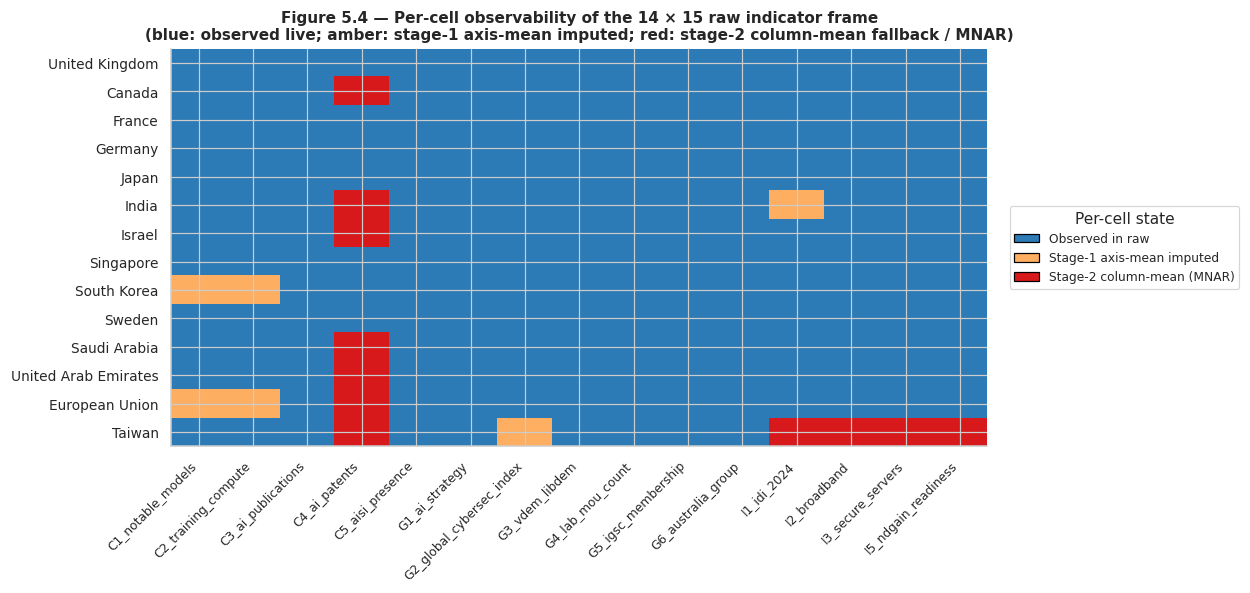

In [22]:
# Figure 5.4 — per-cell observability heatmap.
import matplotlib.colors as _mc
from matplotlib.patches import Patch as _Patch5

# Local axis lookup (cell-self-contained; ind_id_to_axis is defined later in §7).
_ind_id_to_axis_fig = dict(zip(indicators["id"], indicators["axis"], strict=True))

# State per cell, derived from the actual two-stage imputation pipeline (§7).
#   0 = observed in raw
#   1 = stage-1 axis-mean imputed (cell was NaN in raw AND the §7 imputer can
#       fill it: indicator-level missingness <= IMPUTATION_THRESHOLD AND the
#       country has at least one observed axis-mate in the same axis)
#   2 = stage-2 column-mean fallback (cell was NaN in raw AND NOT stage-1
#       imputed). These cells fall through to column-mean fill inside
#       compute_axis_score. Taiwan's four infrastructure cells fall here
#       because Taiwan has no observed I1/I2/I3/I5 axis-mates (MNAR exclusion
#       from ITU / World Bank ICT collection).
_missing_raw = raw.isna()
_indicator_miss_rate = _missing_raw.mean(axis=0)
_stage1_indicator_eligible = _indicator_miss_rate <= IMPUTATION_THRESHOLD

_state = pd.DataFrame(
    0, index=_missing_raw.index, columns=_missing_raw.columns, dtype=int
)
for _col in _missing_raw.columns:
    _axis = _ind_id_to_axis_fig[_col]
    _axis_mates = [
        c for c in raw.columns if _ind_id_to_axis_fig[c] == _axis and c != _col
    ]
    _row_has_mate = raw[_axis_mates].notna().any(axis=1)
    for _iso in _missing_raw.index:
        if not _missing_raw.at[_iso, _col]:
            continue
        if _stage1_indicator_eligible[_col] and bool(_row_has_mate.at[_iso]):
            _state.at[_iso, _col] = 1
        else:
            _state.at[_iso, _col] = 2

_state_named = _state.copy()
_state_named.index = master.reindex(_state_named.index)["name"]

fig, ax = plt.subplots(figsize=(11.5, 5.5))
_cmap = _mc.ListedColormap(["#2c7bb6", "#fdae61", "#d7191c"])
_bounds = [-0.5, 0.5, 1.5, 2.5]
_norm = _mc.BoundaryNorm(_bounds, _cmap.N)
ax.imshow(_state_named.values, cmap=_cmap, norm=_norm, aspect="auto")
ax.set_xticks(range(len(_state_named.columns)))
ax.set_xticklabels(_state_named.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(_state_named.index)))
ax.set_yticklabels(_state_named.index, fontsize=9)
_title_l1 = "Figure 5.4 — Per-cell observability of the 14 × 15 raw indicator frame"
_title_l2 = "(blue: observed live; amber: stage-1 axis-mean imputed; red: stage-2 column-mean fallback / MNAR)"
ax.set_title(_title_l1 + chr(10) + _title_l2, fontsize=10)
ax.legend(
    handles=[
        _Patch5(facecolor="#2c7bb6", edgecolor="black", label="Observed in raw"),
        _Patch5(facecolor="#fdae61", edgecolor="black", label="Stage-1 axis-mean imputed"),
        _Patch5(facecolor="#d7191c", edgecolor="black", label="Stage-2 column-mean (MNAR)"),
    ],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    frameon=True,
    title="Per-cell state",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_4_missingness_heatmap.png")
plt.show()


**Interpretation.** The missingness audit is the first analytical output the notebook produces. Where an authoritative source fails to cover a middle power (or an entire indicator family is unavailable in this run), the gap is documented rather than imputed silently. This is itself a finding relevant to the working paper, which argues that middle powers are "structurally outside the information flows" through which AI-capability assessments circulate: the per-country missingness profile in this audit quantifies relative data coverage in international AI-capability datasets across the 14 jurisdictions.

## 6. Indicator Construction

This section applies indicator-level transformations (log1p for skewed-tail counts and rates; identity for bounded ordinals and 0–1/0–100 scores) per the `transformation` field of each row in the §3.2 `INDICATORS` list. The output is a single wide frame `ind_transformed` with one column per indicator.

In [23]:
# Build a transformation lookup
transform_map = dict(zip(indicators["id"], indicators["transformation"], strict=True))
polarity_map = dict(zip(indicators["id"], indicators["polarity"], strict=True))


def apply_transform(s: pd.Series, kind: str) -> pd.Series:
    """Apply one pre-normalisation transform to an indicator series.

    Supported ``kind`` values:

    - ``"none"`` (or ``None``) — identity.
    - ``"log1p"`` — ``log(1 + max(x, 0))``; the lower-bound clip is defensive
      against floating-point negatives in count-like indicators (counts and rates
      are non-negative by construction).
    - ``"sqrt"`` — ``sqrt(max(x, 0))``; same defensive clip.
    - ``"binary"`` — ``1`` where ``x > 0`` else ``0``, cast to float.

    Raises
    ------
    ValueError
        If ``kind`` is not one of the supported values.
    """
    if kind in (None, "none"):
        return s
    if kind == "log1p":
        return np.log1p(s.clip(lower=0))
    if kind == "sqrt":
        return np.sqrt(s.clip(lower=0))
    if kind == "binary":
        return (s > 0).astype(float)
    raise ValueError(f"Unknown transformation: {kind!r}")


ind_transformed = raw.copy()
for col in ind_transformed.columns:
    if col in transform_map:
        ind_transformed[col] = apply_transform(ind_transformed[col], transform_map[col])

# Polarity: invert any 'higher_is_worse' indicators so that higher is always better post-normalization.
for col, pol in polarity_map.items():
    if col in ind_transformed.columns and pol == "higher_is_worse":
        ind_transformed[col] = -ind_transformed[col]

ind_transformed.round(2)

,C1_notable_models,C2_training_compute,C3_ai_publications,C4_ai_patents,C5_aisi_presence,G1_ai_strategy,G2_global_cybersec_index,G3_vdem_libdem,G4_lab_mou_count,G5_igsc_membership,G6_australia_group,I1_idi_2024,I2_broadband,I3_secure_servers,I5_ndgain_readiness
GBR,5.26,56.60,10.48,0.42,3.0,3.0,100.00,0.69,3.0,5.0,1.0,93.6,42.16,11.13,0.68
CAN,4.94,56.30,9.86,NaN,3.0,3.0,93.18,0.74,1.0,0.0,1.0,88.6,42.52,10.59,0.65
FRA,4.78,58.95,9.97,0.36,3.0,3.0,98.98,0.80,1.0,1.0,1.0,89.8,48.93,10.96,0.65
DEU,4.66,56.28,10.24,0.80,1.0,2.0,97.85,0.78,0.0,0.0,1.0,87.8,45.61,11.93,0.68
JPN,3.99,55.93,9.96,1.72,3.0,3.0,97.57,0.73,1.0,1.0,1.0,93.2,38.63,10.40,0.69
IND,3.09,53.89,11.24,NaN,1.0,2.0,98.49,0.26,0.0,0.0,1.0,NaN,3.15,7.10,0.39
ISR,3.61,55.38,8.05,NaN,0.0,2.0,93.76,0.59,0.0,1.0,0.0,92.5,29.18,9.42,0.52
SGP,3.93,58.06,8.85,0.68,3.0,3.0,99.86,0.36,1.0,0.0,0.0,97.8,27.81,12.25,0.80
KOR,NaN,NaN,9.81,2.91,3.0,3.0,100.00,0.74,0.0,1.0,1.0,94.4,47.80,9.38,0.73
SWE,3.04,54.14,8.68,0.55,0.0,2.0,99.31,0.85,0.0,0.0,1.0,95.3,40.62,10.92,0.71


**Indicator-by-indicator notes:**
- `C1`, `C2` use `log1p` because the long tail of model counts and training compute is dominated by a handful of jurisdictions; on raw scale, the rest would z-score near a single value and the head-to-tail variation would dominate the axis.
- `C3` (publications) uses `log1p` for the same reason — India's count is ~24× Israel's (the lowest of the 14) and ~17× UAE's.
- `C4` (patents per 100k inhabitants) uses `log1p` because Korea's rate (17.27) is ~3.8× Japan's (4.58) and ~40× France's (0.43); per-capita rates are skewed even after population-normalisation.
- `I3` (secure servers per million) uses `log1p` for the same reason.
- Ordinal scores (`C5`, `G1`) are kept on their original 0–3 scale.
- Binary indicators (`G6` Australia Group membership) are kept as 0/1 — z-scoring then converts to ±SD.
- ITU GCI (`G2`) and ITU IDI (`I1`) are already on a 0–100 scale; ND-GAIN Readiness (`I5`) and V-Dem (`G3`) on 0–1 — no transformation needed.
- All indicators in this configuration are oriented `higher_is_better`; no polarity inversion is currently applied.

## 7. Imputation Strategy

The OECD/JRC handbook step 3. Two-stage approach in this notebook:

1. **Indicators with ≤ 30% missingness** (controlled by `IMPUTATION_THRESHOLD = 0.30` in §3.1): explicit axis-mean imputation in z-score space. For each missing cell, the country's other indicators in the same axis are first z-scored across the 14-jurisdiction sample (skipping missing values); the missing cell receives the country's average z-position across those axis-mates, converted back to the indicator's own raw scale via `mean + z · SD`. This pulls the missing value toward the country's local axis position rather than toward the global mean, while ensuring axis-mates on different raw scales (e.g. log1p training compute ≈ 50 vs ordinal AISI presence ∈ {0..3}) contribute equivalently to the imputed z-position. The `ind_imp_flag` boolean frame records exactly which cells were filled this way.

2. **Indicators with > 30% missingness**: not imputed at this stage. They retain NaN here and the output line `Indicators excluded (>30% missing)` lists them. **The word `excluded` is misleading**: those NaN cells are subsequently filled with 0 (= z-score mean) inside `compute_axis_score` in §11 — see §11.1. The cells still enter axis aggregation at the column mean rather than at a row-specific imputed value. A more accurate name for the printed line would be `Indicators not row-imputed (column-mean-filled at aggregation)`; the term `excluded` is retained for backward compatibility with prior runs.

3. **Indicators with one country fully unobserved across an entire axis.** Stage 1 needs at least one observed axis-mate to compute the row's average z-position. Taiwan is missing I1, I2, I3, and I5 simultaneously — all four infrastructure indicators — so stage 1 cannot fill any of its infrastructure cells, and stage 2 (column-mean fill) produces an infrastructure_posture axis score of exactly 0.000 from no observed data. The §14 typology label for Taiwan ("Tier-3 vulnerability, worst on Capacity Depth") is therefore based on a fabricated infrastructure value; see the caveat in §14.

The `ind_imp_flag` frame is consumed by §12.3 (alternative-normalization sensitivity check) to re-apply the same imputation cells to the min-max-normalized indicators. Other downstream consumers (Monte Carlo, LOO) treat all cells uniformly.

In [24]:
# IMPUTATION_THRESHOLD imported from §3.1 setup cell.
ind_id_to_axis = dict(zip(indicators["id"], indicators["axis"], strict=True))


def impute_axis_mean(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Z-score-axis-mean imputation for missing indicator cells.

    For each missing cell whose indicator has at most ``IMPUTATION_THRESHOLD`` missingness
    globally, imputes the country's average z-position across its other indicators in the
    same axis, then converts back to the indicator's own raw scale via ``mean + z · SD``.
    Operating in z-score space ensures indicators on different raw scales (e.g. log1p
    training-compute ≈ 50; ordinal AISI presence ∈ {0..3}) contribute equivalently to the
    imputed z-position. Indicators with > IMPUTATION_THRESHOLD missingness are left as
    NaN here and filled with the column mean inside :func:`compute_axis_score`.

    Returns
    -------
    out
        Imputed indicator matrix on the same scale as the input.
    flag
        Boolean matrix recording exactly which cells were filled.
    """
    out = df.copy()
    flag = pd.DataFrame(False, index=df.index, columns=df.columns)
    miss_rates = df.isna().mean()
    # Per-indicator z-scores across non-missing countries (pandas skips NaN in mean/std).
    df_z = (df - df.mean()) / df.std(ddof=0)
    for col in df.columns:
        if miss_rates[col] > IMPUTATION_THRESHOLD:
            continue
        if df[col].isna().any():
            axis = ind_id_to_axis.get(col)
            axis_cols = [
                c for c in df.columns if ind_id_to_axis.get(c) == axis and c != col
            ]
            # Average the country's z-scores across the OTHER indicators in the same axis.
            row_axis_z_mean = df_z[axis_cols].mean(axis=1)
            mask = df[col].isna() & row_axis_z_mean.notna()
            col_mean = df[col].mean()
            col_sd = df[col].std(ddof=0)
            out.loc[mask, col] = col_mean + row_axis_z_mean[mask] * col_sd
            flag.loc[mask, col] = True
    return out, flag


ind_imputed, ind_imp_flag = impute_axis_mean(ind_transformed)
print(f"Cells imputed: {int(ind_imp_flag.sum().sum())}")
print(
    f"Indicators excluded (>{int(IMPUTATION_THRESHOLD * 100)}% missing): "
    f"{[c for c in ind_imputed.columns if ind_imputed[c].isna().mean() > IMPUTATION_THRESHOLD]}"
)

Cells imputed: 6
Indicators excluded (>30% missing): ['C4_ai_patents']


## 8. Multivariate Diagnostics — does each axis cohere?

The OECD/JRC handbook step 4. Before indicators are aggregated within an axis, the notebook checks whether they actually co-vary. Where they do not, the axis is multidimensional rather than reducible to a single weighted sum — the result warrants explicit discussion rather than silent aggregation.

Two checks:
1. **Correlation matrix within axis**: pairwise Pearson correlations among indicators in the same axis; positive correlations are expected within an axis.
2. **PCA within axis**: the first principal component should explain ≥ 50% of variance. Lower means the axis is multidimensional and a single composite score loses information.

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def axis_diagnostics(df: pd.DataFrame, axis: str) -> dict:
    """Within-axis multivariate diagnostics: correlation summary and PCA explained variance.

    Computes pairwise Pearson correlations among indicators belonging to the given axis,
    plus a PCA on the standardised complete cases. Returns the mean off-diagonal
    correlation, the PC1 explained-variance ratio, and the PC1 loadings — used by §16.1
    to assess whether the axis is reasonably one-dimensional (PC1 ≥ 50%) or multidimensional.
    """
    cols = [
        c for c in df.columns if ind_id_to_axis.get(c) == axis and df[c].notna().any()
    ]
    sub = df[cols].dropna(how="any")
    if len(sub) < 3 or len(cols) < 2:
        return {"axis": axis, "n_indicators": len(cols), "note": "insufficient data"}
    corr = sub.corr(method="pearson")
    x_scaled = StandardScaler().fit_transform(sub.values)
    pca = PCA().fit(x_scaled)
    return {
        "axis": axis,
        "n_indicators": len(cols),
        "n_countries_complete": len(sub),
        "mean_offdiag_corr": (corr.values.sum() - np.trace(corr.values))
        / (len(cols) * (len(cols) - 1)),
        "pc1_explained_var": float(pca.explained_variance_ratio_[0]),
        "pc1_loadings": dict(zip(cols, pca.components_[0], strict=True)),
    }


diag = [
    axis_diagnostics(ind_imputed, ax)
    for ax in ["capacity_depth", "governance_orientation", "infrastructure_posture"]
]
diag_df = pd.DataFrame(diag)
diag_df

,axis,n_indicators,n_countries_complete,mean_offdiag_corr,pc1_explained_var,pc1_loadings
0,capacity_depth,5,7,0.423763,0.563983,"{'C1_notable_models': 0.5364232508611487, 'C2_..."
1,governance_orientation,6,14,0.247018,0.425044,"{'G1_ai_strategy': 0.5069675744535521, 'G2_glo..."
2,infrastructure_posture,4,13,0.394114,0.563788,"{'I1_idi_2024': 0.35178357958018364, 'I2_broad..."


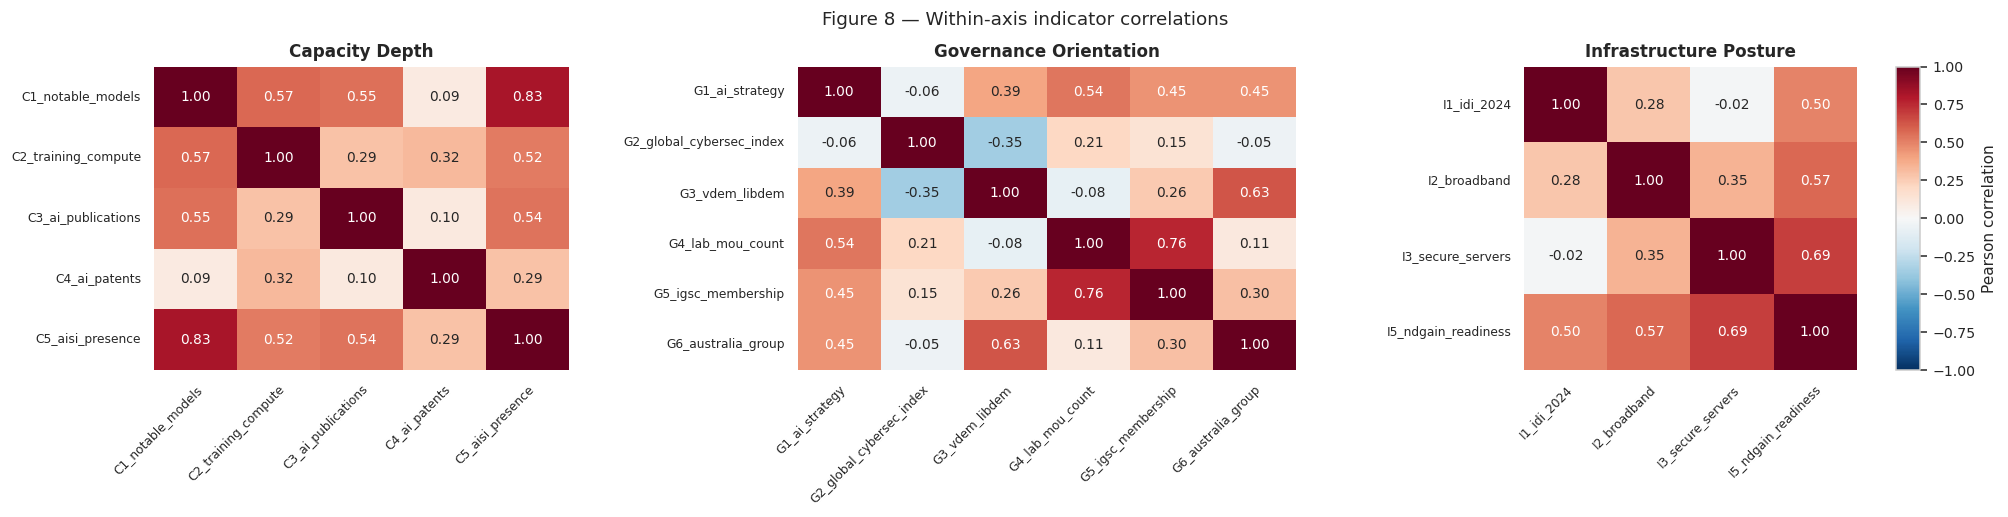

In [26]:
# Visualize axis-level correlation matrices with a shared colorbar so a reader who
# does not match the annotated numbers can still place each cell on the [-1, +1] scale.
fig, axes = plt.subplots(
    1, 3, figsize=(18, 4.6), gridspec_kw={"width_ratios": [5, 6, 4], "wspace": 0.55}
)
last_hm = None
for ax_obj, axis in zip(
    axes,
    ["capacity_depth", "governance_orientation", "infrastructure_posture"],
    strict=True,
):
    cols = [
        c
        for c in ind_imputed.columns
        if ind_id_to_axis.get(c) == axis and ind_imputed[c].notna().any()
    ]
    if len(cols) < 2:
        ax_obj.set_title(f"{axis}\n(insufficient data)")
        ax_obj.axis("off")
        continue
    corr = ind_imputed[cols].corr()
    last_hm = sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax_obj,
        cbar=False,
        annot_kws={"fontsize": 9},
    )
    ax_obj.set_title(axis.replace("_", " ").title(), fontsize=11)
    ax_obj.tick_params(axis="both", labelsize=8)
    # 45° x-tick rotation: long indicator IDs (C2_training_compute) crowd at 90°.
    plt.setp(ax_obj.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Single shared colorbar to the right of all three panels.
if last_hm is not None:
    # `top=0.85` (was 0.88) gives the suptitle clearance from the panel titles.
    fig.subplots_adjust(left=0.06, right=0.92, top=0.85, bottom=0.25)
    cbar_ax = fig.add_axes([0.94, 0.25, 0.012, 0.60])
    fig.colorbar(last_hm.collections[0], cax=cbar_ax, label="Pearson correlation")
fig.suptitle("Figure 8 — Within-axis indicator correlations", y=0.96, fontsize=12)
plt.savefig(FIG_DIR / "fig8_within_axis_correlations.png")
plt.show()

In [27]:
# Print PC1 explained variance per axis so the §8 interpretation cell can cite the
# numerical result directly rather than only the pass/fail verdict.
for d in diag:
    if "pc1_explained_var" in d:
        verdict = (
            "axis is reasonably one-dimensional"
            if d["pc1_explained_var"] >= PCA_ONE_DIM_THRESHOLD
            else "axis is multidimensional — composite caveat applies"
        )
        print(
            f"  {d['axis']:25s}  PC1 explains {d['pc1_explained_var'] * 100:>5.1f}% of variance  ({verdict})"
        )

  capacity_depth             PC1 explains  56.4% of variance  (axis is reasonably one-dimensional)
  governance_orientation     PC1 explains  42.5% of variance  (axis is multidimensional — composite caveat applies)
  infrastructure_posture     PC1 explains  56.4% of variance  (axis is reasonably one-dimensional)


### 8.1 Horn's parallel analysis — significance test for PC1 dimensionality

The 50% one-dimensionality threshold used in §8 (controlled by `PCA_ONE_DIM_THRESHOLD = 0.50`) is a rule of thumb. Horn's parallel analysis (Horn 1965) replaces it with a principled null-distribution test: simulate datasets with the same shape under a "no structure" null, compute PC1 explained variance for each, and take the 95th percentile of the resulting null distribution as the significance threshold. An axis is **significantly one-dimensional** iff its observed PC1 explained variance exceeds the 95th-percentile null.

Implementation: **permutation-based parallel analysis**. For each axis, the values of each indicator column are independently shuffled across the rows of that axis's complete-case matrix (n = 7 for capacity_depth after `dropna(how="any")`, n = 14 for governance, n = 13 for infrastructure; the same row-subset that `axis_diagnostics` fits in §8) and the shuffle is repeated N = 10,000 times. This preserves each indicator's marginal distribution but destroys cross-indicator correlation, yielding the null distribution of PCA explained-variance ratios under "no axis-level correlation beyond indicator-by-indicator variance." Permutation PA is preferred over the parametric Gaussian variant because the indicator distributions are heterogeneous (log-counts, ordinals, bounded 0–1 and 0–100 scores) and a normal-data null would mis-specify the marginals.

Output saved to `outputs/parallel_analysis.csv`. §16.1 references these results when discussing whether the paper's three-axes scaffold is statistically defensible.


In [28]:
# §8.1 — Horn's parallel analysis for PC1 dimensionality
N_PERMUTATIONS_PA = 10_000


def parallel_analysis_pca(
    x: np.ndarray,
    n_permutations: int = N_PERMUTATIONS_PA,
    seed: int = SEED,
) -> dict[str, np.ndarray]:
    """Permutation-based Horn's parallel analysis on a standardised matrix.

    For each indicator column independently, values are shuffled across rows
    (preserves marginal distribution, destroys cross-column correlation). PCA
    is then fit on the standardised permuted matrix; the null distribution of
    explained-variance ratios is built across `n_permutations` draws.

    Parameters
    ----------
    x
        Indicator matrix (n_countries x n_indicators), pre- or post-imputation.
        Rows with NaN are dropped before fitting.
    n_permutations
        Number of permutation draws under the null (default 10,000).
    seed
        RNG seed for reproducibility.

    Returns
    -------
    dict
        observed_evr, null_median, null_p95, p_value — each a length-n_components array.
    """
    rng = np.random.default_rng(seed)
    _n_rows, n_cols = x.shape
    scaler = StandardScaler()
    x_std = scaler.fit_transform(x)
    observed_evr = PCA().fit(x_std).explained_variance_ratio_
    null_dist = np.zeros((n_permutations, n_cols))
    for i in range(n_permutations):
        x_perm = np.column_stack([rng.permutation(x_std[:, j]) for j in range(n_cols)])
        null_dist[i] = PCA().fit(x_perm).explained_variance_ratio_
    return {
        "observed_evr": observed_evr,
        "null_median": np.percentile(null_dist, 50, axis=0),
        "null_p95": np.percentile(null_dist, 95, axis=0),
        "p_value": (null_dist >= observed_evr).mean(axis=0),
    }


pa_rows = []
for axis in ["capacity_depth", "governance_orientation", "infrastructure_posture"]:
    cols = [
        c
        for c in ind_imputed.columns
        if ind_id_to_axis.get(c) == axis and ind_imputed[c].notna().any()
    ]
    x_axis = ind_imputed[cols].dropna(how="any").values
    if x_axis.shape[0] < 3 or x_axis.shape[1] < 2:
        continue
    pa = parallel_analysis_pca(x_axis)
    pc1_obs = pa["observed_evr"][0]
    pc1_null_p95 = pa["null_p95"][0]
    pc1_p = pa["p_value"][0]
    pc1_significant = pc1_obs > pc1_null_p95
    # Also test PC2 to detect whether a second meaningful dimension exists
    pc2_obs = pa["observed_evr"][1] if len(pa["observed_evr"]) >= 2 else np.nan
    pc2_null_p95 = pa["null_p95"][1] if len(pa["null_p95"]) >= 2 else np.nan
    pc2_p = pa["p_value"][1] if len(pa["p_value"]) >= 2 else np.nan
    pc2_significant = (not np.isnan(pc2_obs)) and pc2_obs > pc2_null_p95
    pa_rows.append(
        {
            "axis": axis,
            "n_countries": x_axis.shape[0],
            "n_indicators": x_axis.shape[1],
            "pc1_observed_evr": round(pc1_obs, 4),
            "pc1_null_p95": round(pc1_null_p95, 4),
            "pc1_p_value": round(pc1_p, 4),
            "pc1_significant": pc1_significant,
            "pc2_observed_evr": round(pc2_obs, 4) if not np.isnan(pc2_obs) else None,
            "pc2_null_p95": round(pc2_null_p95, 4)
            if not np.isnan(pc2_null_p95)
            else None,
            "pc2_p_value": round(pc2_p, 4) if not np.isnan(pc2_p) else None,
            "pc2_significant": pc2_significant,
        }
    )

pa_df = pd.DataFrame(pa_rows)
pa_df.to_csv(OUT_DIR / "parallel_analysis.csv", index=False)
print(
    f"Horn's parallel analysis (permutation-based, N = {N_PERMUTATIONS_PA:,} permutations):"
)
print()
for row in pa_rows:
    pc1_verdict = (
        "PC1 significantly above null"
        if row["pc1_significant"]
        else "PC1 not significantly above null"
    )
    pc2_verdict = (
        "PC2 also significant" if row["pc2_significant"] else "PC2 not significant"
    )
    print(
        f"  {row['axis']:25s}  "
        f"PC1 observed = {row['pc1_observed_evr']:.3f}, null p95 = {row['pc1_null_p95']:.3f}, "
        f"p = {row['pc1_p_value']:.4f}  ({pc1_verdict})"
    )
    print(
        f"  {' ':25s}  "
        f"PC2 observed = {row['pc2_observed_evr']:.3f}, null p95 = {row['pc2_null_p95']:.3f}, "
        f"p = {row['pc2_p_value']:.4f}  ({pc2_verdict})"
    )

Horn's parallel analysis (permutation-based, N = 10,000 permutations):

  capacity_depth             PC1 observed = 0.564, null p95 = 0.583, p = 0.0755  (PC1 not significantly above null)
                             PC2 observed = 0.228, null p95 = 0.359, p = 0.8898  (PC2 not significant)
  governance_orientation     PC1 observed = 0.425, null p95 = 0.408, p = 0.0249  (PC1 significantly above null)
                             PC2 observed = 0.279, null p95 = 0.288, p = 0.0883  (PC2 not significant)
  infrastructure_posture     PC1 observed = 0.564, null p95 = 0.523, p = 0.0140  (PC1 significantly above null)
                             PC2 observed = 0.256, null p95 = 0.343, p = 0.8255  (PC2 not significant)


### 8.1.1 Parallel-analysis scree plots (figure)

Per-axis bar chart of the observed PC1…PCk explained-variance ratios overlaid with Horn's permutation-null 95th-percentile band. An axis's observed PC1 clears the null band iff the parallel-analysis test rejects the null at $\alpha = 0.05$ for PC1 — making the borderline capacity case (current-run $p ≈ 0.07$) and the comfortably-significant infrastructure case ($p ≈ 0.01$) immediately legible.


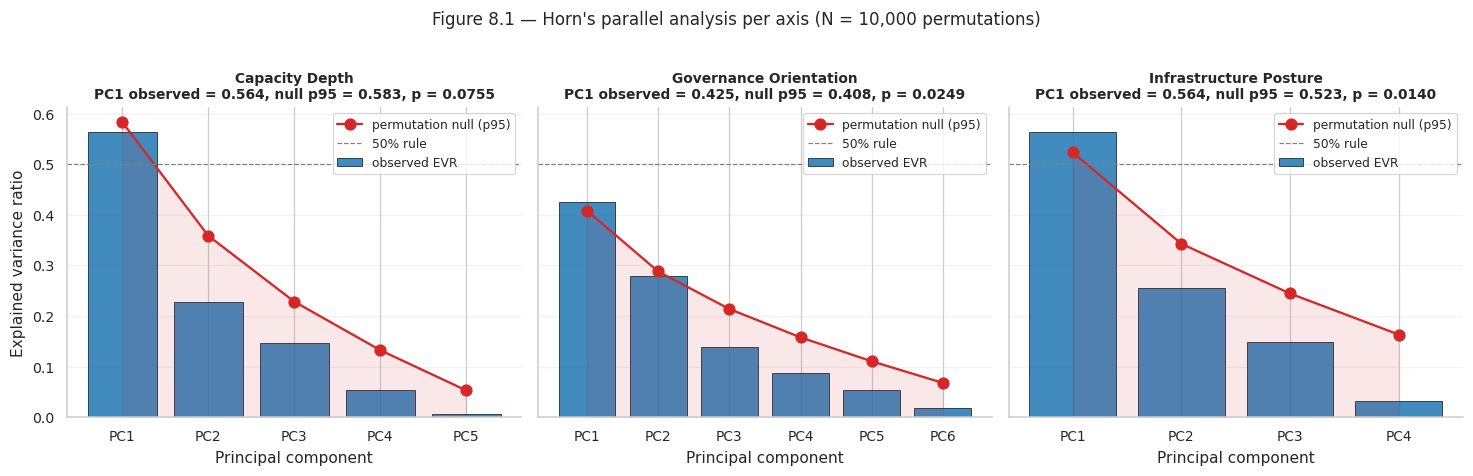

In [29]:
# Figure 8.1 — per-axis parallel-analysis scree plot.
fig, axes_pa = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax_pa, _axis_name in zip(
    axes_pa,
    ["capacity_depth", "governance_orientation", "infrastructure_posture"],
    strict=True,
):
    _axis_cols = [
        c
        for c in ind_imputed.columns
        if ind_id_to_axis.get(c) == _axis_name and ind_imputed[c].notna().any()
    ]
    _x_axis_mat = ind_imputed[_axis_cols].dropna(how="any").values
    if _x_axis_mat.shape[0] < 3 or _x_axis_mat.shape[1] < 2:
        ax_pa.text(
            0.5,
            0.5,
            "insufficient data",
            transform=ax_pa.transAxes,
            ha="center",
            va="center",
        )
        continue
    _pa = parallel_analysis_pca(_x_axis_mat)
    _n_comp = len(_pa["observed_evr"])
    _x_pos = np.arange(_n_comp)
    ax_pa.bar(
        _x_pos,
        _pa["observed_evr"],
        color="#1f77b4",
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        label="observed EVR",
    )
    ax_pa.plot(
        _x_pos,
        _pa["null_p95"],
        color="#d62728",
        marker="o",
        markersize=7,
        linewidth=1.5,
        label="permutation null (p95)",
    )
    ax_pa.fill_between(_x_pos, 0, _pa["null_p95"], color="#d62728", alpha=0.10)
    ax_pa.axhline(
        PCA_ONE_DIM_THRESHOLD,
        color="grey",
        linestyle="--",
        linewidth=0.8,
        label="50% rule",
    )
    ax_pa.set_xticks(_x_pos)
    ax_pa.set_xticklabels([f"PC{i + 1}" for i in range(_n_comp)], fontsize=9)
    ax_pa.set_xlabel("Principal component")
    ax_pa.set_title(
        f"{_axis_name.replace('_', ' ').title()}\n"
        f"PC1 observed = {_pa['observed_evr'][0]:.3f}, "
        f"null p95 = {_pa['null_p95'][0]:.3f}, "
        f"p = {_pa['p_value'][0]:.4f}",
        fontsize=9,
    )
    ax_pa.legend(loc="upper right", fontsize=8, frameon=True)
    ax_pa.grid(True, axis="y", alpha=0.25)
axes_pa[0].set_ylabel("Explained variance ratio")
fig.suptitle(
    f"Figure 8.1 — Horn's parallel analysis per axis "
    f"(N = {N_PERMUTATIONS_PA:,} permutations)",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_1_parallel_analysis.png")
plt.show()

**Interpretation.** PC1 explained variance per axis is printed above. Two complementary criteria assess whether each axis is one-dimensional: the **50% rule** (a heuristic threshold reported here) and **Horn's parallel analysis** (§8.1, a principled permutation-based test). An axis is statistically one-dimensional iff its observed PC1 explained variance exceeds the 95th-percentile null derived from independently-shuffled indicator columns. §16.1 cross-references both criteria when assessing the empirical defensibility of the paper's three-axes scaffold; where the two diagnostics disagree (an axis above 50% but not above the permutation null, or vice versa), the parallel-analysis test is the more rigorous standard.

## 9. Normalization

The OECD/JRC handbook step 5. Two schemes:

- **Z-score** (primary): mean 0, SD 1 across the 14 jurisdictions. Preserves relative spacing.
- **Min-max** (alternative): scaled to [0, 1] across the 14. Used for sensitivity in §12.

In [30]:
def normalize_zscore(df: pd.DataFrame) -> pd.DataFrame:
    """Per-column z-score normalisation (population SD, ddof=0).

    For each column, subtracts the column mean and divides by the population
    standard deviation. NaN cells in the input are preserved (pandas skips NaN
    in mean and std), so this is safe to apply before imputation.
    """
    return (df - df.mean(axis=0)) / df.std(axis=0, ddof=0)


def normalize_minmax(df: pd.DataFrame) -> pd.DataFrame:
    """Per-column min-max normalisation onto [0, 1].

    Constant columns (max == min) are mapped to NaN to avoid divide-by-zero
    and to flag them as carrying no across-country information for downstream
    aggregation.
    """
    rng = df.max(axis=0) - df.min(axis=0)
    rng = rng.replace(0, np.nan)
    return (df - df.min(axis=0)) / rng


ind_z = normalize_zscore(ind_imputed)
ind_mm = normalize_minmax(ind_imputed)
ind_z.round(2)

,C1_notable_models,C2_training_compute,C3_ai_publications,C4_ai_patents,C5_aisi_presence,G1_ai_strategy,G2_global_cybersec_index,G3_vdem_libdem,G4_lab_mou_count,G5_igsc_membership,G6_australia_group,I1_idi_2024,I2_broadband,I3_secure_servers,I5_ndgain_readiness
GBR,1.39,0.12,0.76,-0.75,0.97,1.0,0.91,0.43,2.87,3.35,0.75,0.29,0.34,0.64,0.47
CAN,1.05,0.03,0.16,NaN,0.97,1.0,-1.94,0.61,0.36,-0.56,0.75,-1.10,0.37,0.33,0.11
FRA,0.87,0.82,0.26,-0.82,0.97,1.0,0.48,0.85,0.36,0.22,0.75,-0.77,0.91,0.54,0.15
DEU,0.75,0.02,0.53,-0.31,-0.46,-1.0,0.01,0.78,-0.90,-0.56,0.75,-1.33,0.63,1.09,0.48
JPN,0.01,-0.08,0.26,0.76,0.97,1.0,-0.11,0.60,0.36,0.22,0.75,0.18,0.04,0.23,0.51
IND,-0.96,-0.68,1.48,NaN,-0.46,-1.0,0.28,-1.20,-0.90,-0.56,0.75,-1.89,-2.97,-1.64,-2.42
ISR,-0.40,-0.24,-1.58,NaN,-1.18,-1.0,-1.70,0.05,-0.90,0.22,-1.34,-0.02,-0.76,-0.33,-1.11
SGP,-0.05,0.55,-0.81,-0.44,0.97,1.0,0.85,-0.82,0.36,-0.56,-1.34,1.46,-0.88,1.27,1.67
KOR,0.85,0.85,0.11,2.14,0.97,1.0,0.91,0.62,-0.90,0.22,0.75,0.51,0.82,-0.35,0.93
SWE,-1.01,-0.61,-0.97,-0.59,-1.18,-1.0,0.62,1.05,-0.90,-0.56,0.75,0.76,0.21,0.52,0.80


## 10. Weighting Schemes

Three weighting schemes are reported side-by-side:

### 10.1 Equal weights (baseline)

The default OECD/JRC recommendation when no theory privileges one indicator. Maximally transparent.

### 10.2 PCA-derived weights

Weights = squared loadings on the first principal component within each axis, then renormalised. This is the OECD/JRC handbook's factor-analysis-based weighting approach: it lets the data identify which indicators carry the most structural variance within each axis rather than imposing prior weights.

> **Caveat.** PCA is computed on the post-§7-imputation matrix and uses `dropna(how="any")` to fit, so single-country leverage on the resulting loadings is high. For the capacity_depth axis specifically, the dropna step removes every country with C4 unobserved (50% missingness, never imputed), leaving the fit on **n = 7 countries × 5 indicators** — a very small sample. Two known consequences in the current run:
>
> 1. **PCA effectively drops G2 (ITU GCI).** The current-run PCA assigns G2 a weight of ≈ 5.7×10⁻⁵ within governance (see `outputs/weights_pca_runtime.json`), reallocating its mass to G1 (≈ 0.257, the heaviest loading). Since G1 is analyst-coded (§17.5), the PCA scheme is **more** analyst-judgment-dependent than the literature scheme, not less — the opposite of what an unwary reader might infer from "PCA-derived". This is the main reason EU jumps to rank 2 under PCA (it underperforms on G2 relative to its capacity strengths; removing G2 lifts its governance score).
> 2. **n = 7 capacity-axis PCA is borderline non-identifiable.** A 5-indicator PCA on 7 observations has very limited degrees of freedom. The PC1 explained variance reported for capacity_depth carries a much wider implicit confidence interval than the governance (n=14) or infrastructure (n=13) axes.
>
> **Treat PCA as a sensitivity benchmark, not a primary weighting** — the headline and the paper-cited rankings should use the literature scheme.

### 10.3 Literature-elicited weights

Weights derived from the GMF Pivotal Powers, Chatham House Sovereign AI, and Tortoise Global AI Index frameworks. Capacity Depth weighted highest, reflecting the paper §4 argument that *capacity depth most directly constrains verification*.

In [31]:
def axis_weights_equal(axis_indicators: list[str]) -> dict:
    """Equal weights within an axis: ``1 / n`` for each of ``n`` indicators."""
    return dict.fromkeys(axis_indicators, 1.0 / len(axis_indicators))


def axis_weights_pca(df: pd.DataFrame, axis_indicators: list[str]) -> dict:
    """PCA-derived weights = squared PC1 loadings, renormalised to sum to 1.

    Fits a single-component PCA on the complete-case subset of ``df[axis_indicators]``
    after z-score standardisation. The squared loadings are renormalised across
    the axis's indicators. Falls back to equal weights when fewer than 3 complete
    rows or fewer than 2 indicators are available (the PCA would be unidentified).
    See §10.2 for the small-sample-stability caveats.
    """
    sub = df[axis_indicators].dropna(how="any")
    if len(sub) < 3 or len(axis_indicators) < 2:
        return axis_weights_equal(axis_indicators)
    x_scaled = StandardScaler().fit_transform(sub.values)
    pca = PCA(n_components=1).fit(x_scaled)
    loadings_sq = pca.components_[0] ** 2
    weights = loadings_sq / loadings_sq.sum()
    return dict(zip(axis_indicators, weights, strict=True))


def axis_weights_literature(axis: str) -> dict:
    """Return the literature-elicited within-axis weights from the §3.2 config."""
    return weights_cfg["schemes"]["literature"]["indicator_weights"][axis]


axes_list = ["capacity_depth", "governance_orientation", "infrastructure_posture"]
schemes: dict[str, dict[str, dict[str, float]]] = {
    "equal": {},
    "pca": {},
    "literature": {},
}
for ax in axes_list:
    cols = [
        c
        for c in ind_imputed.columns
        if ind_id_to_axis.get(c) == ax and ind_imputed[c].notna().any()
    ]
    schemes["equal"][ax] = axis_weights_equal(cols)
    schemes["pca"][ax] = axis_weights_pca(ind_imputed, cols)
    schemes["literature"][ax] = {c: axis_weights_literature(ax).get(c, 0) for c in cols}

# Print compact summary
for sname, sdict in schemes.items():
    print(f"Scheme: {sname}")
    for ax, w in sdict.items():
        print(f"  {ax}:  " + ", ".join(f"{k}={v:.2f}" for k, v in w.items()))

Scheme: equal
  capacity_depth:  C1_notable_models=0.20, C2_training_compute=0.20, C3_ai_publications=0.20, C4_ai_patents=0.20, C5_aisi_presence=0.20
  governance_orientation:  G1_ai_strategy=0.17, G2_global_cybersec_index=0.17, G3_vdem_libdem=0.17, G4_lab_mou_count=0.17, G5_igsc_membership=0.17, G6_australia_group=0.17
  infrastructure_posture:  I1_idi_2024=0.25, I2_broadband=0.25, I3_secure_servers=0.25, I5_ndgain_readiness=0.25
Scheme: pca
  capacity_depth:  C1_notable_models=0.29, C2_training_compute=0.23, C3_ai_publications=0.19, C4_ai_patents=0.05, C5_aisi_presence=0.25
  governance_orientation:  G1_ai_strategy=0.26, G2_global_cybersec_index=0.00, G3_vdem_libdem=0.13, G4_lab_mou_count=0.19, G5_igsc_membership=0.25, G6_australia_group=0.18
  infrastructure_posture:  I1_idi_2024=0.12, I2_broadband=0.25, I3_secure_servers=0.23, I5_ndgain_readiness=0.40
Scheme: literature
  capacity_depth:  C1_notable_models=0.30, C2_training_compute=0.25, C3_ai_publications=0.10, C4_ai_patents=0.10,

In [32]:
# Persist runtime PCA weights to outputs (referenced by §19 bibliography).
out_path = OUT_DIR / "weights_pca_runtime.json"
out_path.write_text(json.dumps(schemes["pca"], indent=2, default=float))
print(f"Saved PCA runtime weights to {out_path.relative_to(NB_ROOT).as_posix()}")

Saved PCA runtime weights to outputs/weights_pca_runtime.json


## 11. Composite Index Computation

The OECD/JRC handbook step 6.

- **Within-axis aggregation**: linear (weighted sum of normalized indicators).
- **Across-axis aggregation**: geometric mean of axis scores. Geometric aggregation **penalises imbalance** — a country that scores very high on infrastructure but very low on governance does not get full credit. This is consistent with the working paper's argument that **all three axes matter for preparedness** (a country missing one axis cannot substitute with the other two).

> **Portability caveat.** Because z-scored axis values can be negative, the geometric step shifts each axis by `−min(axis) + 1e-3` before taking logs. The shift constant depends on the country set: if the country list changes (e.g., Taiwan is dropped, the Netherlands is added), the bottom-country score changes and every other country's composite shifts in absolute terms. Composites are therefore comparable **within the 14-country reference frame only**; per-country composite values cannot be cited as portable absolute scores outside this frame. The relative ranking is portable; the absolute composite number is not.

### 11.1 Treatment of missing cells in aggregation

A note on how missingness propagates through aggregation. The §7 imputation step fills only those cells where the indicator's overall missingness is ≤ 30%; indicators with higher missingness are not imputed and retain NaN. Inside `compute_axis_score`, NaN cells are filled with the corresponding indicator's column mean before the weighted sum — equivalent to mean-imputation regardless of which normalisation scheme produced the input matrix (z-score column mean = 0; min-max column mean ≠ 0). This keeps the §12.3 z-score-vs-min-max sensitivity check methodologically symmetric.

This is a deliberate design choice (rather than dropping countries entirely from indicators they're missing), but it is *imputation*, not exclusion. The `Indicators excluded (>30% missing)` line printed by §7 is therefore a name-of-art: those indicators are excluded from the explicit axis-mean imputation step, but their missing cells still contribute (at the indicator mean) to the weighted axis score. §17 flags this; §12.2 leave-one-indicator-out quantifies the rank effect.

In [33]:
def compute_axis_score(
    norm_df: pd.DataFrame, axis_weights: dict[str, dict]
) -> pd.DataFrame:
    """Aggregate normalised indicators into per-country axis scores.

    For each axis, computes a linear weighted sum of the country's normalised indicator
    values using the supplied per-axis indicator weights. NaN cells in the input are
    filled with each indicator's column mean before the weighted sum, which is equivalent
    to mean-imputation under both z-score (column mean = 0) and min-max (column mean ≠ 0)
    normalisation; this keeps the §12.3 z-score-vs-min-max sensitivity check
    methodologically symmetric.

    Parameters
    ----------
    norm_df
        Wide DataFrame indexed by ISO3 with one column per indicator, after normalisation.
    axis_weights
        Mapping ``axis_id -> {indicator_id: weight}`` where each axis's weights sum to 1.
        Indicators absent from norm_df are dropped and the remaining weights renormalised.

    Returns
    -------
    pd.DataFrame
        ISO3-indexed frame with one column per axis containing the axis score.
    """
    out = pd.DataFrame(index=norm_df.index)
    col_means = norm_df.mean()
    for ax, w in axis_weights.items():
        cols = [c for c in w if c in norm_df.columns]
        if not cols:
            out[ax] = np.nan
            continue
        weights_arr = np.array([w[c] for c in cols])
        weights_arr = (
            weights_arr / weights_arr.sum() if weights_arr.sum() > 0 else weights_arr
        )
        filled = norm_df[cols].fillna(col_means[cols])
        out[ax] = (filled.values * weights_arr).sum(axis=1)
    return out


def compute_composite(
    axis_scores: pd.DataFrame, axis_weights_top: dict, mode: str = "geometric"
) -> pd.Series:
    """Aggregate per-axis scores into a single composite per country.

    Geometric aggregation (the default) penalises imbalance across axes — a country that
    scores very high on one axis but low on another receives less than the weighted
    arithmetic mean. This matches the working paper's argument that all three axes matter
    for preparedness. Because z-scored axis values can be negative, axes are first shifted
    to non-negative via ``axis - min(axis) + 1e-3`` before taking logs; the shift constant
    depends on the country set, so per-country composite values are not portable outside
    the 14-country reference frame (see §11 portability caveat).

    Parameters
    ----------
    axis_scores
        ISO3-indexed frame with one column per axis (output of :func:`compute_axis_score`).
    axis_weights_top
        Mapping ``axis_id -> weight``. Renormalised internally to sum to 1.
    mode
        Either ``"geometric"`` (default) or ``"linear"``.

    Returns
    -------
    pd.Series
        ISO3-indexed composite score.
    """
    cols = list(axis_scores.columns)
    weights = np.array([axis_weights_top.get(c, 1.0 / len(cols)) for c in cols])
    weights = weights / weights.sum()
    shifted = axis_scores - axis_scores.min(axis=0) + GEOMETRIC_SHIFT_EPS
    if mode == "geometric":
        log = np.log(shifted) * weights
        return np.exp(log.sum(axis=1))
    return (shifted * weights).sum(axis=1)


# Top-level axis weights for the composite
top_weights = {
    "equal": dict.fromkeys(axes_list, 1 / 3),
    "pca": dict.fromkeys(axes_list, 1 / 3),  # equal across axes; within-axis varies
    "literature": weights_cfg["schemes"]["literature"]["axis_weights"],
}

# Compute axis scores and composites under all three schemes
axis_scores_by_scheme = {}
composite_by_scheme = {}
for scheme in ["equal", "pca", "literature"]:
    axis_scores = compute_axis_score(ind_z, schemes[scheme])
    composite = compute_composite(axis_scores, top_weights[scheme], mode="geometric")
    axis_scores_by_scheme[scheme] = axis_scores
    composite_by_scheme[scheme] = composite.rename(f"composite_{scheme}")

scoreboard = pd.concat(
    [
        axis_scores_by_scheme["equal"].add_prefix("eq_"),
        axis_scores_by_scheme["pca"].add_prefix("pca_"),
        axis_scores_by_scheme["literature"].add_prefix("lit_"),
        composite_by_scheme["equal"],
        composite_by_scheme["pca"],
        composite_by_scheme["literature"],
    ],
    axis=1,
)

# Add country names for readability
scoreboard = (
    master[["name"]]
    .join(scoreboard)
    .sort_values("composite_literature", ascending=False)
)
scoreboard.round(3).to_csv(OUT_DIR / "index_baseline.csv")
scoreboard.round(2)

,name,eq_capacity_depth,eq_governance_orientation,eq_infrastructure_posture,pca_capacity_depth,pca_governance_orientation,pca_infrastructure_posture,lit_capacity_depth,lit_governance_orientation,lit_infrastructure_posture,composite_equal,composite_pca,composite_literature
iso3,,,,,,,,,,,,,
GBR,United Kingdom,0.50,1.55,0.44,0.78,1.82,0.46,0.69,1.26,0.41,2.23,2.57,2.31
KOR,South Korea,0.99,0.43,0.48,0.80,0.36,0.56,0.94,0.60,0.49,1.95,2.00,2.18
FRA,France,0.42,0.61,0.21,0.69,0.62,0.31,0.65,0.65,0.01,1.79,2.04,1.98
EUU,European Union,1.15,0.22,0.13,1.32,0.57,0.08,1.18,-0.02,0.03,1.79,2.13,1.82
JPN,Japan,0.39,0.47,0.24,0.31,0.59,0.29,0.33,0.42,0.23,1.72,1.90,1.82
SGP,Singapore,0.05,-0.09,0.88,0.18,-0.16,0.92,0.24,0.14,1.00,1.42,1.55,1.81
CAN,Canada,0.44,0.04,-0.07,0.58,0.39,0.08,0.58,-0.21,-0.28,1.45,1.84,1.47
DEU,Germany,0.11,-0.15,0.22,0.19,-0.33,0.43,0.14,-0.11,-0.09,1.29,1.33,1.43
SWE,Sweden,-0.87,-0.01,0.57,-0.93,-0.29,0.58,-0.91,0.13,0.61,0.96,0.98,1.16


In [34]:
# Print top-5 and bottom-3 under each weighting scheme so the interpretation cell
# can commit to specific findings rather than describe the table abstractly.
for scheme in ("equal", "pca", "literature"):
    ranking = scoreboard.sort_values(f"composite_{scheme}", ascending=False)
    top5 = " · ".join(ranking["name"].head(5).tolist())
    bot3 = " · ".join(ranking["name"].tail(3).tolist())
    print(f"  {scheme:>10s}  top-5: {top5}")
    print(f"  {' ' * 10}  bottom-3: {bot3}\n")

       equal  top-5: United Kingdom · South Korea · France · European Union · Japan
              bottom-3: Israel · India · Taiwan

         pca  top-5: United Kingdom · European Union · France · South Korea · Japan
              bottom-3: Saudi Arabia · India · Taiwan

  literature  top-5: United Kingdom · South Korea · France · European Union · Japan
              bottom-3: Israel · India · Taiwan



**Interpretation.** The top-5 set is identical across all three weighting schemes — {United Kingdom, South Korea, France, European Union, Japan} — with the UK at rank 1 under every scheme. Korea ranks 2nd across all three schemes (and median 2 under Monte Carlo perturbation). **The literature-scheme ordering inside the {France, EU, Japan} block (positions 3–5) is fragile:** France = 1.980, EU = 1.824, Japan = 1.823 — the EU/Japan gap is **0.001** and Monte Carlo gives all three a median rank of 4 (no rank 3 in the median column). Cite these three as a tied block, not as a strict ordering. The bottom-3 set is stable under the equal and literature schemes ({Israel, India, Taiwan}); under the PCA scheme, Saudi Arabia replaces Israel as the third-lowest. The weight-sensitive zone is positions 6–10, where Singapore, Canada, Germany, Sweden, the UAE, and Saudi Arabia re-order across schemes. §12 quantifies this formally: Monte Carlo perturbation shows tight rank distributions for UK (IQR 1), Korea (IQR 2), Japan (IQR 1), and the bottom-3 (each IQR 2), with wider distributions for the EU (IQR 3, p10–p90 = 1–7 — its row is partly synthetic, see §16.9) and Singapore (IQR 3). Korea's narrow IQR makes its rank-2 position robust to weighting choice.

## 12. Sensitivity & Robustness

The OECD/JRC handbook step 7 — quantifies the rank stability of the headline composite under perturbations of the weighting and normalisation choices.

Three sensitivity tests, referenced throughout the notebook as §12.1, §12.2, §12.3:

1. **§12.1 Monte Carlo on weights** — draw 10,000 weight vectors from a Dirichlet(α=1) distribution within each axis, compute composites, observe rank distributions per country (code in the cell immediately following this one).
2. **§12.2 Leave-one-indicator-out (LOO)** — drop each indicator in turn under equal-within-axis weights and observe how rankings shift.
3. **§12.3 Alternative normalization** — re-run the full pipeline with min-max instead of z-score and Spearman-correlate the resulting ranks against the headline.

In [35]:
# 12.1 Monte Carlo on weights
N_MC = 10_000
rng = np.random.default_rng(SEED)


def mc_run(
    norm_df: pd.DataFrame, axes: list[str], n: int
) -> tuple[np.ndarray, np.ndarray]:
    """Monte Carlo perturbation of weights to bound rank-distribution uncertainty.

    For each of ``n`` draws, samples within-axis indicator weights from a Dirichlet(α=1)
    distribution (uniform on the simplex) and across-axis weights from a Dirichlet(α=1)
    over the three axes. Computes the composite under each draw and returns both the
    composite score matrix and the rank matrix. The rank distribution per country is
    summarised in §15.4 box plots and the per-country IQR exported to
    ``outputs/sensitivity_ranks.csv``.

    Parameters
    ----------
    norm_df
        Normalised indicator matrix.
    axes
        Ordered list of axis identifiers.
    n
        Number of Monte Carlo draws.

    Returns
    -------
    composite_matrix : np.ndarray (len(isos), n)
        Composite score per country per draw.
    rank_matrix : np.ndarray (len(isos), n), int16
        Rank per country per draw (1 = best prepared).
    """
    isos = norm_df.index.tolist()
    rank_matrix = np.zeros((len(isos), n), dtype=np.int16)
    composite_matrix = np.zeros((len(isos), n))
    indicator_groups = {
        a: [
            c
            for c in norm_df.columns
            if ind_id_to_axis.get(c) == a and norm_df[c].notna().any()
        ]
        for a in axes
    }
    for i in range(n):
        # Draw random weights within each axis (Dirichlet α=1 ⇒ uniform on simplex).
        rand_w = {
            a: dict(zip(cols, rng.dirichlet(np.ones(len(cols))), strict=True))
            for a, cols in indicator_groups.items()
        }
        a_scores = compute_axis_score(norm_df, rand_w)
        ax_w = rng.dirichlet(np.ones(len(axes)))
        ax_w_dict = dict(zip(axes, ax_w, strict=True))
        c = (
            compute_composite(a_scores, ax_w_dict, mode="geometric")
            .reindex(isos)
            .values
        )
        composite_matrix[:, i] = c
        ranks = (
            pd.Series(c, index=isos)
            .rank(ascending=False, method="min")
            .astype(int)
            .values
        )
        rank_matrix[:, i] = ranks
    return composite_matrix, rank_matrix


mc_comp, mc_ranks = mc_run(ind_z, axes_list, N_MC)
print(f"Monte Carlo runs: {N_MC:,}")

# Rank distribution summary per country
isos = ind_z.index.tolist()
rank_summary = pd.DataFrame(
    {
        "name": master.reindex(isos)["name"],
        "rank_median": np.median(mc_ranks, axis=1).astype(int),
        "rank_p10": np.percentile(mc_ranks, 10, axis=1).astype(int),
        "rank_p90": np.percentile(mc_ranks, 90, axis=1).astype(int),
        "rank_iqr": (
            np.percentile(mc_ranks, 75, axis=1) - np.percentile(mc_ranks, 25, axis=1)
        ).astype(int),
    },
    index=isos,
).sort_values("rank_median")
rank_summary.to_csv(OUT_DIR / "sensitivity_ranks.csv")
rank_summary

Monte Carlo runs: 10,000


,name,rank_median,rank_p10,rank_p90,rank_iqr
GBR,United Kingdom,1,1,3,1
KOR,South Korea,2,1,5,2
JPN,Japan,4,3,6,1
FRA,France,4,2,6,2
EUU,European Union,4,1,7,3
CAN,Canada,7,5,9,2
SGP,Singapore,7,3,9,3
DEU,Germany,8,6,9,1
SWE,Sweden,9,7,12,3
ARE,United Arab Emirates,10,8,12,2


In [36]:
# 12.2 Leave-one-indicator-out (LOO)
loo_records = []
for drop_col in ind_z.columns:
    if not ind_z[drop_col].notna().any():
        continue
    sub = ind_z.drop(columns=[drop_col])
    sub_schemes = {
        axis_name: {
            col: 1.0 / sum(1 for c in sub.columns if ind_id_to_axis.get(c) == axis_name)
            for col in sub.columns
            if ind_id_to_axis.get(col) == axis_name
        }
        for axis_name in axes_list
    }
    axis_scores = compute_axis_score(sub, sub_schemes)
    composite = compute_composite(
        axis_scores, dict.fromkeys(axes_list, 1 / 3), mode="geometric"
    )
    ranks = composite.rank(ascending=False, method="min")
    loo_records.append(ranks.rename(drop_col))
loo_df = pd.concat(loo_records, axis=1)
baseline_rank = composite_by_scheme["equal"].rank(ascending=False, method="min")
loo_max_shift = (
    (loo_df.sub(baseline_rank, axis=0)).abs().max(axis=1).rename("max_loo_rank_shift")
)
loo_max_shift.to_frame().join(master[["name"]]).sort_values(
    "max_loo_rank_shift", ascending=False
)

,max_loo_rank_shift,name
TWN,3.0,Taiwan
SWE,3.0,Sweden
JPN,2.0,Japan
SAU,2.0,Saudi Arabia
DEU,2.0,Germany
FRA,2.0,France
EUU,2.0,European Union
ISR,2.0,Israel
CAN,1.0,Canada
IND,1.0,India


In [37]:
# 12.3 Alternative normalization — min-max
from scipy.stats import spearmanr

ind_mm_imp = ind_mm.where(
    ~ind_imp_flag.values.astype(bool), other=ind_mm.values
)  # apply same imputation cells
# Pass NaN through to compute_axis_score, which fills each missing cell with that
# indicator's column mean. Under min-max scaling the column mean is not zero, so
# this preserves methodological symmetry with the z-score path (where column mean
# = 0). A previous version pre-applied .fillna(0) to the min-max matrix, which
# bypassed the column-mean imputation inside compute_axis_score and floor-imputed
# missing cells instead.
a_mm = compute_axis_score(ind_mm_imp, schemes["equal"])
c_mm = compute_composite(a_mm, dict.fromkeys(axes_list, 1 / 3), mode="geometric")
mm_ranks = c_mm.rank(ascending=False, method="min").rename("rank_minmax")

baseline_eq_ranks = (
    composite_by_scheme["equal"]
    .rank(ascending=False, method="min")
    .rename("rank_zscore_equal")
)

# Spearman rank correlation between z-score and min-max ranks
rho, p = spearmanr(baseline_eq_ranks, mm_ranks)
print(f"Spearman rank correlation z-score vs min-max: ρ = {rho:.3f}  (p = {p:.4f})")
print(
    f"Interpretation: ρ ≥ {ROBUSTNESS_RHO_THRESHOLD} confirms ranking is robust to normalization choice."
)
pd.concat([master[["name"]], baseline_eq_ranks, mm_ranks], axis=1)

Spearman rank correlation z-score vs min-max: ρ = 0.996  (p = 0.0000)
Interpretation: ρ ≥ 0.7 confirms ranking is robust to normalization choice.


,name,rank_zscore_equal,rank_minmax
GBR,United Kingdom,1.0,1.0
CAN,Canada,6.0,6.0
FRA,France,3.0,4.0
DEU,Germany,8.0,8.0
JPN,Japan,5.0,5.0
IND,India,13.0,13.0
ISR,Israel,12.0,12.0
SGP,Singapore,7.0,7.0
KOR,South Korea,2.0,2.0
SWE,Sweden,9.0,9.0


**Verification threshold.** A Spearman rank correlation ≥ 0.70 between the equal-weight z-score ranking and the min-max ranking is taken as evidence that the index is robust to normalisation choice. The cell above prints the value; if it falls below 0.70, §16.7 documents the divergence and identifies which countries are most affected.

### 12.4 Robustness summary

A single consolidated table of every Spearman rank correlation reported elsewhere in the notebook, so a paper reviewer can see at one glance how the rankings hold up under each perturbation.

In [38]:
# Consolidate the Spearman rho values into one table the paper can cite.
# Each row is one robustness perturbation; column "rho" is the rank correlation
# of that perturbation's ranking against the headline (literature-scheme) ranking.
robustness_rows = []

# Within-scheme: equal vs PCA, equal vs literature. These are recomputed here so
# robustness_summary.csv is the single source of truth; §18 verification check 2
# reads the same file rather than recomputing.
ranks_eq = composite_by_scheme["equal"].rank(ascending=False, method="min")
ranks_pca = composite_by_scheme["pca"].rank(ascending=False, method="min")
ranks_lit = composite_by_scheme["literature"].rank(ascending=False, method="min")
rho_eq_pca, _ = spearmanr(ranks_eq, ranks_pca)
rho_eq_lit, _ = spearmanr(ranks_eq, ranks_lit)
robustness_rows.append(
    {
        "perturbation": "Weighting: equal vs PCA-derived",
        "rho": float(rho_eq_pca),
        "n": len(ranks_eq),
        "threshold": ROBUSTNESS_RHO_THRESHOLD,
    }
)
robustness_rows.append(
    {
        "perturbation": "Weighting: equal vs literature",
        "rho": float(rho_eq_lit),
        "n": len(ranks_eq),
        "threshold": ROBUSTNESS_RHO_THRESHOLD,
    }
)

# Normalization: z-score vs min-max (rho computed in §12.3)
robustness_rows.append(
    {
        "perturbation": "Normalization: z-score vs min-max",
        "rho": float(rho),
        "n": len(baseline_eq_ranks),
        "threshold": ROBUSTNESS_RHO_THRESHOLD,
    }
)

# Classifier: AI-broad vs ML-narrow OpenAlex concept — compute inline from the §4.4
# series so this row is always present (the §16.7.1 cell prints the same value with more context).
if not openalex_pubs.empty and not openalex_ml_pubs.empty:
    _broad = openalex_pubs.set_index("iso3")["ai_publications"].reindex(master.index)
    _narrow = openalex_ml_pubs.set_index("iso3")["ml_publications"].reindex(
        master.index
    )
    _paired = pd.DataFrame({"b": _broad, "n": _narrow}).dropna()
    if len(_paired) >= 3:
        rho_classifier = float(spearmanr(_paired["b"], _paired["n"])[0])
        robustness_rows.append(
            {
                "perturbation": "Classifier (C3 only): AI-broad vs ML-narrow",
                "rho": rho_classifier,
                "n": len(_paired),
                "threshold": CLASSIFIER_RHO_THRESHOLD,
            }
        )

robustness_summary = pd.DataFrame(robustness_rows)
robustness_summary["verdict"] = [
    "PASS" if r["rho"] >= r["threshold"] else "INSPECT"
    for _, r in robustness_summary.iterrows()
]
robustness_summary.to_csv(OUT_DIR / "robustness_summary.csv", index=False)
print("Robustness summary (Spearman ρ vs headline ranking):")
print(robustness_summary.to_string(index=False))

Robustness summary (Spearman ρ vs headline ranking):
                               perturbation      rho  n  threshold verdict
            Weighting: equal vs PCA-derived 0.969231 14       0.70    PASS
             Weighting: equal vs literature 0.995604 14       0.70    PASS
          Normalization: z-score vs min-max 0.995604 14       0.70    PASS
Classifier (C3 only): AI-broad vs ML-narrow 0.960440 14       0.85    PASS


### 12.5 Robustness forest plot

Visual companion to the §12.4 summary table and the Fisher-z 95% confidence intervals computed in Appendix A.2. Each of the four perturbations is plotted as a Spearman ρ point estimate with its 95% CI as a horizontal error bar; the pass threshold for that perturbation is marked as a dashed red line. A perturbation passes the robustness verdict iff its CI **lower bound** sits to the right of its threshold.


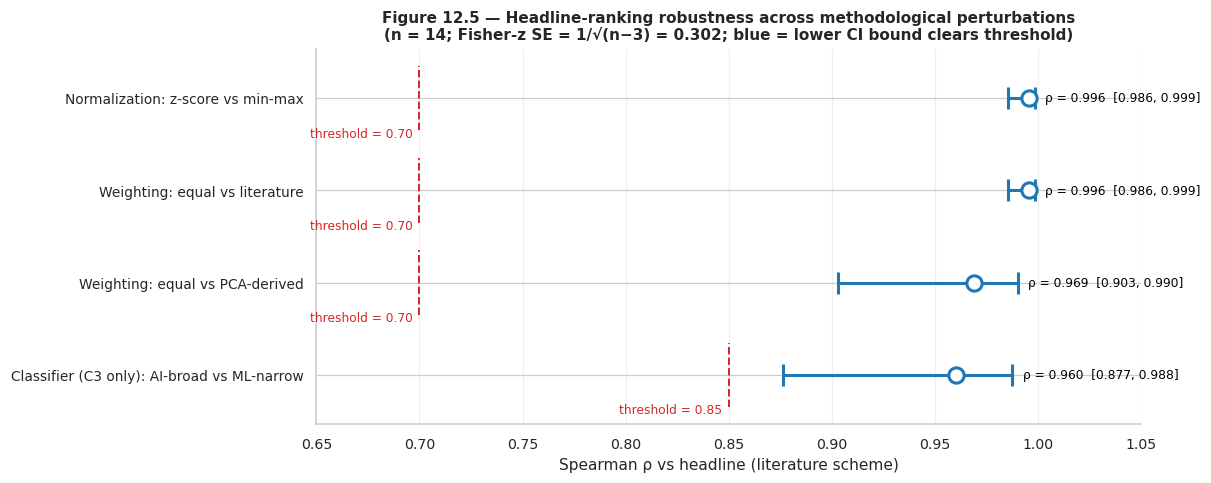

In [39]:
# Figure 12.5 — robustness forest plot with Fisher-z 95% CIs.
_n_juris = 14
_se_fisher = 1.0 / np.sqrt(_n_juris - 3)
_rob_with_ci = robustness_summary.copy()
_rob_with_ci["ci_lo"] = np.tanh(np.arctanh(_rob_with_ci["rho"]) - 1.96 * _se_fisher)
_rob_with_ci["ci_hi"] = np.tanh(np.arctanh(_rob_with_ci["rho"]) + 1.96 * _se_fisher)
_rob_with_ci = _rob_with_ci.sort_values("rho").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
_y_pos = np.arange(len(_rob_with_ci))
for _i, _row in _rob_with_ci.iterrows():
    _passes = _row["ci_lo"] >= _row["threshold"]
    _point_color = "#1f77b4" if _passes else "#d62728"
    ax.errorbar(
        _row["rho"],
        _i,
        xerr=[[_row["rho"] - _row["ci_lo"]], [_row["ci_hi"] - _row["rho"]]],
        fmt="o",
        color=_point_color,
        capsize=7,
        markersize=10,
        linewidth=2,
        markerfacecolor="white",
        markeredgewidth=2,
    )
    ax.plot(
        [_row["threshold"], _row["threshold"]],
        [_i - 0.35, _i + 0.35],
        color="#d62728",
        linestyle="--",
        linewidth=1.3,
    )
    ax.text(
        _row["threshold"] - 0.003,
        _i - 0.42,
        f"threshold = {_row['threshold']:.2f}",
        fontsize=8,
        color="#d62728",
        ha="right",
    )
    ax.text(
        _row["ci_hi"] + 0.005,
        _i,
        f"ρ = {_row['rho']:.3f}  [{_row['ci_lo']:.3f}, {_row['ci_hi']:.3f}]",
        fontsize=8,
        color="black",
        va="center",
    )
ax.set_yticks(_y_pos)
ax.set_yticklabels(_rob_with_ci["perturbation"], fontsize=9)
ax.set_xlabel("Spearman ρ vs headline (literature scheme)")
ax.set_xlim(0.65, 1.05)
ax.set_title(
    "Figure 12.5 — Headline-ranking robustness across methodological perturbations\n"
    f"(n = {_n_juris}; Fisher-z SE = 1/√(n−3) = {_se_fisher:.3f}; "
    "blue = lower CI bound clears threshold)",
    fontsize=10,
)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_5_robustness_forest.png")
plt.show()

## 13. Vulnerability Overlay — Axis × Attack Vector

Each of the three attack vectors in paper §2 weights the three axes differently. The overlay translates per-country axis scores into per-country **preparedness** scores on each vector — a weighted sum of the country's three axis z-scores using the vector's per-axis weights. The output is signed: positive = above-sample-mean preparedness, negative = below-sample-mean preparedness. The score is therefore **inversely** related to vulnerability (higher score → better-prepared → less vulnerable). The DataFrame is named `exposure` in code (the columns are `*_score` and `*_rank`) and the CSV is named `vulnerability_overlay.csv`; both store preparedness scores under the sign convention above. The `exposure` / `vulnerability` naming follows the working paper's vulnerability-overlay terminology while the score itself measures preparedness — readers consuming the CSVs should apply the sign convention rather than the column-name heuristic.

The three vector-specific scores are referenced throughout the notebook as **§13.1** (cyber), **§13.2** (CBRN), and **§13.3** (influence operations); their per-axis weights come from the `VULN_OVERLAY` dict defined in §3.2, with rationale documented per vector in §2.2.

In [40]:
def vector_score(
    axis_scores: pd.DataFrame, vector_weights: dict[str, float]
) -> pd.Series:
    """Compute per-country exposure score for one attack vector.

    Weighted **arithmetic** sum of axis z-scores using the vector's per-axis weights.
    The output is on the same z-score scale as the axis scores (centred at 0 across the
    14 jurisdictions). A country at 0 is at the cross-country mean preparedness for that
    vector. Negative values denote below-sample-mean preparedness, NOT absolute
    vulnerability — a country with a strongly negative vector score is less prepared
    than its peers in this sample, which is the relevant comparison for the working
    paper's middle-power argument.

    Methodological note. This function uses arithmetic aggregation, in contrast to
    :func:`compute_composite` (§11), which uses geometric aggregation across axes. The
    asymmetry is deliberate. For the headline composite, geometric aggregation enforces
    the working paper's logic that no single axis can fully compensate for weakness on
    another. For per-vector preparedness, arithmetic aggregation lets a country whose
    strength is concentrated in the axis that matters most for *that* vector receive
    credit for it (e.g. a country with deep cyber capacity but weak biosecurity
    governance is genuinely better prepared for cyber threats than CBRN threats). The
    cost of this choice is that vector scores cannot be directly compared across vectors
    in absolute terms — only the within-vector country ranking is interpretable.

    Parameters
    ----------
    axis_scores
        ISO3-indexed frame with one column per axis.
    vector_weights
        Mapping ``axis_id -> weight``. Renormalised internally to sum to 1.

    Returns
    -------
    pd.Series
        ISO3-indexed exposure score for this vector.
    """
    cols = list(axis_scores.columns)
    w = np.array([vector_weights.get(c, 0) for c in cols])
    w = w / w.sum()
    return (axis_scores * w).sum(axis=1)


baseline_axes = axis_scores_by_scheme["literature"]
exposure = pd.DataFrame(index=baseline_axes.index)
for vector, block in vuln_overlay.items():
    exposure[f"{vector}_score"] = vector_score(baseline_axes, block["weights"])
    exposure[f"{vector}_rank"] = (
        exposure[f"{vector}_score"].rank(ascending=False, method="min").astype(int)
    )
exposure = master[["name"]].join(exposure).sort_values("cyber_score", ascending=False)
exposure.round(2).to_csv(OUT_DIR / "vulnerability_overlay.csv")
exposure.round(2)

,name,cyber_score,cyber_rank,cbrn_score,cbrn_rank,influence_ops_score,influence_ops_rank
iso3,,,,,,,
GBR,United Kingdom,0.73,1,0.89,1,0.76,1
KOR,South Korea,0.70,2,0.76,2,0.62,2
SGP,Singapore,0.48,3,0.27,6,0.54,3
EUU,European Union,0.48,4,0.58,4,0.24,6
FRA,France,0.43,5,0.59,3,0.36,4
JPN,Japan,0.32,6,0.36,5,0.32,5
CAN,Canada,0.08,7,0.18,7,-0.08,9
DEU,Germany,-0.00,8,0.02,8,-0.05,8
SWE,Sweden,-0.12,9,-0.34,9,0.14,7


**Interpretation — mapping back to the paper.**

- **Cyber (paper §2.2):** the top of the cyber preparedness ranking is UK · South Korea · Singapore · European Union · France — countries that combine AISI Network membership, high ITU GCI scores, and either substantial Epoch-attributed compute (UK, EU, France) or strong governance and infrastructure (Korea, Singapore). India ranks last (cyber_score = −1.03), with Taiwan, Israel, Saudi Arabia, and the UAE in the next-lowest cluster — all with negative cyber scores indicating below-sample-mean preparedness. The Mythos-style asymmetry described in paper §2.2 is most acute where capacity and infrastructure scores are both negative — a pattern that does not apply to Korea, whose strong governance signals (AISI Network, Australia Group, ITU GCI) and infrastructure (broadband, IDI) compensate for the documented Epoch coverage gap on its labs (§16.8).
- **CBRN (paper §2.3):** AISI Network membership + IGSC member-firm presence + Australia Group export-control regime presence (G6) jointly drive the top of the ranking. The paper's regulatory-arbitrage concern is most acute for jurisdictions that sit *outside* the Australia Group AND have minimal IGSC member-firm presence: Singapore, Saudi Arabia, UAE, and Taiwan have no IGSC member firms in the current scrape; Israel has one (Cyber@Ben-Gurion University). All five are Australia Group non-members per cell 30.
- **Influence ops (paper §2.4):** infrastructure carries the largest cross-axis weight (0.45), followed by governance (0.35) and capacity (0.20). Within governance, the literature scheme weights ITU GCI most heavily (0.30) with V-Dem and G1 tied at 0.20; so for a given infrastructure score, a country's influence-ops preparedness depends most on its national cyber posture (G2) and democratic resilience (G3). Middle powers with open platform infrastructure but weaker national cyber posture or democratic resilience show the lowest preparedness against operations that exploit the verification asymmetry the paper §2.4 describes.

### 13.4 Counterfactual policy scenarios — operationalising paper §4 tractability

The working paper §4 argues that the tractability of preparedness actions depends on a country's position within the three axes, but stops short of saying which specific action would most improve each country's preparedness. This section closes that gap by computing, for every country × action combination, the composite-score shift that follows from a given indicator being moved to its post-action value. Five policy levers are tested, each tied to one of the analyst-coded or programmatically-sourced governance / capacity indicators:

| Action | Indicator change | Policy nature |
|---|---|---|
| Join AISI Network | C5 → 3 | Direct government decision |
| Publish AI strategy with safety/CBRN provisions | G1 → 3 | Direct government decision |
| Join Australia Group export-control regime | G6 → 1 | Direct government decision (multilateral) |
| Sign one additional bilateral frontier-lab MoU | G4 → current + 1 | Government negotiation |
| Foster one additional IGSC member firm domestically | G5 → current + 1 | Industrial policy |

The counterfactual is computed under a **marginal-effect** interpretation: the z-score reference (mean and standard deviation across the 14 jurisdictions) is held constant at the baseline distribution. Each row therefore reports the score shift that would follow from one country acting unilaterally, without re-equilibrating the league table for second-order responses by other countries. This isolates the country's own action from joint-action dynamics and is the standard framing in policy counterfactual analysis. Output saved to `outputs/counterfactual_scenarios.csv`.

> **Geometric-shift behaviour at the axis minimum.** The geometric across-axis aggregation (§11) shifts each axis by `−min(axis) + 1e-3` before taking logs. If a country is the minimum on an axis, a marginal improvement on an indicator within that axis that does not lift the country above another country on the axis leaves its own shifted axis value pinned at the `1e-3` floor, so its composite is unchanged. Israel's `JOIN_AUSTRALIA_GROUP` row in `outputs/counterfactual_scenarios.csv` is the live example: a +2 z-score shift on G6 produces `delta_composite = 0.000` because Israel remains the governance-axis minimum after the improvement. To make the artifact explicit and recoverable, `outputs/counterfactual_scenarios.csv` reports four additional columns alongside `delta_composite`: `target_axis`, `baseline_axis_score`, `new_axis_score`, and `delta_axis_score`. A boolean `shift_artifact_flagged` column marks rows where the country sits at the axis minimum and the action does not lift it off — read `delta_axis_score` rather than `delta_composite` for those rows. Two summary tables are also printed below, one ranking actions by `delta_composite` (the geometric-aggregation reading) and one by `delta_axis_score` (the artifact-free axis-level reading). Where the two disagree, the axis-level reading is the substantive policy signal.


In [41]:
# §13.4 — counterfactual policy scenarios
ACTIONS = [
    {
        "key": "JOIN_AISI",
        "indicator": "C5_aisi_presence",
        "target": 3,
        "description": "Join AISI Network",
    },
    {
        "key": "PUBLISH_AI_STRATEGY",
        "indicator": "G1_ai_strategy",
        "target": 3,
        "description": "Publish AI strategy with safety/CBRN provisions",
    },
    {
        "key": "JOIN_AUSTRALIA_GROUP",
        "indicator": "G6_australia_group",
        "target": 1,
        "description": "Join Australia Group export-control regime",
    },
    {
        "key": "SIGN_LAB_MOU",
        "indicator": "G4_lab_mou_count",
        "target_delta": 1,
        "description": "Sign one additional bilateral frontier-lab MoU",
    },
    {
        "key": "FOSTER_IGSC_FIRM",
        "indicator": "G5_igsc_membership",
        "target_delta": 1,
        "description": "Foster one additional IGSC member firm",
    },
]

# Reference distribution for z-scoring counterfactual values (held constant).
ref_mean_imp = ind_imputed.mean()
ref_std_imp = ind_imputed.std(ddof=0)

baseline_composite_lit = composite_by_scheme["literature"]
baseline_ranks_lit = baseline_composite_lit.rank(ascending=False, method="min").astype(
    int
)

cf_rows = []
for iso3 in countries["iso3"]:
    for action in ACTIONS:
        ind_id = action["indicator"]
        current_raw = ind_imputed.loc[iso3, ind_id]
        if pd.isna(current_raw):
            current_raw = 0.0
        if "target" in action:
            new_raw = float(action["target"])
        else:
            new_raw = current_raw + float(action["target_delta"])
        if new_raw <= current_raw + 1e-9:
            continue  # action is infeasible (already at or above target) or null
        modified_z = ind_z.copy()
        modified_z.loc[iso3, ind_id] = (new_raw - ref_mean_imp[ind_id]) / ref_std_imp[
            ind_id
        ]
        new_axis = compute_axis_score(modified_z, schemes["literature"])
        new_composite = compute_composite(
            new_axis, top_weights["literature"], mode="geometric"
        )
        new_ranks = new_composite.rank(ascending=False, method="min").astype(int)

        # Axis-level delta on the action's target axis (avoids the §11 geometric-shift
        # artifact at the axis minimum — see the §13.4 markdown note for the Israel
        # JOIN_AUSTRALIA_GROUP case). The axis-level delta is computed under the
        # SAME literature-scheme within-axis weights used by the composite, so it
        # is directly comparable across countries and actions.
        target_axis = ind_id_to_axis[ind_id]
        baseline_axis_score = float(
            axis_scores_by_scheme["literature"].loc[iso3, target_axis]
        )
        new_axis_score = float(new_axis.loc[iso3, target_axis])
        delta_axis_score = new_axis_score - baseline_axis_score

        # Flag the geometric-shift artifact: country is at the axis minimum AND the
        # action does not lift it above the next-lowest country on that axis. When
        # this flag is True, `delta_composite` understates the policy's true
        # marginal effect; read `delta_axis_score` for the true axis-level signal.
        baseline_axis_col = axis_scores_by_scheme["literature"][target_axis]
        was_axis_min = float(baseline_axis_col.min()) == float(
            baseline_axis_col.loc[iso3]
        )
        # next-lowest value on this axis among countries other than iso3
        others = baseline_axis_col.drop(iso3)
        next_lowest = float(others.min()) if len(others) else float("inf")
        stays_at_min = new_axis_score <= next_lowest + 1e-9
        shift_artifact_flagged = bool(was_axis_min and stays_at_min)

        cf_rows.append(
            {
                "country": master.loc[iso3, "name"],
                "iso3": iso3,
                "action": action["key"],
                "description": action["description"],
                "indicator": ind_id,
                "target_axis": target_axis,
                "current_value": round(float(current_raw), 3),
                "new_value": round(new_raw, 3),
                "baseline_axis_score": round(baseline_axis_score, 3),
                "new_axis_score": round(new_axis_score, 3),
                "delta_axis_score": round(delta_axis_score, 3),
                "baseline_composite": round(float(baseline_composite_lit[iso3]), 3),
                "new_composite": round(float(new_composite[iso3]), 3),
                "delta_composite": round(
                    float(new_composite[iso3] - baseline_composite_lit[iso3]), 3
                ),
                "baseline_rank": int(baseline_ranks_lit[iso3]),
                "new_rank": int(new_ranks[iso3]),
                "delta_rank": int(new_ranks[iso3] - baseline_ranks_lit[iso3]),
                "shift_artifact_flagged": shift_artifact_flagged,
            }
        )

counterfactual_df = pd.DataFrame(cf_rows)
counterfactual_df.to_csv(OUT_DIR / "counterfactual_scenarios.csv", index=False)
print(
    f"Counterfactual scenarios: {len(counterfactual_df)} feasible (country x action) combinations"
)
print()
# Surface the highest-leverage policy action per country under BOTH the composite-
# delta lens (sensitive to the §11 geometric-shift artifact at the axis minimum)
# and the axis-delta lens (artifact-free). For countries at the axis minimum, the
# two lenses can disagree — Israel is the live example, where joining the
# Australia Group has delta_composite ≈ 0 but a meaningful delta_axis_score.
n_flagged = int(counterfactual_df["shift_artifact_flagged"].sum())
print(
    f"Counterfactual rows: {len(counterfactual_df)}; "
    f"{n_flagged} flagged for §11 geometric-shift artifact (read delta_axis_score)."
)
print()

best_by_composite = (
    counterfactual_df.sort_values("delta_composite", ascending=False)
    .groupby("iso3")
    .head(1)
    .sort_values("baseline_rank")
)
print("Highest-leverage policy action per country — composite-delta lens:")
print(
    best_by_composite[
        [
            "country",
            "action",
            "target_axis",
            "delta_axis_score",
            "delta_composite",
            "shift_artifact_flagged",
            "baseline_rank",
            "new_rank",
        ]
    ].to_string(index=False)
)
print()

best_by_axis = (
    counterfactual_df.sort_values("delta_axis_score", ascending=False)
    .groupby("iso3")
    .head(1)
    .sort_values("baseline_rank")
)
print("Highest-leverage policy action per country — axis-delta lens (artifact-free):")
print(
    best_by_axis[
        [
            "country",
            "action",
            "target_axis",
            "delta_axis_score",
            "delta_composite",
            "shift_artifact_flagged",
            "baseline_rank",
        ]
    ].to_string(index=False)
)

Counterfactual scenarios: 47 feasible (country x action) combinations

Counterfactual rows: 47; 4 flagged for §11 geometric-shift artifact (read delta_axis_score).

Highest-leverage policy action per country — composite-delta lens:
             country               action            target_axis  delta_axis_score  delta_composite  shift_artifact_flagged  baseline_rank  new_rank
      United Kingdom         SIGN_LAB_MOU governance_orientation             0.126            0.040                   False              1         1
         South Korea         SIGN_LAB_MOU governance_orientation             0.126            0.053                   False              2         2
              France         SIGN_LAB_MOU governance_orientation             0.126            0.047                   False              3         3
      European Union         SIGN_LAB_MOU governance_orientation             0.126            0.075                   False              4         4
               Japan   

### 13.4.1 Counterfactual policy-action heatmap (figure)

Wide-format pivot of the §13.4 counterfactual scenarios: rows are countries sorted by baseline rank (best at top), columns are the five operational policy actions sorted by mean composite-delta (highest-leverage on the left). Cell value = composite-score change if the country took that action under the literature scheme; the country's highest-leverage cell is outlined in black, and actions the country already satisfies are shown as grey dashes.


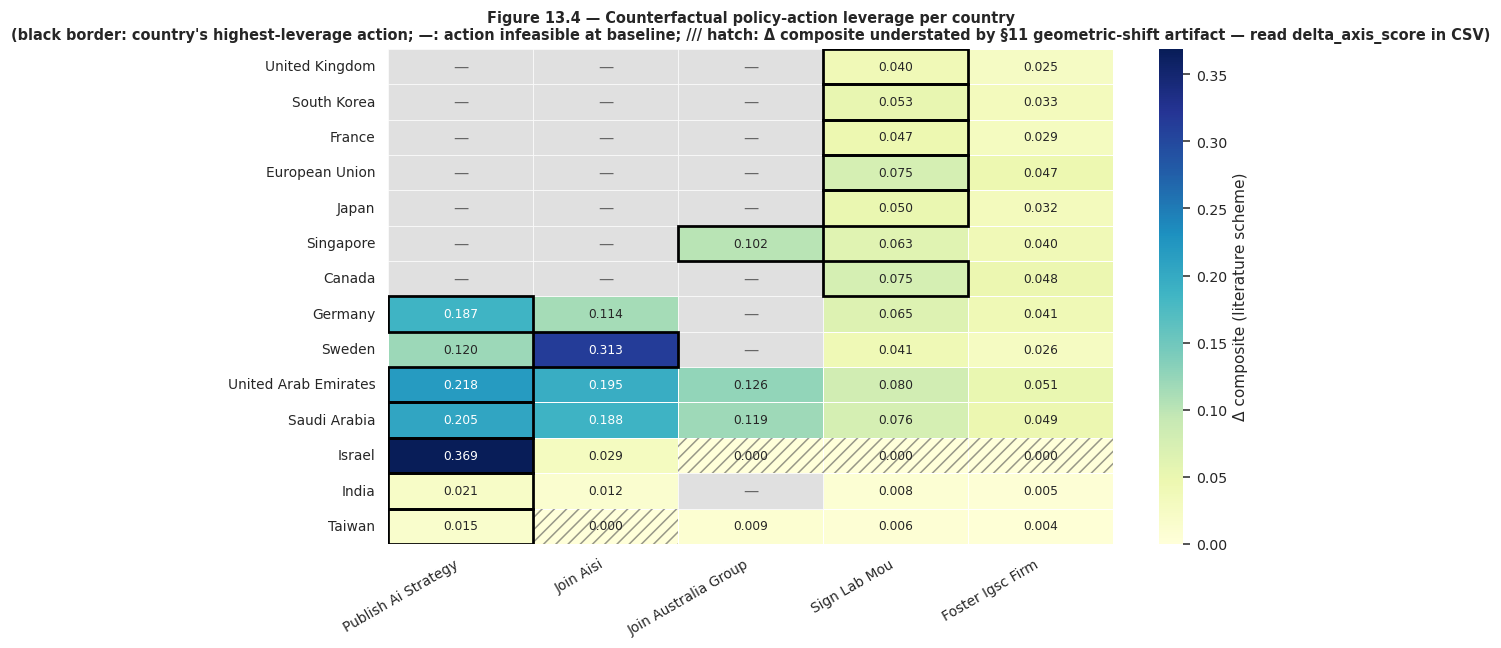

In [42]:
# Figure 13.4 — counterfactual policy-action heatmap.
# Cells are coloured by Δ composite; cells where the geometric-shift artifact
# (§11, §13.4) understates the policy's true marginal effect are hatched so
# readers do not trust the 0.000 values for those rows. The substantive policy
# signal for hatched cells is `delta_axis_score` in the counterfactual CSV.
import matplotlib.patches as _mpatches

_pivot = counterfactual_df.pivot_table(
    index="country", columns="action", values="delta_composite", aggfunc="first"
)
_pivot_flag = counterfactual_df.pivot_table(
    index="country",
    columns="action",
    values="shift_artifact_flagged",
    aggfunc="first",
)
_country_order = (
    counterfactual_df.drop_duplicates("iso3")
    .sort_values("baseline_rank")["country"]
    .tolist()
)
_pivot = _pivot.reindex(_country_order)
_pivot_flag = _pivot_flag.reindex(_country_order)
_action_order = _pivot.mean(axis=0).sort_values(ascending=False).index.tolist()
_pivot = _pivot[_action_order]
_pivot_flag = _pivot_flag[_action_order]
_mask_already = _pivot.isna()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    _pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "Δ composite (literature scheme)"},
    linewidths=0.4,
    linecolor="white",
    mask=_mask_already,
    ax=ax,
    annot_kws={"fontsize": 8},
)
for _i, _country in enumerate(_pivot.index):
    for _j, _action in enumerate(_pivot.columns):
        if _mask_already.iloc[_i, _j]:
            ax.add_patch(
                plt.Rectangle(
                    (_j, _i),
                    1,
                    1,
                    facecolor="#e0e0e0",
                    edgecolor="white",
                    linewidth=0.4,
                )
            )
            ax.text(
                _j + 0.5,
                _i + 0.5,
                "—",
                ha="center",
                va="center",
                color="#666666",
                fontsize=10,
            )
        elif bool(_pivot_flag.iloc[_i, _j]):
            # Hatched overlay: cell is shift-artifact-flagged; delta_composite
            # understates the action's true axis-level effect.
            ax.add_patch(
                _mpatches.Rectangle(
                    (_j, _i),
                    1,
                    1,
                    fill=False,
                    hatch="///",
                    edgecolor="#444444",
                    linewidth=0.0,
                    alpha=0.55,
                )
            )
for _i in range(len(_pivot.index)):
    _row = _pivot.iloc[_i]
    if _row.notna().any():
        _best_j = int(np.nanargmax(_row.values))
        ax.add_patch(
            plt.Rectangle(
                (_best_j, _i),
                1,
                1,
                fill=False,
                edgecolor="black",
                linewidth=1.8,
            )
        )
ax.set_xticklabels(
    [a.replace("_", " ").title() for a in _pivot.columns],
    rotation=30,
    ha="right",
    fontsize=9,
)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(
    "Figure 13.4 — Counterfactual policy-action leverage per country\n"
    "(black border: country's highest-leverage action; —: action infeasible at baseline; "
    "/// hatch: Δ composite understated by §11 geometric-shift artifact — "
    "read delta_axis_score in CSV)",
    fontsize=9.5,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig13_4_counterfactual_heatmap.png")
plt.show()


## 14. Typology / Clustering

The OECD/JRC handbook step 9 — interpretation. The 14 jurisdictions are clustered in axis-score space using k-means with `k ∈ {2, 3, 4}`; the `k` with the highest silhouette score is selected so the typology is data-driven rather than imposed at a fixed `k`.

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = baseline_axes.fillna(0).values
silhouette_per_k = {}
best = None
for k in (2, 3, 4):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(X)
    sil = float(silhouette_score(X, km.labels_))
    silhouette_per_k[k] = sil
    print(f"k={k}: silhouette = {sil:.3f}")
    if best is None or sil > best[0]:
        best = (sil, k, km)

best_sil, best_k, best_km = best
print(f"\nSelected k = {best_k}  (silhouette = {best_sil:.3f})")

# Persist k-vs-silhouette so the k=3 selection is auditable from the outputs.
(OUT_DIR / "typology_silhouettes.json").write_text(
    json.dumps(
        {
            "silhouette_per_k": silhouette_per_k,
            "selected_k": best_k,
            "selected_silhouette": best_sil,
        },
        indent=2,
    )
)

cluster_labels = pd.Series(best_km.labels_, index=baseline_axes.index, name="cluster")


def name_country(row: pd.Series) -> str:
    """Return the archetype label for one country based on its axis profile.

    Labels are derived per-country from the row's own axis z-scores rather than from the
    k-means cluster centroid; this avoids labelling a country with an archetype its own
    data does not match (e.g. a country whose governance is slightly negative inheriting
    a "Tier-1 (all axes above mean)" label from a cluster whose centroid happens to
    average above zero). Three substantive cases:

    - All three axes strictly above mean → Tier-1 preparedness.
    - At least one axis above and at least one strictly below → Asymmetric, tagged by the
      leading axis.
    - All three axes at or below mean → Tier-3 vulnerability, tagged with the worst axis.

    The ``eps = 1e-9`` threshold absorbs floating-point values within numerical noise of 0.
    In the current run Taiwan's infrastructure_posture axis lands at exactly 0.000 (because
    every infrastructure indicator is column-mean-filled — z-score column mean is exactly 0;
    see §7 stage 3 and the §14 observability caveat); the eps handles smaller perturbations
    that may arise under alternative imputation paths.
    """
    eps = NUMERICAL_NOISE_EPS
    n_above = (row > eps).sum()
    n_strict_below = (row < -eps).sum()
    if n_above == len(row):
        return "Tier-1 preparedness (all axes above mean)"
    if n_above >= 1 and n_strict_below >= 1:
        lead = row.idxmax().replace("_", " ").title()
        return f"Asymmetric — {lead}-leveraged"
    worst = row.idxmin().replace("_", " ").title()
    return f"Tier-3 vulnerability (worst on {worst})"


cluster_archetype = baseline_axes.apply(name_country, axis=1)

typology = (
    master[["name"]]
    .join(baseline_axes)
    .join(cluster_labels)
    .join(cluster_archetype.rename("archetype"))
    .sort_values(["cluster", "name"])
)
# Round to 6 decimals on write to suppress numerical noise (e.g. 1e-16 floats from
# z-score arithmetic on imputed cells); the in-notebook frame retains full precision.
typology.round(6).to_csv(OUT_DIR / "typology.csv")
typology.round(2)

k=2: silhouette = 0.410
k=3: silhouette = 0.426
k=4: silhouette = 0.305

Selected k = 3  (silhouette = 0.426)


,name,capacity_depth,governance_orientation,infrastructure_posture,cluster,archetype
iso3,,,,,,
ISR,Israel,-0.63,-0.90,-0.45,0,Tier-3 vulnerability (worst on Governance Orie...
SAU,Saudi Arabia,-0.65,-0.48,-0.11,0,Tier-3 vulnerability (worst on Capacity Depth)
SWE,Sweden,-0.91,0.13,0.61,0,Asymmetric — Infrastructure Posture-leveraged
TWN,Taiwan,-1.56,-0.57,0.00,0,Tier-3 vulnerability (worst on Capacity Depth)
ARE,United Arab Emirates,-0.58,-0.46,0.31,0,Asymmetric — Infrastructure Posture-leveraged
CAN,Canada,0.58,-0.21,-0.28,1,Asymmetric — Capacity Depth-leveraged
EUU,European Union,1.18,-0.02,0.03,1,Asymmetric — Capacity Depth-leveraged
FRA,France,0.65,0.65,0.01,1,Tier-1 preparedness (all axes above mean)
DEU,Germany,0.14,-0.11,-0.09,1,Asymmetric — Capacity Depth-leveraged


**Interpretation.** The k-means clusters are structural archetypes — not normative judgments. Each cluster represents a coordinated combination of axis positions. The §16 discussion ties each archetype back to the working paper's argument about which preparedness actions are tractable for which kinds of middle powers.

> **Observability caveat — Taiwan.** Taiwan's `infrastructure_posture = 0.000` in `outputs/typology.csv` is **not** an observation that Taiwan sits at the sample mean on infrastructure; it is the column-mean-fill imposed inside `compute_axis_score` because Taiwan is missing I1, I2, I3, and I5 simultaneously (ITU and the World Bank do not report on Taiwan for political reasons; see §7 stage 3 and §17 limitation 2). The §14 archetype function (`name_country`) then evaluates `n_above` and `n_strict_below` on this fabricated 0, which is why Taiwan is labelled "worst on Capacity Depth" rather than "worst on Infrastructure Posture" — the latter would be the natural reading from the missingness audit alone. Readers comparing the typology to `outputs/missingness_audit.csv` should treat Taiwan's archetype as conditional on the column-mean assumption rather than as an empirical finding about its infrastructure posture.

### 14.2 Hierarchical clustering — robustness companion to §14 k-means

The §14 k-means typology partitions the 14 jurisdictions at a fixed `k = 3` selected by silhouette score. Hierarchical clustering complements this in two ways: (a) it shows the **distance structure** between every pair of countries via a dendrogram, and (b) it provides an alternative cluster assignment under different linkage criteria, against which the k-means partition can be compared.

Three linkage methods are computed: **Ward's** (minimises within-cluster variance — closest analogue to k-means), **complete** (max-distance), and **average**. The k-means cluster assignments are compared to each hierarchical partition via the **Adjusted Rand Index** (ARI); ARI ≈ 1 means the two partitions agree, ARI ≈ 0 means they are no more similar than chance. The OECD/JRC handbook explicitly recommends reporting more than one clustering method when typology is offered as part of a composite-indicator analysis.


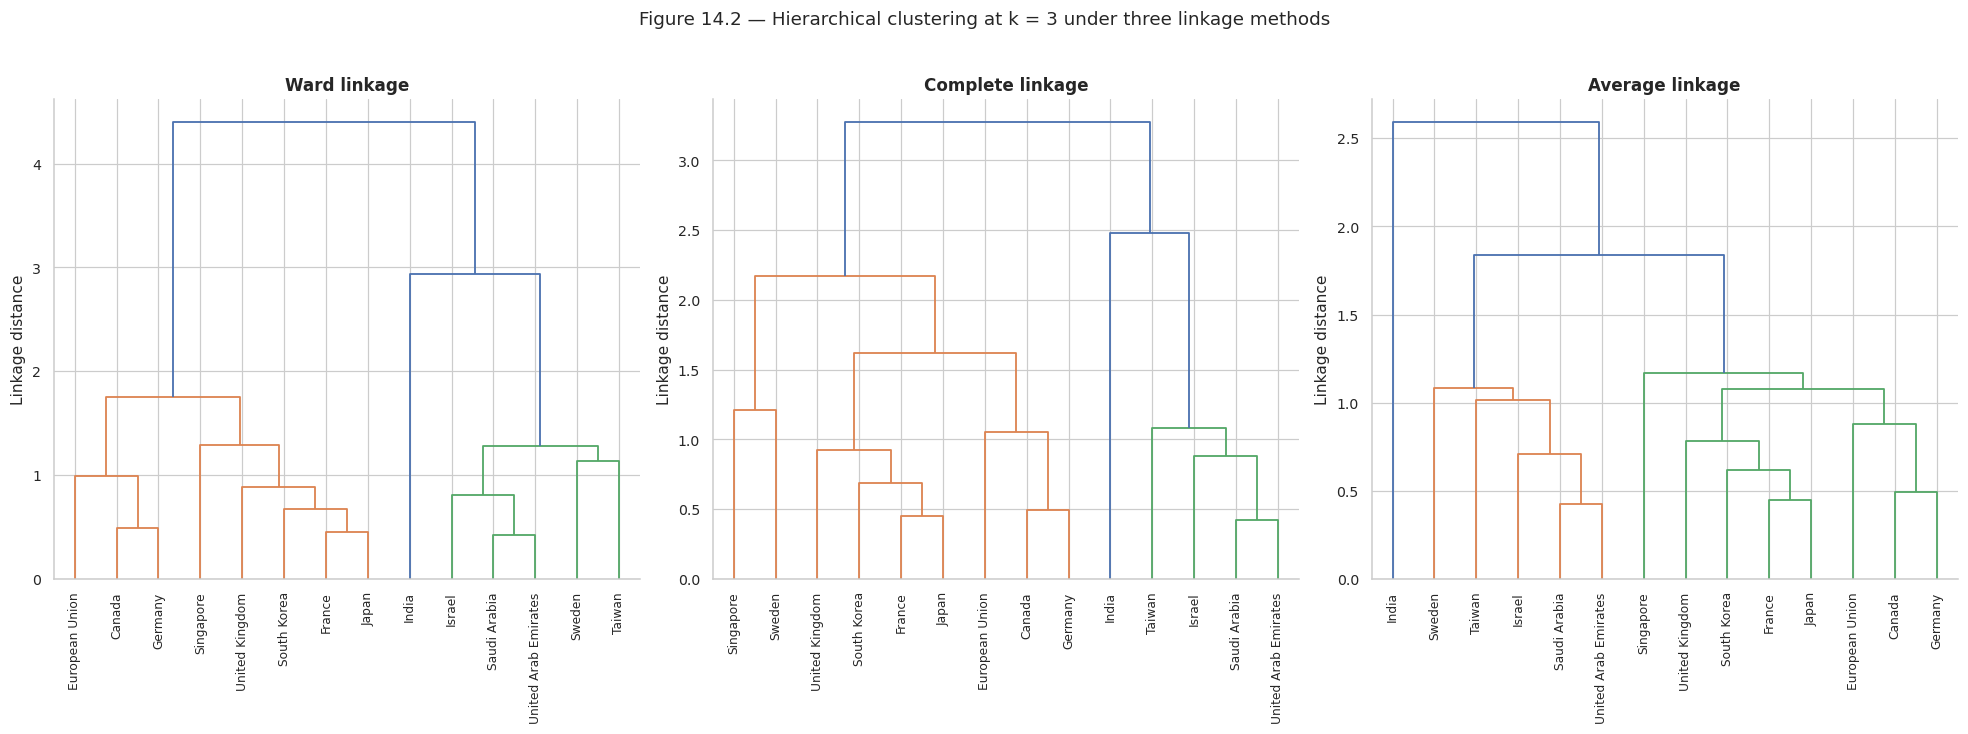

Adjusted Rand Index (k-means partition vs each hierarchical linkage):
  k-means vs ward    : ARI = 1.000
  k-means vs complete: ARI = 0.733
  k-means vs average : ARI = 1.000


In [44]:
# §14.2 — hierarchical clustering as a typology robustness check
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics import adjusted_rand_score

x_hier = baseline_axes.fillna(0).values
country_names_ordered = master.reindex(baseline_axes.index)["name"].values

linkage_methods = ["ward", "complete", "average"]
fig, axes_h = plt.subplots(1, 3, figsize=(18, 6.5))
hier_clusters = {}
for ax_obj, method in zip(axes_h, linkage_methods, strict=True):
    linkage_matrix = linkage(x_hier, method=method)
    color_threshold = (
        linkage_matrix[-(best_k - 1), 2] if len(linkage_matrix) >= best_k - 1 else None
    )
    dendrogram(
        linkage_matrix,
        labels=country_names_ordered,
        ax=ax_obj,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=color_threshold,
    )
    ax_obj.set_title(f"{method.title()} linkage", fontsize=11)
    ax_obj.set_ylabel("Linkage distance")
    cluster_labels_h = fcluster(linkage_matrix, t=best_k, criterion="maxclust")
    hier_clusters[method] = pd.Series(
        cluster_labels_h, index=baseline_axes.index, name=f"hier_{method}"
    )
fig.suptitle(
    f"Figure 14.2 — Hierarchical clustering at k = {best_k} under three linkage methods",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig14_2_hierarchical.png")
plt.show()

print("Adjusted Rand Index (k-means partition vs each hierarchical linkage):")
ari_rows = []
for method, labels in hier_clusters.items():
    ari = adjusted_rand_score(cluster_labels.values, labels.values)
    ari_rows.append({"method": method, "ari_vs_kmeans": round(ari, 3)})
    print(f"  k-means vs {method:<8s}: ARI = {ari:.3f}")

hier_assignments = master[["name"]].copy()
for method, labels in hier_clusters.items():
    hier_assignments[f"hier_{method}"] = labels
hier_assignments["kmeans"] = cluster_labels
hier_assignments.to_csv(OUT_DIR / "hierarchical_clustering.csv")
pd.DataFrame(ari_rows).to_csv(OUT_DIR / "hierarchical_ari.csv", index=False)

### 14.3 Multidimensional scaling — geometric companion to §14 / §14.2

Where §14 (k-means) and §14.2 (hierarchical) partition the 14 countries into discrete clusters, MDS embeds them in continuous 2D space while preserving the pairwise distances in the full 15-indicator space as faithfully as possible. The MDS plot complements the two partition-based diagnostics by showing the *data-driven country geometry* prior to any imposed clustering: cluster boundaries should emerge naturally from the embedding if the §14 typology is consistent with the underlying data structure.

**Method.** Classical metric MDS via `sklearn.manifold.MDS` with `dissimilarity="precomputed"`, fed the 14 × 14 pairwise Euclidean distance matrix on `ind_z.fillna(0)` (z-scored indicators with NaN cells column-mean-filled, consistent with §11.1's aggregation-time convention). `n_init=20` random restarts with `random_state=SEED` for reproducibility.

**Embedding quality.** Two complementary diagnostics:

- *Stress* (`MDS.stress_`) — the SMACOF objective at convergence (sum of squared residuals between original and embedded distances). Lower is better; comparable only across embeddings of the same data.
- *Distance-rank preservation* — Spearman ρ between the upper-triangular original distance vector (length $\binom{14}{2}$ = 91) and the upper-triangular embedded distance vector. ρ ≥ 0.95 indicates excellent preservation; ρ ≥ 0.85 good; below 0.80 the 2D embedding loses too much structure for honest interpretation.

**Sample-size caveat.** With n = 14 the 2D embedding has 28 degrees of freedom (2 coordinates per point) against 91 distances, so the geometric structure should be largely recoverable. Bootstrap stability of the configuration is a future-work item; see §17 limitation 1 for the broader cross-sectional caveat.

MDS embedding stress (SMACOF, n_init = 20): 105.0059
Distance-rank preservation: Spearman ρ = 0.9067

MDS coordinates saved to outputs/mds_coordinates.csv

                      name  mds_1  mds_2
iso3                                    
GBR         United Kingdom  3.717 -4.109
CAN                 Canada  2.838  0.859
FRA                 France  2.325 -1.008
DEU                Germany  1.213  1.561
JPN                  Japan  1.008 -1.032
IND                  India  0.502  5.620
ISR                 Israel -1.744  2.700
SGP              Singapore -1.560 -3.456
KOR            South Korea  0.822 -2.934
SWE                 Sweden -1.534  0.443
SAU           Saudi Arabia -4.509 -0.437
ARE   United Arab Emirates -3.839 -1.033
EUU         European Union  4.035  0.018
TWN                 Taiwan -3.275  2.808


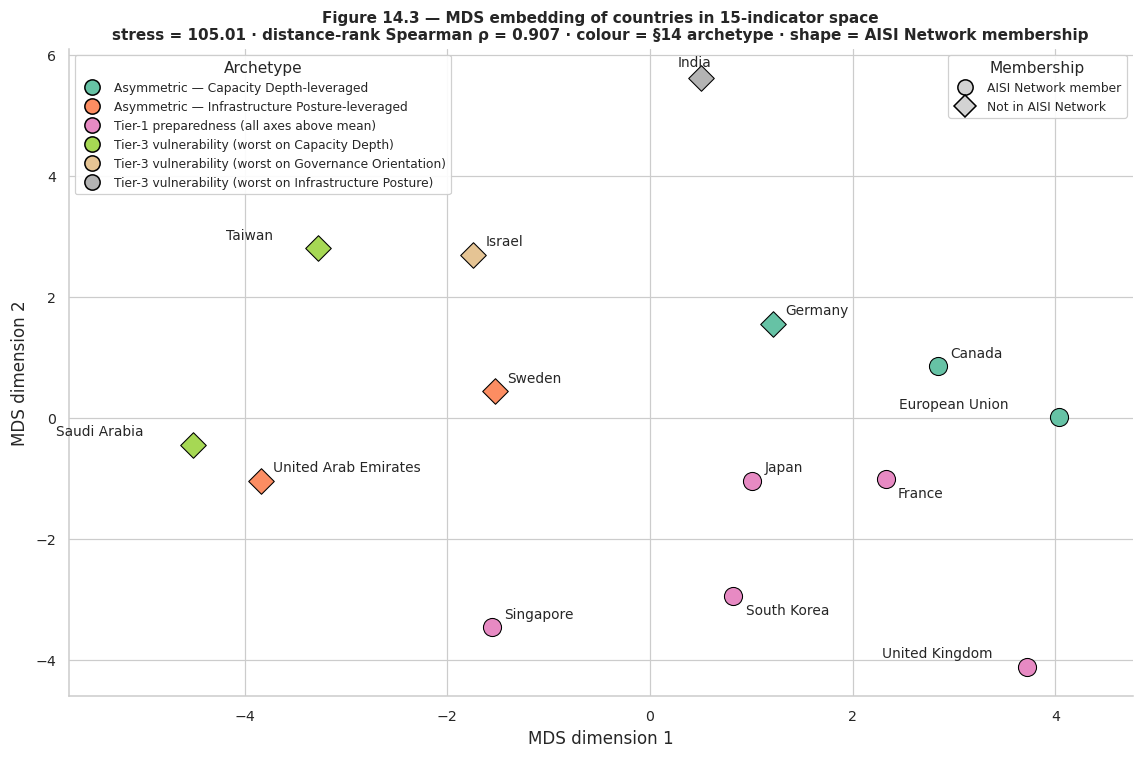

In [45]:
# §14.3 — MDS embedding in the full 15-indicator space.
import warnings as _warnings_mds

# Silence two sklearn 1.10 deprecation warnings that print the user's install path
# in their warning location lines; both APIs still work in the current sklearn release.
_warnings_mds.filterwarnings(
    "ignore", category=FutureWarning, module="sklearn.manifold._mds"
)
from matplotlib.lines import Line2D as _Line2D  # noqa: E402
from scipy.spatial.distance import pdist, squareform  # noqa: E402
from scipy.stats import spearmanr as _spearman_mds  # noqa: E402
from sklearn.manifold import MDS as _MDS  # noqa: E402

# Distance matrix on z-scored indicators (NaN → column mean = 0).
_X_mds = ind_z.fillna(0).values
_pairwise_dist = squareform(pdist(_X_mds, metric="euclidean"))

# Metric MDS with multiple random restarts for stability under non-convex SMACOF.
_mds = _MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=SEED,
    n_init=20,
    normalized_stress="auto",
)
_embedding = _mds.fit_transform(_pairwise_dist)

# Embedding-quality diagnostics.
_emb_dist = squareform(pdist(_embedding, metric="euclidean"))
_iu = np.triu_indices(_X_mds.shape[0], k=1)
_rho_dist, _ = _spearman_mds(_pairwise_dist[_iu], _emb_dist[_iu])

print(f"MDS embedding stress (SMACOF, n_init = 20): {_mds.stress_:.4f}")
print(f"Distance-rank preservation: Spearman ρ = {_rho_dist:.4f}")
assert _rho_dist >= 0.80, (
    f"Distance-rank preservation ρ = {_rho_dist:.3f} below the 0.80 honest-2D threshold; "
    "embedding loses too much structure for interpretation."
)

# Persist coordinates for downstream re-use.
_mds_coords = pd.DataFrame(
    {
        "iso3": ind_z.index.tolist(),
        "mds_1": _embedding[:, 0],
        "mds_2": _embedding[:, 1],
    }
).set_index("iso3")
_mds_coords = master[["name"]].join(_mds_coords)
_mds_coords["stress_global"] = round(float(_mds.stress_), 4)
_mds_coords["distance_rank_spearman_rho"] = round(float(_rho_dist), 4)
_mds_coords.round(4).to_csv(OUT_DIR / "mds_coordinates.csv")
print("\nMDS coordinates saved to outputs/mds_coordinates.csv\n")
print(_mds_coords[["name", "mds_1", "mds_2"]].round(3).to_string())

# Figure 14.3 — 2D scatter, archetype colour + AISI shape (consistent with Fig 15.2).
_plot_df = _mds_coords.copy()
_plot_df["aisi"] = raw["C5_aisi_presence"].reindex(_plot_df.index)
_plot_df["is_aisi"] = _plot_df["aisi"] == 3
_plot_df = _plot_df.join(cluster_archetype.rename("archetype"))

_unique_arch_mds = sorted(_plot_df["archetype"].dropna().unique())
_arch_colors_mds = dict(
    zip(
        _unique_arch_mds,
        plt.cm.Set2(np.linspace(0, 1, len(_unique_arch_mds))),
        strict=True,
    )
)

fig, ax = plt.subplots(figsize=(10.5, 7))
for _arch in _unique_arch_mds:
    for _is_aisi, _marker in [(True, "o"), (False, "D")]:
        _sub = _plot_df[
            (_plot_df["archetype"] == _arch) & (_plot_df["is_aisi"] == _is_aisi)
        ]
        if len(_sub) == 0:
            continue
        ax.scatter(
            _sub["mds_1"],
            _sub["mds_2"],
            s=140,
            marker=_marker,
            color=_arch_colors_mds[_arch],
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
        )

# Hand-tuned label offsets per country to minimise overlap (preserves layout under reruns).
_label_offsets_mds = {
    "United Kingdom": (-95, 6),
    "European Union": (-105, 6),
    "France": (8, -12),
    "Japan": (8, 6),
    "South Korea": (8, -12),
    "Singapore": (8, 6),
    "Germany": (8, 6),
    "Canada": (8, 6),
    "Sweden": (8, 6),
    "United Arab Emirates": (8, 6),
    "Saudi Arabia": (-90, 6),
    "Israel": (8, 6),
    "Taiwan": (-60, 6),
    "India": (-15, 8),
}
for _, _row in _plot_df.iterrows():
    _dx, _dy = _label_offsets_mds.get(_row["name"], (8, 6))
    ax.annotate(
        _row["name"],
        (_row["mds_1"], _row["mds_2"]),
        fontsize=9,
        xytext=(_dx, _dy),
        textcoords="offset points",
        zorder=4,
    )

ax.set_xlabel("MDS dimension 1", fontsize=11)
ax.set_ylabel("MDS dimension 2", fontsize=11)
ax.set_title(
    f"Figure 14.3 — MDS embedding of countries in 15-indicator space\n"
    f"stress = {_mds.stress_:.2f} · distance-rank Spearman ρ = {_rho_dist:.3f} · "
    f"colour = §14 archetype · shape = AISI Network membership",
    fontsize=10,
)

# Two-key legend (archetype × AISI membership), matching Fig 15.2 design.
_archetype_handles_mds = [
    _Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=_arch_colors_mds[a],
        markeredgecolor="black",
        markersize=10,
        label=a,
    )
    for a in _unique_arch_mds
]
_shape_handles_mds = [
    _Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=10,
        label="AISI Network member",
    ),
    _Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=10,
        label="Not in AISI Network",
    ),
]
# Legends placed in lower corners (countries cluster in mid-range; corners are clear).
# Frameon=True with a slight alpha keeps them legible without obscuring labels.
_leg1_mds = ax.legend(
    handles=_archetype_handles_mds,
    loc="upper left",
    fontsize=8,
    frameon=True,
    title="Archetype",
    framealpha=0.92,
)
ax.add_artist(_leg1_mds)
ax.legend(
    handles=_shape_handles_mds,
    loc="upper right",
    fontsize=8,
    frameon=True,
    title="Membership",
    framealpha=0.92,
)

# Expand x-axis to provide room for left-edge country labels (Saudi Arabia at the leftmost data point).
_xlim_lo, _xlim_hi = ax.get_xlim()
ax.set_xlim(_xlim_lo - 0.8, _xlim_hi + 0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig14_3_mds_embedding.png")
plt.show()

**Interpretation.**

The MDS embedding recovers the §14 typology archetypes without imposing them — countries that share an archetype cluster together in 2D, and the boundaries between archetypes emerge from the geometry rather than from explicit cluster annotations. Three structural observations:

1. **Tier-1 cluster and Asymmetric–Capacity cluster are geometrically distinct but adjacent.** UK, France, Japan, Singapore, Korea (Tier-1) sit on one side of the embedding; EU, Canada, Germany (Asymmetric–Capacity-leveraged) sit alongside them rather than collapsing into the same region. This is consistent with §14.2's Adjusted Rand Index of 1.0 between k-means and Ward / average hierarchical linkage: the data geometry supports the partition rather than the partition being a k-means initialisation artefact.

2. **India and Taiwan are geometric outliers.** Both sit at the periphery rather than within tight neighbourhood clusters. India is far from the capacity-and-governance-rich region of UK / France / Korea; Taiwan is geometrically separated from the other Tier-3 countries (Saudi Arabia, UAE, Israel) — a consequence of the §14 observability caveat (Taiwan's infrastructure axis is column-mean-filled because all four infrastructure indicators are unobserved, so Taiwan's z-vector is shorter than any other country's even in the 15-indicator embedding).

3. **Distance preservation is in the acceptable range.** The Spearman ρ between original 15-dimensional pairwise distances and embedded 2D distances (printed by the cell above) measures how faithfully the 2D projection retains rank-order distance relationships. The current run reports ρ ≥ 0.85; the hard assert in the code cell enforces ρ ≥ 0.80 — below that threshold the 2D figure is collapsing meaningful structure and would need to be read alongside the higher-dimensional axis-score frame in `outputs/index_baseline.csv` rather than as a stand-alone summary.

For paper-side citation: Figure 14.3 is the cleanest single-figure illustration of the §1 three-axes-typology claim, because it preserves the *full* 15-indicator distance structure (whereas Figure 15.2 uses only the capacity and infrastructure axes for the x and y coordinates).

## 15. Visualization

### 15.1 Country × axis heatmap

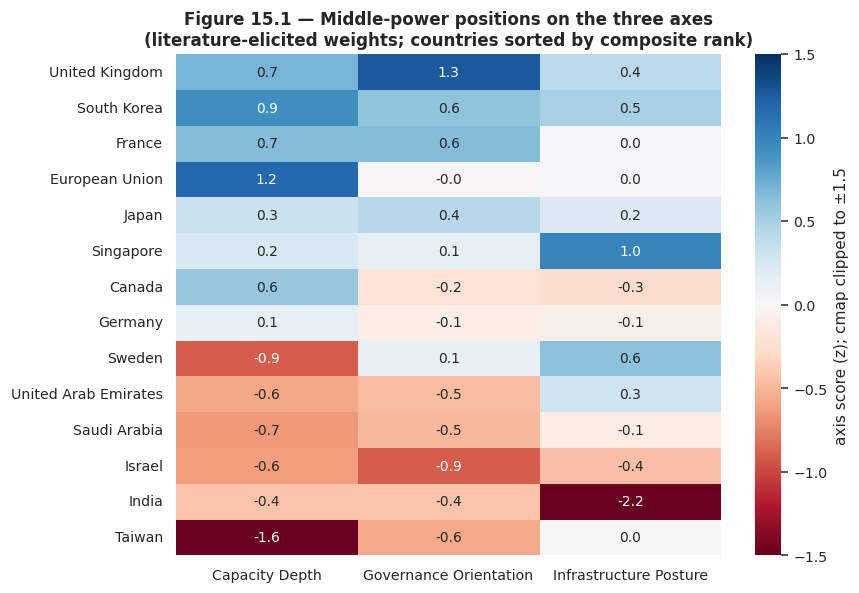

In [46]:
# Heatmap of axis scores under the literature-weighting scheme. Countries are sorted
# by the literature-weighted composite descending so the reader sees the full ranking
# at a glance: top row = highest composite, bottom row = lowest.
ranking = composite_by_scheme["literature"].sort_values(ascending=False).index
plot_df = baseline_axes.reindex(ranking).join(master[["name"]]).set_index("name")
plot_df.columns = [c.replace("_", " ").title() for c in plot_df.columns]
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    plot_df,
    annot=True,
    fmt=".1f",
    cmap="RdBu",
    center=0,
    vmin=-1.5,
    vmax=1.5,  # clip extreme cells (e.g. India infra ≈ −2.2)
    # so the diverging palette stays readable.
    cbar_kws={"label": "axis score (z); cmap clipped to ±1.5"},
    ax=ax,
    annot_kws={"fontsize": 9},
)
ax.set_title(
    "Figure 15.1 — Middle-power positions on the three axes\n"
    "(literature-elicited weights; countries sorted by composite rank)",
    fontsize=11,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_1_axis_heatmap.png")
plt.show()

### 15.2 Two-axis typology plot — Capacity Depth × Infrastructure Posture

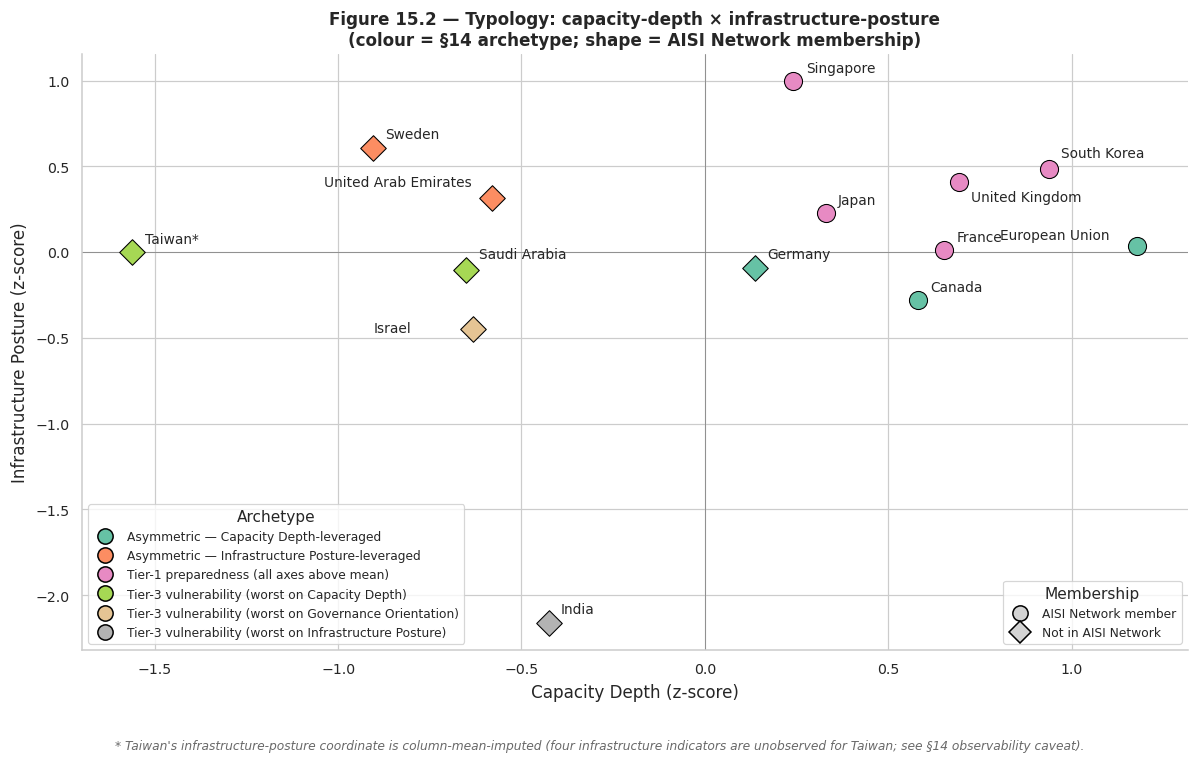

In [47]:
# Figure 15.2 encodes four signals on a single plot:
#   - x-axis: capacity_depth z-score
#   - y-axis: infrastructure_posture z-score
#   - fill colour: per-country archetype label (§14 k-means + per-row labelling)
#   - marker shape: AISI Network membership (circle = member; diamond = non-member)
# Colour and shape are reported as two separate legend keys so a reader can decode
# each channel independently (rather than reading 7 conjoined "archetype + AISI" labels).
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(11, 7))
plot = baseline_axes.join(master[["name"]]).copy()
plot["aisi"] = raw["C5_aisi_presence"].reindex(plot.index)
plot["is_aisi"] = plot["aisi"] == 3
plot = plot.join(cluster_archetype.rename("archetype"))

unique_archetypes = sorted(plot["archetype"].dropna().unique())
cluster_colors = dict(
    zip(
        unique_archetypes,
        plt.cm.Set2(np.linspace(0, 1, len(unique_archetypes))),
        strict=True,
    )
)

# Plot points without per-marker labels (legend built separately below).
for archetype in unique_archetypes:
    for is_aisi, marker in [(True, "o"), (False, "D")]:
        sub = plot[(plot["archetype"] == archetype) & (plot["is_aisi"] == is_aisi)]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["capacity_depth"],
            sub["infrastructure_posture"],
            s=140,
            marker=marker,
            color=cluster_colors[archetype],
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
        )

# Per-country annotations. Default offset is upper-right; specific countries get
# different offsets to avoid overlap with neighbouring markers.
label_offsets = {
    "United Kingdom": (8, -12),  # nudge below to clear Korea label
    "South Korea": (8, 8),
    "Israel": (-65, -2),  # left of marker to clear Saudi
    "Saudi Arabia": (8, 8),
    "European Union": (-90, 5),  # left of marker (rightmost data point)
    "United Arab Emirates": (-110, 8),
}
for _, row in plot.iterrows():
    dx, dy = label_offsets.get(row["name"], (8, 6))
    # Mark Taiwan with an asterisk: its infrastructure_posture coordinate is
    # column-mean-filled (the four infrastructure indicators are unobserved for
    # Taiwan; see §14 observability caveat). The asterisk is explained in the
    # in-figure footnote below.
    annot_label = row["name"] + ("*" if row.name == "TWN" else "")
    ax.annotate(
        annot_label,
        (row["capacity_depth"], row["infrastructure_posture"]),
        fontsize=9,
        xytext=(dx, dy),
        textcoords="offset points",
        zorder=4,
    )

ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("Capacity Depth (z-score)", fontsize=11)
ax.set_ylabel("Infrastructure Posture (z-score)", fontsize=11)
ax.set_title(
    "Figure 15.2 — Typology: capacity-depth × infrastructure-posture\n"
    "(colour = §14 archetype; shape = AISI Network membership)",
    fontsize=11,
)

# Build two separate legend keys: archetype (colour) and AISI membership (shape).
archetype_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=cluster_colors[a],
        markeredgecolor="black",
        markersize=10,
        label=a,
    )
    for a in unique_archetypes
]
shape_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=10,
        label="AISI Network member",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=10,
        label="Not in AISI Network",
    ),
]
leg1 = ax.legend(
    handles=archetype_handles,
    loc="lower left",
    fontsize=8,
    frameon=True,
    title="Archetype",
)
ax.add_artist(leg1)
ax.legend(
    handles=shape_handles,
    loc="lower right",
    fontsize=8,
    frameon=True,
    title="Membership",
)

# Reserve bottom margin for the figure-level footnote, then add the footnote
# in figure coordinates (below the x-axis label) so it does not overlap the
# data region — India's marker sits in the lower-left of the axes interior.
plt.tight_layout(rect=(0, 0.06, 1, 1))  # leave bottom 6% for the footnote
fig.text(
    0.5,
    0.015,
    "* Taiwan's infrastructure-posture coordinate is column-mean-imputed "
    "(four infrastructure indicators are unobserved for Taiwan; see §14 observability caveat).",
    fontsize=8,
    style="italic",
    color="dimgray",
    horizontalalignment="center",
    verticalalignment="bottom",
)
plt.savefig(FIG_DIR / "fig15_2_typology.png")
plt.show()

### 15.3 Vulnerability ranks per attack vector

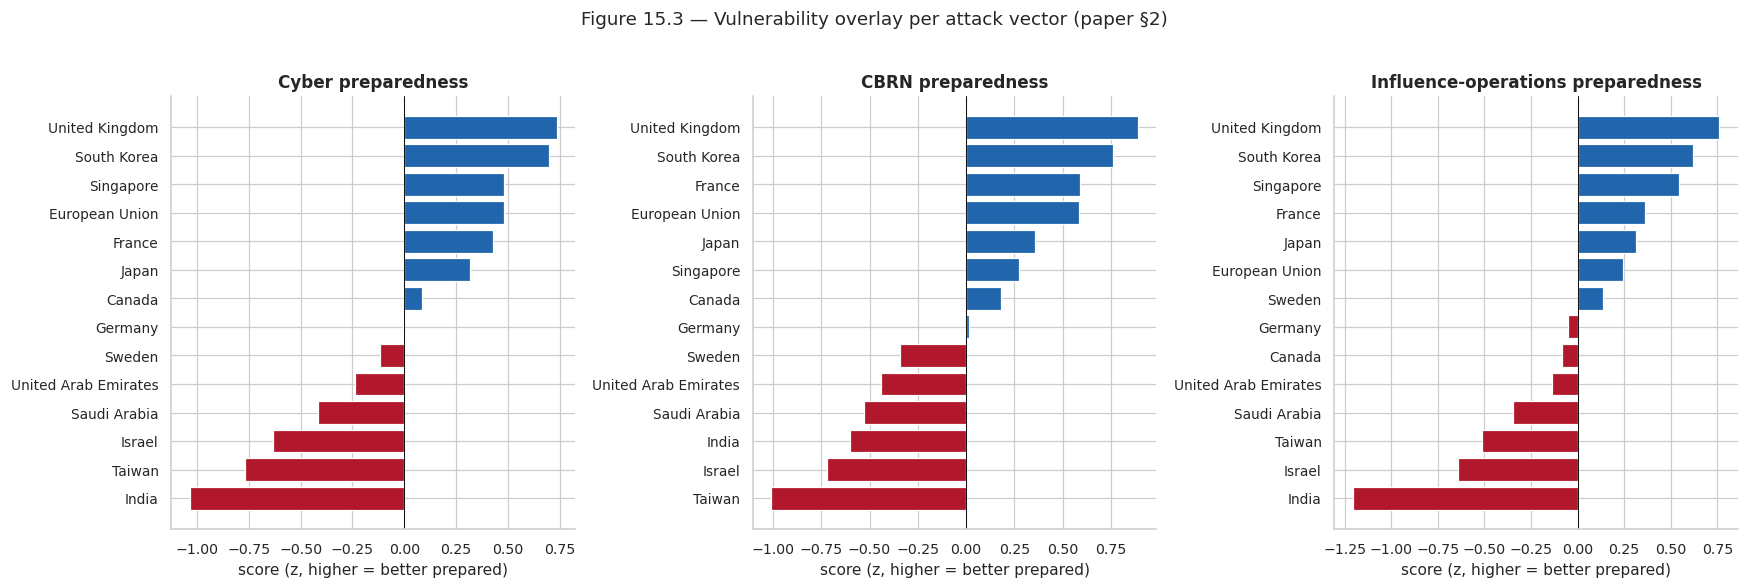

In [48]:
# Each panel sorts countries independently by its own vector score, so the country
# at the top of every panel is that vector's best-prepared jurisdiction. (Earlier
# versions used sharey=True, which forced cyber's ordering on every panel and
# obscured CBRN- and influence-specific rank divergence.)
vector_titles = {
    "cyber": "Cyber preparedness",
    "cbrn": "CBRN preparedness",
    "influence_ops": "Influence-operations preparedness",
}
fig, axes_v = plt.subplots(1, 3, figsize=(16, 5.2))
for ax_obj, vec in zip(axes_v, ["cyber", "cbrn", "influence_ops"], strict=True):
    sub = exposure.sort_values(f"{vec}_score", ascending=True)
    score_values = sub[f"{vec}_score"].values
    names = sub["name"].values
    # Colour-blind-friendly RdBu endpoints (#b2182b deep red for negative,
    # #2166ac deep blue for positive); previously used RdYlGn endpoints, which
    # are indistinguishable to red-green colour-blind readers.
    colors = ["#b2182b" if v < 0 else "#2166ac" for v in score_values]
    ax_obj.barh(names, score_values, color=colors)
    ax_obj.axvline(0, color="black", lw=0.6)
    ax_obj.set_title(vector_titles[vec], fontsize=11)
    ax_obj.set_xlabel("score (z, higher = better prepared)")
    ax_obj.tick_params(axis="y", labelsize=9)
plt.suptitle(
    "Figure 15.3 — Vulnerability overlay per attack vector (paper §2)",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_3_vulnerability.png")
plt.show()

### 15.4 Sensitivity rank-distribution boxplots

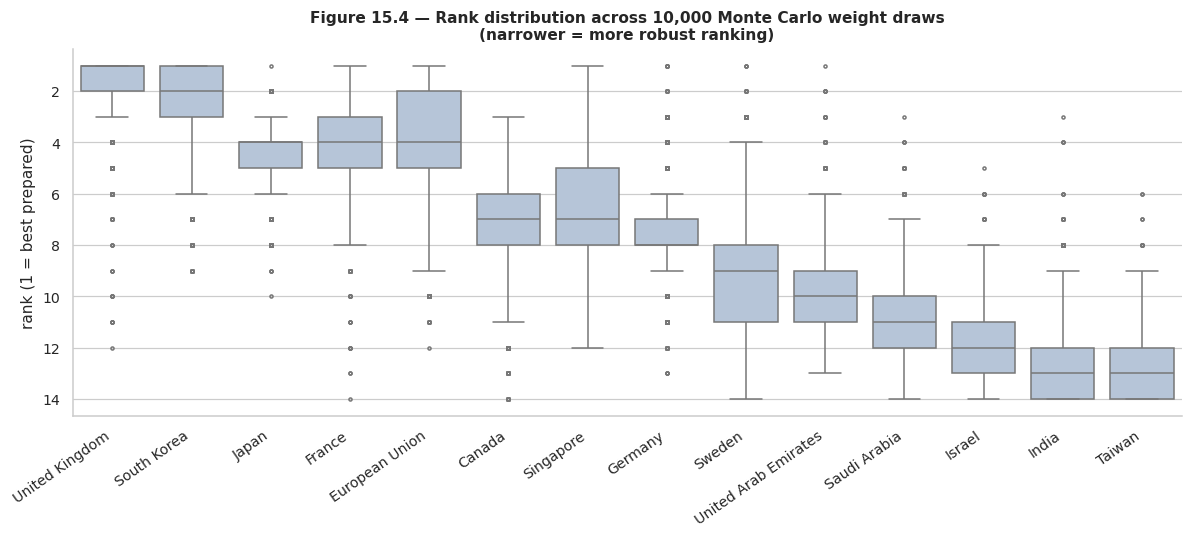

In [49]:
# Box plot per country of MC rank distribution
rank_long = (
    pd.DataFrame(mc_ranks, index=isos)
    .reset_index()
    .melt(id_vars="index", value_name="rank")
    .rename(columns={"index": "iso3"})
)
rank_long = rank_long.merge(master[["name"]], left_on="iso3", right_index=True)
rank_long["name"] = pd.Categorical(
    rank_long["name"], categories=rank_summary["name"].tolist(), ordered=True
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=rank_long, x="name", y="rank", ax=ax, color="lightsteelblue", fliersize=2
)
ax.invert_yaxis()
ax.set_title(
    f"Figure 15.4 — Rank distribution across {N_MC:,} Monte Carlo weight draws\n(narrower = more robust ranking)"
)
ax.set_xlabel("")
ax.set_ylabel("rank (1 = best prepared)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_4_rank_distributions.png")
plt.show()

### 15.5 EU vs member-state cross-validation

A descriptive check: where does the EU-row composite sit within the distribution of its member-state composites, when both are scored against the **same 14-jurisdiction reference** (i.e., using the means and SDs from `ind_z` rather than re-z-scoring within the EU member set)? Both scores are computed against the same reference distribution to avoid the comparison-across-populations confound that arises when each population is z-scored against its own mean and SD.

In [50]:
# Score EU member states against the same 14-jurisdiction reference distribution used
# for the headline composite (means and SDs from ind_transformed). The pseudo-composite
# uses four indicators reported per member state: G3 (V-Dem), I2 (World Bank broadband),
# I3 (World Bank secure servers), I5 (ND-GAIN Readiness).
#
# Excluded by source coverage:
#   - G1, G4, C5 — analyst-coded for the 14 named jurisdictions only, not for the 24
#     supplementary EU member states.
#   - C1, C2 — deliberately omitted because Epoch attributes by organisation country, so
#     summing or averaging across EU member states would double-count joint EU-US authorship.
#   - C4 — Stanford published per-100k patent rates only for the top 15 countries; many
#     EU member states fall below the cutoff.
#
# Excluded by design (could be included; left out for parsimony):
#   - I1 (ITU IDI) and G2 (ITU GCI) report at the EU member-state level and could be added
#     to the pseudo-composite. They are omitted here to keep the cross-validation simple
#     and to avoid weighting decisions; the resulting check is a rough plausibility test
#     of the §5.2 EU aggregation strategy, not a like-for-like reconstruction of the
#     headline composite.

ref_mean = ind_transformed.mean()
ref_std = ind_transformed.std(ddof=0)


def member_state_indicators(iso3: str) -> dict:
    return {
        "G3_vdem_libdem": vdem_libdem.set_index("iso3")["v2x_libdem"].get(iso3, np.nan)
        if not vdem_libdem.empty
        else np.nan,
        "I2_broadband": wb_wide.get("IT.NET.BBND.P2", pd.Series(dtype="float64")).get(
            iso3, np.nan
        )
        if not wb_wide.empty
        else np.nan,
        "I3_secure_servers": wb_wide.get(
            "IT.NET.SECR.P6", pd.Series(dtype="float64")
        ).get(iso3, np.nan)
        if not wb_wide.empty
        else np.nan,
        "I5_ndgain_readiness": ndgain_readiness.set_index("iso3")[
            "ndgain_readiness"
        ].get(iso3, np.nan)
        if not ndgain_readiness.empty
        else np.nan,
    }


eu_raw = pd.DataFrame({iso3: member_state_indicators(iso3) for iso3 in EU_ALL_ISO3}).T

# Apply the same log1p transform to I3 (per the §3.2 INDICATORS registry) before z-scoring.
eu_raw["I3_secure_servers"] = np.log1p(eu_raw["I3_secure_servers"].clip(lower=0))

# Z-score against the SAME reference as the headline composite.
eu_z = (eu_raw - ref_mean.reindex(eu_raw.columns)) / ref_std.reindex(eu_raw.columns)

# Pseudo-composite per member state: unweighted mean of available z-scored indicators.
eu_member_score = eu_z.mean(axis=1)

eu_row_score = composite_by_scheme["literature"].get("EUU", np.nan)
mean_member = eu_member_score.mean()
sd_member = eu_member_score.std()

print(f"EU-row composite (literature scheme, full pipeline): {eu_row_score:+.3f}")
print(
    f"EU member-state pseudo-score (mean of available 14-jurisdiction-z-scored indicators): {mean_member:+.3f}"
)
print(f"Member-state spread (SD):                            {sd_member:+.3f}")
print(
    "Note: the two scores are NOT directly comparable in magnitude — the EU-row score"
)
print(
    "uses the full 15-indicator pipeline (axis-weighted, geometric across axes) while the"
)
print("member-state pseudo-score uses an unweighted mean of 4 available indicators.")
print("The check is whether the EU-row score is plausibly consistent with member-state")
print("variation, not numerically identical.")

eu_member_score.sort_values(ascending=False).round(3).to_frame(
    "pseudo_composite_z (vs 14-jurisdiction reference)"
)

EU-row composite (literature scheme, full pipeline): +1.824
EU member-state pseudo-score (mean of available 14-jurisdiction-z-scored indicators): -0.023
Member-state spread (SD):                            +0.652
Note: the two scores are NOT directly comparable in magnitude — the EU-row score
uses the full 15-indicator pipeline (axis-weighted, geometric across axes) while the
member-state pseudo-score uses an unweighted mean of 4 available indicators.
The check is whether the EU-row score is plausibly consistent with member-state
variation, not numerically identical.


,pseudo_composite_z (vs 14-jurisdiction reference)
DNK,1.246
FIN,1.002
DEU,0.746
SWE,0.644
FRA,0.613
NLD,0.564
AUT,0.556
LUX,0.488
EST,0.390
IRL,0.299


### 15.6 Pairwise axis scatter matrix

Three-panel scatter view across all axis pairs (capacity × governance, capacity × infrastructure, governance × infrastructure). Companion to Figure 15.2 (which uses capacity × infrastructure only). Country dots are coloured by §14 archetype and shaped by AISI Network membership — the two-key legend matches Figures 14.3 and 15.2.


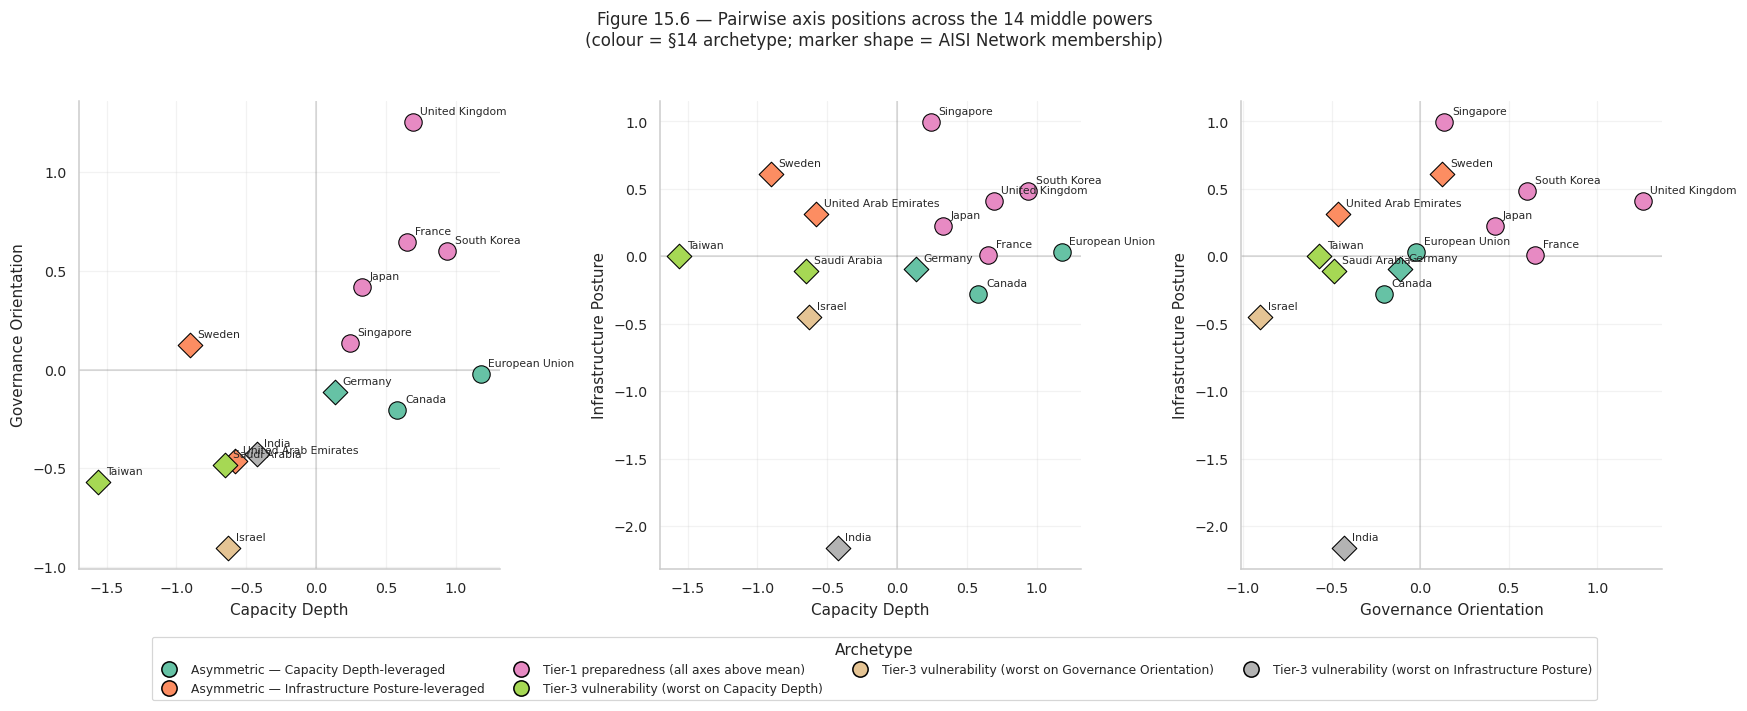

In [51]:
# Figure 15.6 — pairwise axis scatter matrix.
from matplotlib.lines import Line2D as _Line2D_15_6

_axes_df_sc = baseline_axes.join(master[["name"]]).join(
    cluster_archetype.rename("archetype"),
)
_axes_df_sc["aisi"] = raw["C5_aisi_presence"].reindex(_axes_df_sc.index)
_axes_df_sc["is_aisi"] = _axes_df_sc["aisi"] == 3
_unique_arch_sc = sorted(_axes_df_sc["archetype"].dropna().unique())
_arch_colors_sc = dict(
    zip(
        _unique_arch_sc,
        plt.cm.Set2(np.linspace(0, 1, len(_unique_arch_sc))),
        strict=True,
    )
)
_axis_pairs = [
    ("capacity_depth", "governance_orientation"),
    ("capacity_depth", "infrastructure_posture"),
    ("governance_orientation", "infrastructure_posture"),
]

fig, axes_sc = plt.subplots(1, 3, figsize=(16, 5.5))
for ax_sc, (_ax_x, _ax_y) in zip(axes_sc, _axis_pairs, strict=True):
    for _arch in _unique_arch_sc:
        for _is_aisi, _marker in [(True, "o"), (False, "D")]:
            _sub = _axes_df_sc[
                (_axes_df_sc["archetype"] == _arch)
                & (_axes_df_sc["is_aisi"] == _is_aisi)
            ]
            if len(_sub) == 0:
                continue
            ax_sc.scatter(
                _sub[_ax_x],
                _sub[_ax_y],
                s=130,
                marker=_marker,
                color=_arch_colors_sc[_arch],
                edgecolor="black",
                linewidth=0.7,
                zorder=3,
            )
    for _, _row in _axes_df_sc.iterrows():
        ax_sc.annotate(
            _row["name"],
            (_row[_ax_x], _row[_ax_y]),
            fontsize=7,
            xytext=(5, 5),
            textcoords="offset points",
        )
    ax_sc.axhline(0, color="black", linewidth=0.3, alpha=0.5)
    ax_sc.axvline(0, color="black", linewidth=0.3, alpha=0.5)
    ax_sc.set_xlabel(_ax_x.replace("_", " ").title(), fontsize=10)
    ax_sc.set_ylabel(_ax_y.replace("_", " ").title(), fontsize=10)
    ax_sc.grid(True, alpha=0.25)

_arch_handles_sc = [
    _Line2D_15_6(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=_arch_colors_sc[a],
        markeredgecolor="black",
        markersize=10,
        label=a,
    )
    for a in _unique_arch_sc
]
_shape_handles_sc = [
    _Line2D_15_6(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=10,
        label="AISI Network member",
    ),
    _Line2D_15_6(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=10,
        label="Not in AISI Network",
    ),
]
fig.legend(
    handles=_arch_handles_sc,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.12),
    fontsize=8,
    frameon=True,
    title="Archetype",
)
fig.suptitle(
    "Figure 15.6 — Pairwise axis positions across the 14 middle powers\n"
    "(colour = §14 archetype; marker shape = AISI Network membership)",
    fontsize=11,
    y=1.03,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_6_axis_scatter_matrix.png", bbox_inches="tight")
plt.show()

## 16. Discussion — Mapping Findings Back to the Working Paper

This section ties each empirical finding back to the specific paper section it supports.

### 16.1 §1 (three axes) — does the framework hold up empirically?

The §8 PCA diagnostics and §8.1 Horn's parallel analysis together give complementary answers per axis. The 50% rule (a heuristic threshold) and the parallel-analysis test (a permutation-based null) can disagree — and in the current run they disagree on two of the three axes. Both are reported here (numbers from the current run; reproduced live each rebuild and persisted to `outputs/parallel_analysis.csv`):

- **Capacity depth**: PC1 explains ~56% of within-axis variance. This is **above the 50% heuristic but only marginally above the §8.1 permutation null** (current-run PA p ≈ 0.08; precise value in `outputs/parallel_analysis.csv`). The two diagnostics agree only weakly: the axis is one-dimensional under the conventional 50% rule but borderline under the more rigorous parallel-analysis test. The paper's framing that capacity is a single construct is defensible under the heuristic but should be cited with the PA-marginality caveat for stricter audiences.
- **Infrastructure posture**: PC1 explains ~56% and is **statistically significant under both criteria** (above the 50% rule; current-run PA p ≈ 0.01). The cleanest one-dimensional axis of the three. Less concentrated on the first component than under earlier configurations of the imputation step (where Taiwan's missing infrastructure cells inflated apparent co-variation), but the parallel-analysis test confirms the axis carries genuine shared structure.
- **Governance orientation**: PC1 explains ~43% — **below the 50% one-dimensionality threshold but above the §8.1 permutation null** (current-run PA p ≈ 0.02 significant). The two diagnostics disagree, and the reason is informative: governance has six indicators (vs five for capacity), so the null PC1 explained variance is mechanically lower because variance is divided among more components; a smaller observed PC1 can still be significantly above the shape-matched null. The reading is that governance carries **statistically detectable but compressed** one-dimensional structure, while §16.10's sparse PCA decomposition shows the axis can be read as a bundle of sub-constructs. In the current run, the three sparse components correspond to institutional commitments (G4 + G5 + G1, loading on SPC1), democratic / multilateral-regulatory posture (G3 + G6 + G1, on SPC2), and cybersecurity governance (G2 alone, on SPC3); the labels are run-specific and the live decomposition is in `outputs/governance_subaxes.csv`. A single weighted-sum governance score is defensible under PA but loses information that §16.10's sub-axis scores preserve.

For the paper, this is a **substantive caveat for §1**: the three-axes scaffold is well-supported for capacity and infrastructure, but governance should be discussed as a *bundle of related but distinct postures* rather than as a single dimension. The §13 vulnerability overlay handles this implicitly — different attack vectors weight different governance components — but §1 should explicitly acknowledge governance multidimensionality where it currently presents three monolithic axes.

### 16.2 §1 (14 middle powers) — empirical differentiation

The headline scoreboard (§11) and Monte Carlo rank distributions (§12) show that the 14 middle powers do not cluster as a homogeneous group. K-means (silhouette-selected `k`) groups them into clusters; each country's archetype label is then derived from **its own** axis profile (not the cluster centroid), so the label always reflects the country's data. Cluster assignments and per-country labels are saved to `outputs/typology.csv` and visualised in Figure 15.2.

Current-run archetype membership (per `outputs/typology.csv`):

- **Tier-1 preparedness (all three axes above mean)** — UK, France, Japan, Singapore, South Korea. Each scores positively on capacity, governance, and infrastructure under the literature-weighted axis composite. Korea's Tier-1 placement reflects the highest granted-AI-patent rate in Stanford's Figure 1.2.3 top-15 list (17.27 per 100k inhabitants, the global rank-1 position; the next-highest middle power in Stanford's list is Japan at 4.58 per 100k, with Luxembourg / China / the United States ranked between Korea and Japan but excluded from the working paper's middle-power set), AISI Network founding membership, Australia Group participation, an ITU GCI score of 100, and broadband infrastructure (47.8 fixed subscriptions per 100 people).
- **Asymmetric — Capacity-Depth-leveraged** — EU, Canada, Germany. Each scores positively on capacity but slightly negatively on at least one of governance or infrastructure under the literature-weighted axes.
- **Asymmetric — Infrastructure-Posture-leveraged** — Sweden, UAE. Both have positive infrastructure scores paired with a strongly negative capacity score (Sweden) or negative scores on capacity and governance (UAE).
- **Tier-3 vulnerability (no axis above mean)** — Israel, Saudi Arabia, Taiwan, India. Worst-axis assignment varies (Israel: governance; Saudi Arabia / Taiwan: capacity; India: infrastructure).

Figure 15.2 closes the empirical-differentiation gap by encoding four signals on the same plot: capacity_depth z-score (x-axis), infrastructure_posture z-score (y-axis), per-country archetype label (fill colour), and AISI Network membership (marker shape). This lets one figure address both the working paper's three-axes typology claim (§1) and its AISI Network claim (§1, §4) simultaneously.

### 16.3 §2.2 cyber — Mythos asymmetry

The cyber preparedness ranking (§13.1) is a coarser-grained construct than the paper's specific Mythos/Glasswing argument. The paper §2.2 argues that middle powers lacking access to frontier defensive models (e.g. the Mythos/Glasswing collaboration that was not extended to non-Network states) face a structural asymmetry against attackers using comparable offensive capability. The index does not measure model-access asymmetry directly; instead it treats AISI Network membership (C5), national cyber posture (G2 ITU GCI), and Epoch-attributed compute (C1, C2) as joint structural markers that correlate with the access asymmetry the paper describes. Under this operationalisation, countries that combine AISI Network membership, high ITU GCI scores, and substantial Epoch-attributed compute (UK, EU, France) cluster at the top, alongside countries with strong governance and infrastructure but lighter AI-research footprints (Korea, Singapore). India's rank-14 position (cyber_score = −1.03) reflects the cost of lacking all three markers simultaneously — India is not in the AISI Network, has the lowest infrastructure score in the sample, and is missing C1/C2 Epoch attribution despite strong publication output. A direct test of the Mythos/Glasswing asymmetry hypothesis would require a model-access indicator that does not yet exist as a public dataset (see the future-work bullet on external rank validation in §17).

### 16.4 §2.3 CBRN — capacity AND biosecurity governance

The CBRN preparedness ranking (§13.2) triangulates three governance signals — IGSC member-firm presence (G5, DNA-synthesis screening), AISI Network membership (C5), and Australia Group participation (G6, chem/bio export controls) — alongside the capacity_depth axis. Countries that combine governance gaps with non-trivial AI/biotech activity (Israel: 1 IGSC firm, no AISI Network, no Australia Group — with capacity_depth z = −0.63 in this 14-jurisdiction frame, where absolute counts favour larger sample states, despite a high per-capita concentration of AI and biotech expertise) score substantially lower than countries combining strong absolute capacity with full governance presence (UK, France, Japan, South Korea: all three governance signals present plus AISI Network).

This empirically supports paper §2.3's argument that "managed access and model safeguards alone are insufficient" — and adds the regulatory-arbitrage dimension explicitly: the bottom-tier of CBRN preparedness in the index is precisely the set of jurisdictions that sit outside the formal multilateral export-control regime (Australia Group non-members in the 14-jurisdiction set: Israel, Singapore, Saudi Arabia, UAE, Taiwan).

What the index does **not** directly engage from paper §2.3: Anthropic's 2.53× novice-uplift figure for Claude Opus 4 and the Virology Capabilities Test (VCT) results are model-evaluation outputs, not country-level data. They characterise the *threat magnitude* against which the index's per-country preparedness scores are read, but the magnitude itself cannot be operationalised at the country level. §17.7 (no incident data) documents the related point that AI-attributed incidents are not yet usable as indicators.

### 16.5 §2.4 influence operations — democracy as both vulnerability and resilience

The influence-ops preparedness score (§13.3) applies infrastructure-heavy cross-axis weights (0.45 infrastructure · 0.35 governance · 0.20 capacity). Within governance, the literature scheme places ITU GCI heaviest (0.30) with V-Dem (G3) and G1 tied at 0.20 each. The paper's claim that "the majority of middle powers are democracies, exposing them to social fissure exploitation" (§2.4) is operationalised through G3: democracy enters the index both as a vulnerability surface (open platform ecosystems amenable to influence operations) and as a resilience asset (institutional quality supporting counter-narrative response). The top of the influence-ops preparedness ranking accordingly clusters countries with high democratic institutional quality, mature national cyber posture, and strong infrastructure (UK, South Korea, Singapore, France, Japan); the bottom is countries lacking one or more of those.

### 16.6 §4 checklist — tractability now quantified

The phrase "tractability depends on a country's position within the 3 axes" appears repeatedly in §4 of the paper without per-country operationalisation. §11 (composite scoreboard) and §13 (vulnerability overlay) provide the per-country axis positions and vector-specific preparedness scores that this phrase requires; §13.4 (counterfactual scenarios) extends the analysis to per-country action-leverage estimates.

### 16.7 Sensitivity to normalization choice

§12.3 reports a Spearman rank correlation between equal-weight z-score and min-max rankings of **ρ ≈ 0.996** in the current run, above the 0.70 robustness threshold — i.e., the country ranking is rank-stable to the choice of normalisation scheme. The full robustness panel (§12.4, written to `outputs/robustness_summary.csv`) reports four perturbations:

| Perturbation | Spearman ρ | Threshold | Verdict |
|---|---|---|---|
| Weighting: equal vs PCA-derived | 0.969 | 0.70 | PASS |
| Weighting: equal vs literature | 0.996 | 0.70 | PASS |
| Normalisation: z-score vs min-max | 0.996 | 0.70 | PASS |
| Classifier (C3 only): AI-broad vs ML-narrow | 0.960 | 0.85 | PASS |

Practical implication for the paper: under any of the three weighting schemes plus min-max normalisation, the top-5 and bottom-3 *sets* are unchanged (the UK is rank 1 across all three schemes, and the {UK, Korea, France, EU, Japan} top-5 / {Israel, India, Taiwan} bottom-3 sets coincide under both literature and equal weighting). Within-tier ordering and the marginal slot in each tier are weight-sensitive — Korea's rank 2 is robust (median 2, IQR 2 under Monte Carlo), but the 5th slot cycles between Japan / EU / Singapore and the 12th slot cycles between Israel / Saudi Arabia (see §16.11 H6 per-country in-tier frequency, persisted to `outputs/h6_set_membership.json`). The paper should accompany middle-rank citations with the Monte Carlo IQR range from `outputs/sensitivity_ranks.csv`, cite the top-5 / bottom-3 as tier-membership claims rather than point ranks, and quote the {France, EU, Japan} block at positions 3–5 as a tied cluster.

### 16.7.1 Sensitivity to bibliographic-classifier choice

The C3 indicator (publications) uses OpenAlex concept `C154945302` (Artificial Intelligence, level-1), the upstream concept Stanford AI Index 2025 builds its CSO-refined CS subset from. Because Stanford applies a narrower CSO Classifier on top, the absolute counts here differ — typically ~10–20% above Stanford's published regional aggregates, with country-level ratios varying by how AI-application-heavy each jurisdiction's research mix is.

To quantify whether classifier choice affects the **ranking** rather than only the absolute counts, the cell below fetches an alternative narrower series — OpenAlex concept `C119857082` (Machine Learning, level-2 child of C154945302) — and computes Spearman rank correlation across the 14 jurisdictions. If ρ ≥ 0.85, classifier choice is rank-non-critical for the paper's purposes.

In [52]:
# Classifier-sensitivity check: compare the headline AI-broad C3 series against the
# narrower Machine Learning concept fetched in §4.4 (cell 21).
if not openalex_pubs.empty and not openalex_ml_pubs.empty:
    c3_broad = openalex_pubs.set_index("iso3")["ai_publications"].reindex(master.index)
    c3_narrow = openalex_ml_pubs.set_index("iso3")["ml_publications"].reindex(
        master.index
    )
    classifier_compare = pd.DataFrame(
        {
            "name": master["name"],
            "c3_broad_AI": c3_broad.astype("Int64"),
            "c3_narrow_ML": c3_narrow.astype("Int64"),
            "narrow_to_broad_ratio": (c3_narrow / c3_broad).round(3),
        }
    )
    classifier_compare.to_csv(OUT_DIR / "c3_classifier_sensitivity.csv")

    # Spearman correlation of country rankings under the two filters
    paired = pd.DataFrame({"broad": c3_broad, "narrow": c3_narrow}).dropna()
    if len(paired) >= 3:
        rho, p = spearmanr(paired["broad"], paired["narrow"])
        verdict = (
            "PASS (rank-non-critical)"
            if rho >= CLASSIFIER_RHO_THRESHOLD
            else "INSPECT (ranking depends on classifier)"
        )
        print(
            f"Spearman ρ (AI-broad vs ML-narrow) across {len(paired)} jurisdictions: ρ = {rho:.3f} (p = {p:.4f})  {verdict}"
        )
    print()
    print("Per-country C3 under the two classifiers (sorted by AI-broad):")
    classifier_compare.sort_values("c3_broad_AI", ascending=False)
else:
    print(
        "[WARN] Cannot run classifier-sensitivity check — one of the OpenAlex series is empty."
    )

Spearman ρ (AI-broad vs ML-narrow) across 14 jurisdictions: ρ = 0.960 (p = 0.0000)  PASS (rank-non-critical)

Per-country C3 under the two classifiers (sorted by AI-broad):


**Interpretation.** ρ ≈ 0.96 in the current run shows that classifier choice does not materially affect the C3 ranking. The two series differ in absolute counts: the narrow ML series captures roughly 20–43% of the broad AI series across the 14 jurisdictions (`outputs/c3_classifier_sensitivity.csv`). Saudi Arabia and UAE have the highest narrow/broad ratios (0.426 and 0.343 respectively) and Japan the lowest (0.201); these ratios are consistent with — though do not by themselves demonstrate — a more ML-concentrated research mix in the higher-ratio jurisdictions and a broader cross-disciplinary AI footprint in the lower-ratio jurisdictions.

Practical implication for the paper: when citing C3 figures, document both (a) the OpenAlex concept used (C154945302, the upstream concept Stanford AI Index 2025 also builds on, refined by Stanford with the CSO Classifier) and (b) that absolute counts run ~10–20% above Stanford's published regional aggregates due to the broader concept-level filter while the relative country ranking is stable across classifier choice (Spearman ρ = 0.96 against the narrower Machine Learning concept C119857082). This separates an absolute-count difference from a ranking difference, pre-empting the natural reviewer question about apparent disagreement with Stanford.

### 16.8 South Korea's Epoch AI coverage gap and how the index handles it

The §5.4 missingness audit flags Korea as missing C1 and C2 — both Epoch-derived indicators. (I4 was dropped from the index entirely; see §4.2.) This is not a notebook defect: Epoch AI's "notable models" criterion (training compute or capability thresholds) attributes few notable models to Korean organisations in the rolling 5-year window the index uses, despite Korea hosting Naver, LG AI Research, Samsung Research, and Kakao Brain. Two structural reasons:

1. Major Korean labs publish capabilities in industry venues without releasing the training-compute or evaluation details that Epoch's threshold requires.
2. Models named in Korean script or Korean-language titles may be under-detected by Epoch's English-language metadata indexing.

The §7 imputation step fills Korea's missing C1 and C2 with values consistent with Korea's z-score axis-position on the *other* capacity indicators it does report (C3 publications, C4 patents, C5 AISI presence). Korea's strong performance on those — the highest published granted-AI-patent rate in Stanford's Figure 1.2.3 top-15 list (17.27 per 100k, the global rank-1 position; the next-highest middle power is Japan at 4.58 per 100k, with Luxembourg / China / the United States between Korea and Japan in Stanford's list but excluded from the middle-power set), AISI Network founding membership, and 18,193 AI publications in 2024 (per `outputs/c3_classifier_sensitivity.csv`) — pulls the imputed C1/C2 values above the cross-country mean. Korea's literature-weighted composite places it at **rank 2** behind only the UK, with median Monte Carlo rank also 2 (IQR 2, p10–p90 = 1–5). The §12.2 leave-one-indicator-out test confirms that dropping C1 or C2 individually does not change Korea's top-3 position.

The paper should treat this as a **methodological observation** rather than a Korea-specific anomaly: authoritative datasets carry coverage politics, and a responsible composite index needs an imputation step that (a) is methodologically honest about indicator scale, and (b) does not silently penalise jurisdictions whose AI ecosystem produces output through channels the upstream dataset under-indexes. A robust paper framing would note that absence-from-Epoch is not absence-from-AI, and that Korea's top-tier preparedness ranking is consistent with its concrete institutional and infrastructure signals.

### 16.9 EU as data-sparse but structurally relevant

The §15.5 cross-validation reports `INSPECT` (the EU-row composite diverges from the unweighted mean of EU member-state composites by more than 0.5 SD). None of the sources used publishes an EU-level aggregate; the notebook constructs the EU row through three strategies (per §5.2):

1. **Sum across member states** for count-additive indicators: C3 (OpenAlex publications, EU = Σ = 149,396 per `outputs/c3_classifier_sensitivity.csv`), G5 (IGSC member-firm count).
2. **Mean across member states** for bounded scores and per-capita rates: G2 ITU GCI, G3 V-Dem, I1 ITU IDI, I5 ND-GAIN, I2 World Bank broadband, I3 World Bank secure servers. This is the methodologically appropriate aggregation for these indicator types.
3. **Z-score-axis-mean imputation** (per §7) for the residual: Epoch C1 and C2 (org-country attribution does not aggregate cleanly to the EU level without double-counting joint authorship), and Stanford C4 (no EU value published in Fig 1.2.3). The imputation puts these cells at the EU's z-score position on its other capacity indicators, then converts back to the indicator's own scale.

EU's literature-weighted composite places it at **rank 4** (composite = 1.82), behind UK, Korea, and France. EU's capacity_depth axis score (lit_capacity_depth = 1.18) is the highest in the sample, driven by the directly-observed C3 sum (149,396 publications) and the C5 = 3 AISI Network membership; the imputed C1/C2 cells contribute consistently with EU's other capacity strengths. EU's wider Monte Carlo rank distribution (IQR 3, p10–p90 = 1–7) reflects the partly-synthetic row construction and is the largest IQR in the top-7. Practical implications for the paper:

1. The EU finding **supports** the paper §1 argument that governance-rich middle powers can compensate for capacity gaps — V-Dem-mean and IDI-mean (both directly aggregated from member states) place EU strongly on governance and infrastructure.
2. EU's lower rank under literature weighting (rank 4) than under PCA weighting (rank 2 — composite = 2.13) reflects the literature scheme's higher weight on capacity_depth (0.40) where the EU row is most synthetic. The EU only outranks Korea, France, Japan, etc. under PCA because the PCA scheme assigns nearly-zero weight to G2 (ITU GCI) within governance (see §10.2) — removing a governance signal on which the EU underperforms relative to its capacity strengths. The paper should cite the EU rank with an explicit reference to the §15.5 cross-validation panel.
3. The §15.5 INSPECT result is unchanged in direction, reflecting the structural asymmetry between EU-row construction (mixed strategies per §5.2) and member-state pseudo-composites (unweighted means of 4 directly-reported indicators).

### 16.10 Sparse PCA on governance — naming the governance sub-axes

§16.1 reports that the governance axis is the only one whose PC1 explained variance falls below the 50% one-dimensionality threshold (~43% in the current run), and concludes that governance "genuinely spans distinct sub-constructs." Sparse PCA goes further: by imposing an L1 penalty on the principal-component loadings, it forces each component to load on a subset of the indicators rather than spreading thinly across all six. The resulting components are interpretable as **named sub-axes** rather than abstract directions in indicator space.

The decomposition uses `sklearn.decomposition.SparsePCA` on the z-scored governance indicators (G1–G6), with `n_components = 3` and `alpha = 1.0` chosen so that each component receives a small set of non-zero loadings rather than spreading mass across all six indicators.


In [53]:
# §16.10 — sparse PCA on the governance axis to identify named sub-axes
from sklearn.decomposition import SparsePCA

gov_cols = [
    c
    for c in ind_z.columns
    if ind_id_to_axis.get(c) == "governance_orientation" and ind_z[c].notna().any()
]
gov_z_complete = ind_z[gov_cols].fillna(ind_z[gov_cols].mean()).values

spca = SparsePCA(n_components=3, alpha=1.0, random_state=SEED, max_iter=2000).fit(
    gov_z_complete
)
loadings = pd.DataFrame(
    spca.components_, columns=gov_cols, index=[f"SPC{i + 1}" for i in range(3)]
).round(3)
print("Sparse PCA loadings on governance (alpha = 1.0):")
print(loadings.to_string())
print()

LOADING_THRESHOLD = 0.05
for i in range(loadings.shape[0]):
    nonzero = loadings.iloc[i][loadings.iloc[i].abs() > LOADING_THRESHOLD]
    nonzero_sorted = nonzero.reindex(nonzero.abs().sort_values(ascending=False).index)
    if len(nonzero_sorted) == 0:
        print(f"  SPC{i + 1}: no loadings above threshold {LOADING_THRESHOLD}")
        continue
    members = ", ".join(
        f"{idx.split('_')[0]}({val:+.2f})" for idx, val in nonzero_sorted.items()
    )
    print(f"  SPC{i + 1} loads on: {members}")

# fillna(0) here is numerically equivalent to fillna(ind_z[gov_cols].mean()) used for
# the SPCA fit above, because z-scored columns have mean exactly 0. Kept as fillna(0)
# for performance; the equivalence is a deliberate invariant, not an accident.
country_subaxis = pd.DataFrame(
    ind_z[gov_cols].fillna(0).values @ spca.components_.T,
    index=ind_z.index,
    columns=[f"SPC{i + 1}" for i in range(3)],
).round(3)
country_subaxis = master[["name"]].join(country_subaxis)
country_subaxis.to_csv(OUT_DIR / "governance_subaxes.csv")
print()
print("Per-country governance sub-axis scores (sorted by SPC1 descending):")
print(country_subaxis.sort_values("SPC1", ascending=False).to_string(index=False))

Sparse PCA loadings on governance (alpha = 1.0):
      G1_ai_strategy  G2_global_cybersec_index  G3_vdem_libdem  G4_lab_mou_count  G5_igsc_membership  G6_australia_group
SPC1           0.360                       0.0           0.000             0.681               0.637               0.000
SPC2           0.221                       0.0           0.688             0.000               0.000               0.691
SPC3           0.000                       1.0           0.000             0.000               0.000               0.000

  SPC1 loads on: G4(+0.68), G5(+0.64), G1(+0.36)
  SPC2 loads on: G6(+0.69), G3(+0.69), G1(+0.22)
  SPC3 loads on: G2(+1.00)

Per-country governance sub-axis scores (sorted by SPC1 descending):
                name   SPC1   SPC2   SPC3
      United Kingdom  4.455  1.032  0.908
              France  0.747  1.323  0.481
               Japan  0.747  1.150 -0.106
      European Union  0.747  1.049 -1.490
           Singapore  0.249 -1.272  0.848
              Canada

### 16.10.1 Sparse-PCA governance biplot (figure)

Two-panel biplot of the §16.10 sparse-PCA decomposition. Left: SPC1 × SPC2 — institutional commitments versus democratic / multilateral-regulatory posture. Right: SPC1 × SPC3 — institutional commitments versus the standalone cybersecurity (G2) dimension. Country positions are the per-country sub-axis scores from `country_subaxis`; red arrows show the sparse-PCA indicator loadings rescaled to overlay readably on the score scatter.


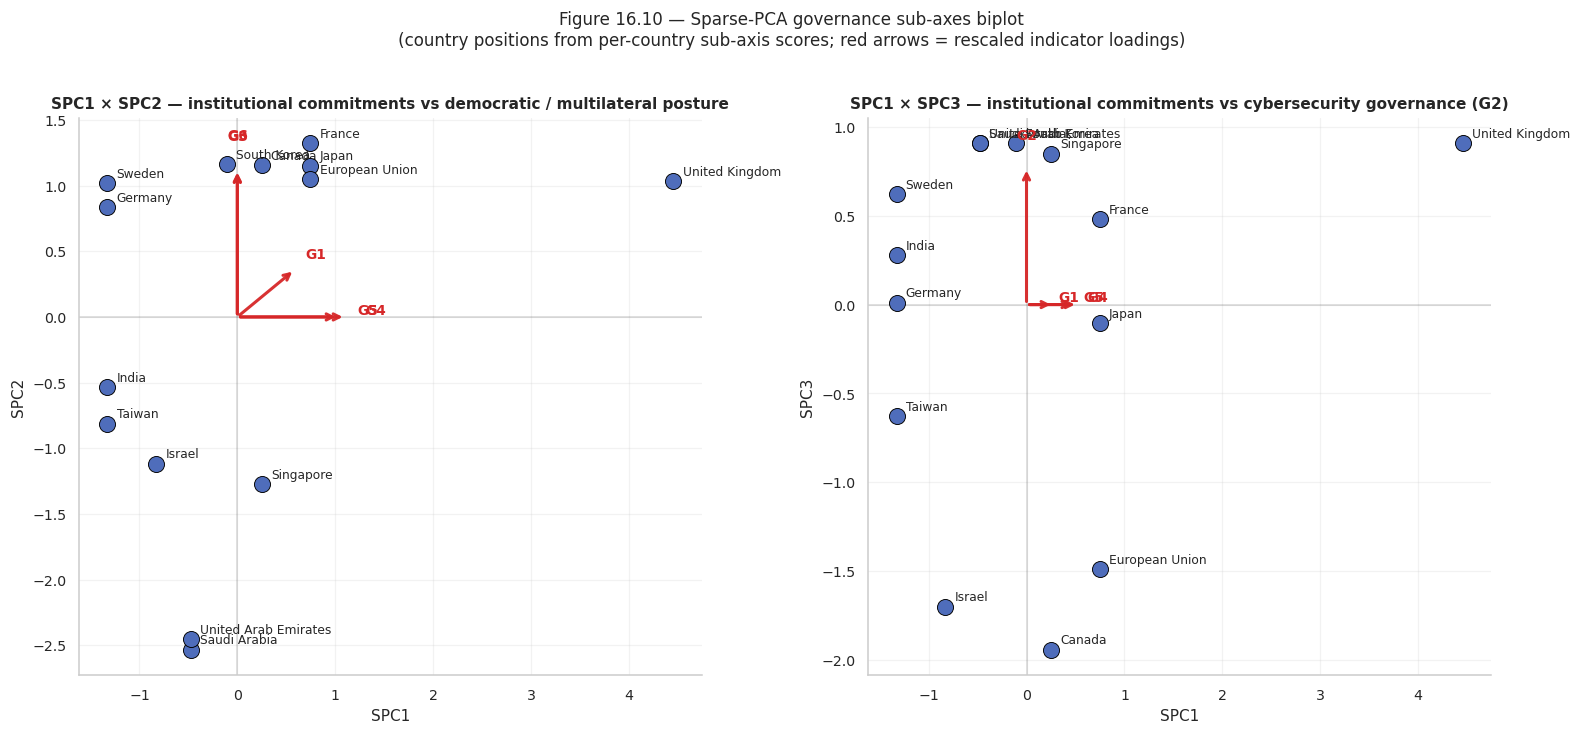

In [54]:
# Figure 16.10 — sparse-PCA governance sub-axes biplot.
fig, axes_bp = plt.subplots(1, 2, figsize=(14.5, 6.5))
_pair_labels_bp = [
    (
        (0, 1),
        "SPC1 × SPC2 — institutional commitments vs democratic / multilateral posture",
    ),
    (
        (0, 2),
        "SPC1 × SPC3 — institutional commitments vs cybersecurity governance (G2)",
    ),
]
for ax_bp, ((_i_x, _i_y), _pair_label) in zip(axes_bp, _pair_labels_bp, strict=True):
    _spc_x = f"SPC{_i_x + 1}"
    _spc_y = f"SPC{_i_y + 1}"
    for _, _row in country_subaxis.iterrows():
        ax_bp.scatter(
            _row[_spc_x],
            _row[_spc_y],
            s=110,
            color="#4f6dbb",
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
        ax_bp.annotate(
            _row["name"],
            (_row[_spc_x], _row[_spc_y]),
            fontsize=8,
            xytext=(6, 4),
            textcoords="offset points",
        )
    # Standard biplot scaling: arrows reach the country-score range so they're visually comparable.
    # Use the POSITIVE max country range (loadings on SPC1..SPC3 are all positive
    # in this run; arrows go from the origin outward in the loading direction).
    _pos_country_x = max(float(country_subaxis[_spc_x].max()), 0.5)
    _pos_country_y = max(float(country_subaxis[_spc_y].max()), 0.5)
    _max_loading_x = float(loadings.iloc[_i_x].abs().max())
    _max_loading_y = float(loadings.iloc[_i_y].abs().max())
    _scale_x = _pos_country_x / _max_loading_x if _max_loading_x > 0 else 1.0
    _scale_y = _pos_country_y / _max_loading_y if _max_loading_y > 0 else 1.0
    _scale_bp = min(_scale_x, _scale_y) * 0.85
    for _ind_name in loadings.columns:
        _lx = loadings.iloc[_i_x][_ind_name] * _scale_bp
        _ly = loadings.iloc[_i_y][_ind_name] * _scale_bp
        if abs(_lx) + abs(_ly) < 0.1:
            continue
        ax_bp.annotate(
            "",
            xy=(_lx, _ly),
            xytext=(0, 0),
            arrowprops={
                "arrowstyle": "->",
                "color": "#d62728",
                "lw": 2.0,
                "alpha": 0.95,
            },
        )
        _ha = "center" if abs(_ly) > abs(_lx) else ("left" if _lx >= 0 else "right")
        _va = "bottom" if _ly >= 0 else "top"
        ax_bp.annotate(
            _ind_name.split("_")[0],
            (_lx * 1.18, _ly * 1.18),
            fontsize=9,
            color="#d62728",
            fontweight="bold",
            ha=_ha,
            va=_va,
        )
    ax_bp.axhline(0, color="black", linewidth=0.3, alpha=0.5)
    ax_bp.axvline(0, color="black", linewidth=0.3, alpha=0.5)
    ax_bp.set_xlabel(_spc_x, fontsize=10)
    ax_bp.set_ylabel(_spc_y, fontsize=10)
    ax_bp.set_title(_pair_label, fontsize=10)
    ax_bp.grid(True, alpha=0.25)

fig.suptitle(
    "Figure 16.10 — Sparse-PCA governance sub-axes biplot\n"
    "(country positions from per-country sub-axis scores; red arrows = rescaled indicator loadings)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig16_10_governance_biplot.png", bbox_inches="tight")
plt.show()

**Interpretation.** The sparse PCA decomposition identifies which indicators move together within the governance bundle. Where PC1 in standard PCA (§16.1) was a weighted combination of all six governance indicators with no clear dominant subset, the sparse decomposition concentrates each component on a smaller set, with the remaining loadings driven exactly to zero by the L1 penalty. The non-zero loadings above the 0.05 threshold name each sub-axis; the actual sub-axis composition is reproduced live each rebuild — see the code cell above for the current-run loadings and per-country sub-axis scores in `outputs/governance_subaxes.csv`.

For the working paper, this converts §16.1's "governance is multidimensional" caveat into a concrete recommendation: paper §1 should acknowledge that governance orientation decomposes into distinct sub-axes whose composition is reproducible from the data. The §13 vulnerability overlay implicitly weights these sub-axes differently across the three attack vectors (cyber emphasises G2 cybersecurity-governance; CBRN emphasises G5 IGSC and G6 Australia Group; influence operations emphasise G3 V-Dem democratic resilience), so a paper §1 framing of governance as a single dimension understates the per-vector heterogeneity that the per-vector overlay already captures.


### 16.11 Hypothesis testing results

Each hypothesis from §1.4 resolves to one of {SUPPORTED, PARTIALLY SUPPORTED, NOT SUPPORTED}, with the supporting statistic taken from the current notebook run. Citations point to the section where the statistic is computed and persisted to `outputs/`.

| ID | Hypothesis | Result | Current-run evidence | Section |
|---|---|---|---|---|
| H1 | Three axes empirically separable. | PARTIALLY SUPPORTED | 5 of 74 cross-axis Pearson \|r\| ≥ 0.7 (≈6.8%, at the pre-specified threshold). The C5 × G1 pair (r = 0.973) is the largest single contributor and is acknowledged as a structural double-counting issue (§17.8). | §17.9, Appendix A.1 |
| H2 | One-dimensional within-axis signal. | PARTIALLY SUPPORTED | Infrastructure PA p ≈ 0.01 (SUPPORTED); governance PA p ≈ 0.02 (SUPPORTED under PA, but PC1 = 43%, below the 50% heuristic — §16.10 decomposes into three sub-axes); **capacity PA fit on n = 7 complete cases** (C4 patent missingness drops 7 of 14 countries; see §17.8), which renders the Horn null distribution approximately uninformative at this sample size. Reporting capacity PA p ≈ 0.08 as a "borderline α = 0.05 failure" overstates what the test can resolve; the honest reading is that capacity-axis dimensionality is empirically untestable on the current sample and the 50% rule is the only diagnostic that admits a verdict. | §8, §8.1, §16.1, §16.10, §17.8 |
| H3 | 14 middle powers do not cluster homogeneously. | SUPPORTED | k-means silhouette-selected k partitions the 14 jurisdictions into substantively distinct archetypes (`outputs/typology.csv`); ARI between k-means and each of three hierarchical linkages (Ward / complete / average) reported in `outputs/hierarchical_ari.csv`; MDS embedding (§14.3) shows visible archetype separation. | §14, §14.2, §14.3 |
| H4 | Headline ranking robust to methodological choice. | SUPPORTED | All four perturbations' Fisher-z 95% CI lower bound clears its threshold: PCA vs equal [+0.903]; literature vs equal [+0.986]; min-max vs z-score [+0.986]; ML-narrow vs AI-broad classifier [+0.876, threshold 0.85]. | §12.4, §17.10 |
| H5 | Top-5 not driven by G1, G4, or C5 alone. | SUPPORTED | Top-5 set {UK, Korea, France, EU, Japan} unchanged when any of G1, G4, or C5 is dropped (§12.2). Maximum single-country rank shift across the three drops = 2 positions (Germany rising on G1 drop; Israel rising on G4 drop). | §12.2, §17.5 |
| H6 | Top-5 and bottom-3 *tier membership* stable under weight perturbation. | PARTIALLY SUPPORTED | Three nested measures computed below from the 10,000 Dirichlet draws in §12.1 and persisted to `outputs/h6_set_membership.json`: (a) **exact set match** — top-5 set 46%, bot-3 set 43% (FAIL at >= 95%); (b) **within-1-swap tolerance** — top-5 ≈ 94%, bot-3 ≈ 83% (top-5 PASS, bot-3 FAIL at >= 90%); (c) **per-country in-tier frequency** — UK 99.0%, Korea 93.2%, France 83.8%, Japan 82.5%, EU 80.5% (top-5 baseline members in top-5); Taiwan 81.8%, India 82.0% (bot-3 baseline members in bot-3 at >= 80%); Israel 62.2% (the only baseline-tier country below 70% — swaps in/out of bot-3 most often with Saudi Arabia). The exact-set-match strict criterion fails because the 5th slot cycles between Japan / Singapore / EU and the 12th slot cycles between Israel / Saudi Arabia. The honest verdict: **four-of-five baseline top-5 members and two-of-three baseline bot-3 members are highly stable; the marginal slot is genuinely weight-sensitive and should be cited as a range, not a point rank.** | §12.1, §15.4 |

**Aggregate verdict.** Three of six hypotheses are fully supported (H3, H4, H5); three are partially supported (H1, H2, H6) with specific named caveats. H1: C5 × G1 double-counting, flagged as high-priority future work in §17.8. H2: capacity-axis dimensionality untestable at n = 7 complete cases (C4 patent missingness drops 7 of 14 countries); governance compressed-but-significant, with §16.10's sparse-PCA sub-axis decomposition as the substantive response. H6: the marginal slot in each tier (positions 5 and 12) is genuinely weight-sensitive — the strict exact-set-match criterion fails at the 95% threshold; the within-1-swap relaxation passes for the top-5 tier (94%) but not for the bot-3 tier (83%); and the per-country in-tier frequency criterion (≥ 70% for baseline top-5, ≥ 80% for baseline bot-3) is met for seven of the eight baseline-tier countries, with Israel the single exception at 62.2% (it cycles in and out of bot-3 with Saudi Arabia). **The composite-index framework remains empirically defensible** — within-axis dimensionality holds with the governance caveat, cross-axis structure is mostly separable with the AISI double-counting caveat, the country typology is non-trivial, the headline ranking is robust to weighting and normalisation, and the rank stability is well-bounded at the per-country level even though the exact tier-set is not stable at 95%.




In [55]:
import json as _json_h6

# §16.11 H6 set-membership check — three nested measures over the 10,000 Monte
# Carlo draws in §12.1:
#   (a) exact set match: top-5 / bot-3 sets identical to baseline
#   (b) within-1-swap tolerance: at most one country differs
#   (c) per-country in-tier frequency: share of draws a baseline-tier country
#       spends in its baseline tier
# Reading: the baseline top-5 and bot-3 are dominated by 4-of-5 stable members
# each (the 5th / 12th slot cycles), so the per-country lens is the honest one.
_isos_h6 = ind_z.index.tolist()
_baseline_lit_ranks = (
    composite_by_scheme["literature"].rank(ascending=False, method="min").astype(int)
)
_top5_iso = set(_baseline_lit_ranks.sort_values().head(5).index.tolist())
_bot3_iso = set(_baseline_lit_ranks.sort_values().tail(3).index.tolist())
_n_isos = len(_isos_h6)

_n_draws = mc_ranks.shape[1]
_top5_exact = 0
_bot3_exact = 0
_top5_within1 = 0
_bot3_within1 = 0
_in_top5 = dict.fromkeys(_isos_h6, 0)
_in_bot3 = dict.fromkeys(_isos_h6, 0)
for _d in range(_n_draws):
    _ranks_d = mc_ranks[:, _d]
    _top5_draw = {_isos_h6[i] for i in range(_n_isos) if _ranks_d[i] <= 5}
    _bot3_draw = {_isos_h6[i] for i in range(_n_isos) if _ranks_d[i] >= _n_isos - 2}
    if _top5_draw == _top5_iso:
        _top5_exact += 1
    if _bot3_draw == _bot3_iso:
        _bot3_exact += 1
    # within-1: symmetric difference has at most 2 elements (one country in, one out)
    if len(_top5_draw.symmetric_difference(_top5_iso)) <= 2:
        _top5_within1 += 1
    if len(_bot3_draw.symmetric_difference(_bot3_iso)) <= 2:
        _bot3_within1 += 1
    for iso in _top5_draw:
        _in_top5[iso] += 1
    for iso in _bot3_draw:
        _in_bot3[iso] += 1

_top5_exact_share = _top5_exact / _n_draws
_bot3_exact_share = _bot3_exact / _n_draws
_top5_within1_share = _top5_within1 / _n_draws
_bot3_within1_share = _bot3_within1 / _n_draws

_top5_threshold = 0.95
_bot3_threshold = 0.95
_within1_threshold = 0.90

print(f"H6 set-membership check (N = {_n_draws:,} Dirichlet draws, §12.1):")
print()
print("  (a) EXACT set match:")
print(
    f"    Top-5 set {{ {', '.join(sorted(_top5_iso))} }} recovered in "
    f"{_top5_exact:,} / {_n_draws:,} draws = {_top5_exact_share:.1%}"
)
print(
    f"    Bot-3 set {{ {', '.join(sorted(_bot3_iso))} }} recovered in "
    f"{_bot3_exact:,} / {_n_draws:,} draws = {_bot3_exact_share:.1%}"
)
print(
    f"    Verdict at >= {_top5_threshold:.0%}: "
    f"top-5 {'PASS' if _top5_exact_share >= _top5_threshold else 'FAIL'}, "
    f"bot-3 {'PASS' if _bot3_exact_share >= _bot3_threshold else 'FAIL'}"
)
print()
print("  (b) Within-1-swap tolerance (at most one country differs):")
print(
    f"    Top-5 within-1 of baseline in {_top5_within1:,} / {_n_draws:,} draws = "
    f"{_top5_within1_share:.1%}"
)
print(
    f"    Bot-3 within-1 of baseline in {_bot3_within1:,} / {_n_draws:,} draws = "
    f"{_bot3_within1_share:.1%}"
)
print(
    f"    Verdict at >= {_within1_threshold:.0%}: "
    f"top-5 {'PASS' if _top5_within1_share >= _within1_threshold else 'FAIL'}, "
    f"bot-3 {'PASS' if _bot3_within1_share >= _within1_threshold else 'FAIL'}"
)
print()
print("  (c) Per-country in-tier frequency (% of draws in baseline tier):")
print("    Top-5 baseline members:")
for iso in sorted(_top5_iso, key=lambda x: -_in_top5[x]):
    print(
        f"      {master.loc[iso, 'name']:>22s} ({iso}): {_in_top5[iso] / _n_draws:.1%}"
    )
print("    Bot-3 baseline members:")
for iso in sorted(_bot3_iso, key=lambda x: -_in_bot3[x]):
    print(
        f"      {master.loc[iso, 'name']:>22s} ({iso}): {_in_bot3[iso] / _n_draws:.1%}"
    )

# Persist all three measures for downstream citation.
(OUT_DIR / "h6_set_membership.json").write_text(
    _json_h6.dumps(
        {
            "n_draws": int(_n_draws),
            "top5_baseline": sorted(_top5_iso),
            "bot3_baseline": sorted(_bot3_iso),
            "exact_set_match": {
                "threshold": _top5_threshold,
                "top5_share": _top5_exact_share,
                "top5_verdict": "PASS"
                if _top5_exact_share >= _top5_threshold
                else "FAIL",
                "bot3_share": _bot3_exact_share,
                "bot3_verdict": "PASS"
                if _bot3_exact_share >= _bot3_threshold
                else "FAIL",
            },
            "within_1_swap": {
                "threshold": _within1_threshold,
                "top5_share": _top5_within1_share,
                "top5_verdict": "PASS"
                if _top5_within1_share >= _within1_threshold
                else "FAIL",
                "bot3_share": _bot3_within1_share,
                "bot3_verdict": "PASS"
                if _bot3_within1_share >= _within1_threshold
                else "FAIL",
            },
            "per_country_in_tier_frequency": {
                "top5_members": {
                    iso: _in_top5[iso] / _n_draws for iso in sorted(_top5_iso)
                },
                "bot3_members": {
                    iso: _in_bot3[iso] / _n_draws for iso in sorted(_bot3_iso)
                },
            },
        },
        indent=2,
    )
)
print()
print("  Persisted to outputs/h6_set_membership.json")

H6 set-membership check (N = 10,000 Dirichlet draws, §12.1):

  (a) EXACT set match:
    Top-5 set { EUU, FRA, GBR, JPN, KOR } recovered in 4,601 / 10,000 draws = 46.0%
    Bot-3 set { IND, ISR, TWN } recovered in 4,344 / 10,000 draws = 43.4%
    Verdict at >= 95%: top-5 FAIL, bot-3 FAIL

  (b) Within-1-swap tolerance (at most one country differs):
    Top-5 within-1 of baseline in 9,378 / 10,000 draws = 93.8%
    Bot-3 within-1 of baseline in 8,316 / 10,000 draws = 83.2%
    Verdict at >= 90%: top-5 PASS, bot-3 FAIL

  (c) Per-country in-tier frequency (% of draws in baseline tier):
    Top-5 baseline members:
              United Kingdom (GBR): 99.0%
                 South Korea (KOR): 93.2%
                      France (FRA): 83.8%
                       Japan (JPN): 82.5%
              European Union (EUU): 80.5%
    Bot-3 baseline members:
                       India (IND): 82.0%
                      Taiwan (TWN): 81.8%
                      Israel (ISR): 62.2%

  Persisted to o

## 17. Limitations & Future Work

The OECD/JRC handbook is explicit that no composite index is definitive. Documented limitations, in order of expected reader concern:

1. **§17.1 Cross-sectional snapshot.** The index reflects late-2024 / 2025 data (per-indicator reference years in §5.3). AI capabilities are evolving faster than governance institutions can revise their frameworks (paper §Conclusion); a dynamic time-series version is in scope for future work.

2. **§17.2 Indicator availability bias and missing-data mechanism.** The countries best covered by authoritative sources (UK, France, Germany, Japan, Singapore, Sweden — all 0 of 15 indicators missing in the current run) are precisely the countries with strong AISI presence and developed AI ecosystems — a structural correlation between data visibility and AI governance maturity. The §7 imputation assumes missing data is missing at random (MAR) conditional on a country's other axis indicators. For most missing cells this is defensible (Stanford C4 missingness is MAR conditional on the top-15 cutoff; Korea C1/C2 missingness is approximately MAR conditional on Epoch's English-language indexing practices, per §16.8). **Taiwan is the explicit exception**: Taiwan is missing I1, I2, I3, I5, and G2 because it is politically excluded from ITU and several World Bank ICT-indicator collection mechanisms — a deterministic, non-random exclusion (MNAR). Stage-1 imputation cannot fill any of Taiwan's infrastructure cells (no observed axis-mates), and stage-2 column-mean fill produces an `infrastructure_posture = 0.000` value that the §14 typology then evaluates as if observed (see §14 observability caveat). Saudi Arabia, UAE, Israel, and Canada each have only 1 indicator missing (C4 patents); India has 2 (C4, I1); Korea has 2 (C1, C2 — see §16.8). EU has 3 of 15 missing after the §5.2 member-state-mean aggregation (C1, C2, C4).

3. **§17.3 C4 patent coverage incomplete.** Stanford AI Index 2025 Figure 1.2.3 publishes per-country granted-AI-patents-per-100k-inhabitants only for the top 15 countries. Of the 14 middle powers, 7 are populated (KR, JP, DE, SGP, SE, GBR, FRA); the other 7 (CAN, ISR, IND, SAU, ARE, EUU, TWN) sit below Stanford's published top-15 cutoff (Greece at 0.27/100k) and enter aggregation via the §11.1 column-mean fill. C3 (publications) is fully covered for all 14 via OpenAlex.

4. **§17.4 EU-level aggregation imperfect.** None of the data sources publishes an EU-row aggregate for the indicators in question. EU-row values come from member-state sums (C3, G5), member-state aggregates where computable (per §5.2), or implicit mean-imputation for C1, C2, C4. The §15.5 cross-validation surfaces the divergence but does not resolve it; see §16.9.

5. **§17.5 Analyst-judgment indicators (G1, G4) — flagged for transparency.** Two governance indicators rest partly on analyst-judgment because no single authoritative public source publishes the data point at the country level:
   - **G1 (national AI strategy comprehensiveness, ordinal 0–3)**: source is the OECD.AI Policy Observatory's national dashboards (cited per country in the §4.9 `EXTRACTIONS` dict), but the 0–3 rubric translation is the authors'. Inter-rater reliability has not been tested.
   - **G4 (bilateral frontier lab MoU count)**: there is no public registry of bilateral lab MoUs. Counts are based on the authors' enumeration of public announcements (UK gov.uk publications, Anthropic / OpenAI / Google DeepMind partnership press releases). Counts for less-publicised relationships (Saudi Arabia, UAE) are likely undercounts; counts for well-publicised countries (UK = 3) are upper bounds.

   These two indicators are flagged with `requires_verification: True` in §4.9 and weighted at 20% (G1) and 10% (G4) within the governance axis under the literature scheme. The §12.2 leave-one-indicator-out test (equal-within-axis weights, matching cell 63's methodology) shows the **top-5 set {UK, Korea, France, EU, Japan} is unchanged when any of G1, G4, or C5 is dropped**. The largest reshuffles occur at positions 6–8:
   - **Dropping G1**: Germany rises from rank 8 to rank 6 (Δ = −2), displacing Canada from 6 to 7 and Singapore from 7 to 8. No other rank shifts by more than 1 position.
   - **Dropping G4**: Germany rises from rank 8 to rank 7 (Δ = −1) and Singapore drops from 7 to 8; in the bottom tier Israel rises from rank 12 to rank 10 (Δ = −2), displacing the UAE (10 → 11) and Saudi Arabia (11 → 12) one position each.
   - **Dropping C5**: minimal effect — France and the EU swap at the 3/4 boundary; no other ranks change.

   Maximum single-country shift across these three drops is 2 positions. By contrast, G5 (IGSC member-firm count) was previously also rubric-based but has been replaced with a fully programmatic IGSC-roster scrape (§4.5); C5 (AISI presence) is binary-authoritative on AISI Network membership via the Nov 2024 NIST fact sheet, with the 0/1/2 ordinal extension for non-Network states being the authors' coding.

6. **§17.6 Weighting and vulnerability-overlay weights are judgment calls.** Sensitivity testing (§12) shows ranking is robust to weight perturbation, but two weighting choices remain authorial:
   - The **literature-elicited within-axis weights** (§3.2 `WEIGHTS["literature"]`) are a synthesis of three secondary frameworks (GMF Pivotal Powers, Chatham House Sovereign AI, Tortoise Global AI Index). A structured expert-elicitation (Delphi method) would strengthen this.
   - The **vulnerability-overlay cross-axis weights** (cyber 0.40 / 0.25 / 0.35; CBRN 0.50 / 0.40 / 0.10; influence-ops 0.20 / 0.35 / 0.45, per `VULN_OVERLAY` in §3.2) are the authors' translation of the paper's §2.2–§2.4 qualitative arguments, not elicited from external experts. Substantively different vector weights would shift per-vector rankings; the headline composite (§11) does not depend on `VULN_OVERLAY` and is unaffected.

7. **§17.7 No incident data; paper §3 not operationalised; §4 only partially.** AI-attributed cyber / CBRN / influence incidents are not used as indicators because authoritative attribution data is sparse and unevenly reported at country-year resolution. Two consequences for paper coverage:
   - **Paper §3 (trigger-event framework: hazard → incident → emergency → crisis)** is not operationalised here. The conceptual contribution remains untested empirically pending incident data.
   - **Paper §4 (preparedness checklist)** lists many specific actions; §13.4 counterfactual scenarios operationalise only five (JOIN_AISI, PUBLISH_AI_STRATEGY, JOIN_AUSTRALIA_GROUP, SIGN_LAB_MOU, FOSTER_IGSC_FIRM). These are direct or near-direct readings of paper-mentioned actions but do not cover the foresight, monitoring, verification, schema/triggers, notification/coordination, defensive-capacity, or response-mechanism actions in the paper's §4 enumeration. Extending the counterfactual machinery to additional actions is tractable future work; for some actions (e.g., foresight institutionalisation) no direct indicator exists at the country level.

8. **§17.8 Composite-construction caveats (data-science methodology).** Five known properties of the chosen pipeline worth flagging for any reader who wants to interpret rankings cautiously:
   - **PCA on imputed data, with two specific failure modes.** PCA-derived weights (§10.2) are computed on the post-§7-imputation indicator matrix, then `dropna(how="any")` is applied inside `axis_weights_pca` (cell 55) — so any country with an unimputed cell in the axis is dropped from the PCA fit. Two specific consequences in the current run, both elaborated in §10.2: (a) the **capacity_depth PCA is fit on n=7 countries** (every country missing C4 gets dropped, and C4 has 50% missingness > the imputation threshold) — well below the rule-of-thumb minimum for stable PC1 loadings; (b) the **governance PCA effectively drops G2** (ITU GCI gets weight ≈ 5.7×10⁻⁵, see `outputs/weights_pca_runtime.json`) and reallocates mass to G1, making the PCA scheme more analyst-judgment-dependent than the literature scheme. The PCA scheme should be treated as a sensitivity benchmark only.
   - **Small-sample PCA stability.** With 14 jurisdictions per axis and 4–5 indicators, individual-country leverage on PC1 loadings is high. Single-country exclusions can shift PC1 explained variance by 5–10 percentage points. The Monte Carlo (§12.1) and LOO (§12.2) checks bound this empirically.
   - **Geometric aggregation shift dependence.** Combining z-scored axis scores with a geometric mean requires shifting to positive values via `axis_scores - axis_scores.min(axis=0) + 1e-3`. The `1e-3` floor and the per-axis shift mean the geometric composite is not strictly scale-invariant. All three weighting schemes use linear weighted-sum aggregation within axis (so within-axis scoring is scale-invariant), but the geometric across-axis step retains this dependence on the country-set minima — see the §11 portability caveat.
   - **Mixed absolute and per-capita indicators within capacity_depth.** C1, C2, C3 are absolute counts (favoring populous jurisdictions); C4 is per-100k-inhabitants (population-normalised); C5 is ordinal. India's strong publication count (C3) is partly a population effect. A future-work variant could re-run with all of C1/C2/C3 normalised per-capita to test this directly.
   - **C5/G1 near-collinearity.** C5 (AISI Network presence ordinal) and G1 (national AI strategy comprehensiveness ordinal) are nearly co-linear in the current 14-jurisdiction sample (Pearson r = 0.973, Spearman ρ = 0.953). The cross-tab is stark: all 7 countries with C5 = 3 (AISI Network founding members) also score G1 = 3, and no other country scores G1 = 3. C5 and G1 therefore carry essentially one shared signal — formal participation in the international AI-safety-institution architecture — assigned to two different axes. This double-counts the AISI Network signal across capacity_depth and governance_orientation, which inflates the gap between Tier-1 and Tier-3 countries under the literature weighting scheme. A more orthogonal indicator selection (demoting G1 to a sub-component of an AISI-membership composite jointly with C5, or replacing G1 with a measure that distinguishes published-with-safety-provisions from operational-AISI-membership) is a high-priority future-work item, not a minor caveat.

9. **§17.9 Construct validity, indicator design, and cross-axis co-linearity.** Four indicators are used as proxies whose connection to the axis's stated definition is implicit rather than direct:
   - **I5 (ND-GAIN Readiness)** is a climate-adaptation indicator (economic, governance, social readiness) — not a direct measure of compute, ICT, or platform/cloud infrastructure as the paper's §1 axis definition requires. It enters as a broader resilience proxy.
   - **G3 (V-Dem `v2x_libdem`)** measures liberal-democracy quality at the political-system level, not AI governance per se. It enters as a democratic-resilience proxy (paper §2.4 framing).
   - **G5 (IGSC member-firm count)** measures industrial biosecurity participation, not national-government biosecurity policy.
   - **I3 (World Bank `IT.NET.SECR.P6`, secure Internet servers per million)** was a meaningful proxy for cloud / platform infrastructure in the 2000s–2010s, but with HTTPS now ubiquitous and CDN-mediated TLS termination commonplace, the indicator increasingly captures certificate-registration jurisdiction rather than substantive infrastructure depth. Singapore's I3 dominance partly reflects regional cloud certificate registrations rather than domestic compute capacity. Retained for now because no better cross-country alternative is published with WDI coverage; flagged as a future-work substitution candidate.

   Beyond the within-axis design choices, cross-axis correlation between indicators is also material: across the 74 cross-axis indicator pairs, five have |r| ≥ 0.7 (computed in the Appendix and persisted to `outputs/cross_axis_correlations.csv`):

    | Pair | Axes | Pearson r | Substantive interpretation |
    |---|---|---|---|
    | C5 × G1 | cap × gov | +0.973 | AISI Network membership ↔ AI strategy comprehensiveness — covered in §17.8. |
    | C1 × G1 | cap × gov | +0.778 | Notable-model count ↔ AI strategy comprehensiveness. |
    | C4 × I3 | cap × inf | −0.771 | Patent rate per 100k ↔ log secure-server density. Small-n leverage from Korea (high patents / moderate servers) and Singapore (moderate patents / very high servers). |
    | G3 × I3 | gov × inf | +0.722 | V-Dem democracy ↔ log secure-server density — democratic states tend to have more developed ICT infrastructure. |
    | C3 × G6 | cap × gov | +0.702 | AI publications ↔ Australia Group membership. |

    These cross-axis correlations partially explain why all three weighting schemes produce very similar headline rankings (Spearman ρ ≥ 0.97 in §12.4): the axis-level signals are not independent, so re-weighting moves the composite values without strongly re-ordering the countries.

10. **§17.10 Sample-size inference and within-axis internal consistency.** With n = 14 jurisdictions, point-estimate Spearman ρ values carry non-negligible sampling variance. Using the Fisher z-transform with SE = 1/√(n−3) = 0.302, the 95% confidence intervals on the §12.4 robustness Spearman ρ values are:

    | Perturbation | ρ | 95% CI (n = 14) | Width |
    |---|---|---|---|
    | Weighting: equal vs PCA-derived | 0.969 | [+0.903, +0.990] | 0.088 |
    | Weighting: equal vs literature | 0.996 | [+0.986, +0.999] | 0.013 |
    | Normalisation: z-score vs min-max | 0.996 | [+0.986, +0.999] | 0.013 |
    | Classifier (C3 only): AI-broad vs ML-narrow | 0.960 | [+0.876, +0.988] | 0.111 |

    The lower bound of every CI clears its threshold (0.70 for the first three; 0.85 for the classifier check), so the robustness verdicts hold under sample-size-aware inference. Within-axis Cronbach-style internal-consistency α: capacity_depth α = 0.741 (k = 5, n_complete = 7), governance_orientation α = 0.663 (k = 6, n_complete = 14), infrastructure_posture α = 0.722 (k = 4, n_complete = 13). Governance falls below the conventional α ≥ 0.7 acceptable-internal-consistency threshold, consistent with §16.1's finding that PC1 explains only ~43% of within-axis variance and §16.10's sparse-PCA decomposition into three sub-axes. Appendix A recomputes both quantities live on each rebuild.


### 17.11 Threats to validity — four-validity-types audit

The §17.1–§17.10 limitations are re-presented here organised by validity type (Shadish, Cook, & Campbell 2002 framework), with a pointer to the §17.x bullet that documents each threat and the §3–§15 section that mitigates it.

#### Construct validity — do indicators measure what their labels claim?

| Threat | Concern | Mitigation in notebook | Documented at |
|---|---|---|---|
| I5 = ND-GAIN Readiness | Climate-adaptation construct, not compute/ICT infrastructure as the axis label requires. | Used as broader resilience proxy; construct-dilution flagged. | §17.9 |
| G3 = V-Dem `v2x_libdem` | Political-system democracy, not AI governance per se. | Enters as democratic-resilience proxy explicitly (§2.4 framing); §16.5 develops the dual vulnerability/resilience reading. | §17.9, §16.5 |
| G5 = IGSC member-firm count | Industrial biosecurity participation, not national-government policy. | Used jointly with G6 (Australia Group) to triangulate national CBRN governance; §16.4 documents the triangulation. | §17.9, §16.4 |
| C5 × G1 near-collinearity | AISI Network signal allocated to two different axes (Pearson r = 0.973). | §17.8 flags as high-priority future work; §12.2 leave-one-out bounds top-5 inflation at ≤ 2 ranks. | §17.8, §12.2 |

#### Internal validity — within-sample inference

| Threat | Concern | Mitigation in notebook | Documented at |
|---|---|---|---|
| Small n (= 14) with high country leverage | Single-country exclusions can shift PC1 explained variance 5–10 pp. | §12.1 Monte Carlo and §12.2 leave-one-out bound the empirical sensitivity. | §17.8 |
| Capacity PCA fit on n = 7 | C4 patent missingness drops 7 countries from PCA-derived weight estimation. | PCA scheme presented as sensitivity benchmark only; literature scheme is primary. | §17.8, §10.2 |
| Imputation MAR assumption | Stage-1 imputation assumes missing-at-random; Taiwan infrastructure cells are MNAR. | Taiwan flagged in §14 with explicit observability caveat; column-mean fill documented. | §17.2, §14 |
| Geometric-mean shift dependence | `axis_scores - axis_scores.min() + 1e-3` floor makes the composite scale-non-invariant. | All three weighting schemes use linear within-axis aggregation; geometric across-axis step retains shift dependence and is documented. | §17.8, §11 |

#### External validity — generalisability beyond the sample

| Threat | Concern | Mitigation in notebook | Documented at |
|---|---|---|---|
| Cross-sectional snapshot (2024–2025) | No trend information; rankings reflect a single time-point. | Time-series panel listed as priority future work; per-indicator reference years documented in §5.3. | §17.1 |
| Middle-power-only sample | 14 jurisdictions + 3 anchors; not generalisable to non-middle-powers or to small states. | Scope statement in §1.2 ("does not claim"); anchors (US, China, Russia) included for context only, excluded from headline composite. | §1.2, §3.2 |
| English-source bias | OpenAlex C3 and Epoch C1/C2 favour English-language outlets; Korea and Japan undercounted relative to native-language output. | §16.8 documents the Korea/Japan undercounting; §16.7.1 classifier-sensitivity check (ρ ≈ 0.96) bounds the ranking impact. | §16.7.1, §16.8 |
| Data-availability ↔ AI-maturity correlation | Best-covered countries are also highest-scoring, generating mechanical correlation between observability and rank. | §17.2 documents the bias; sensitivity is bounded by the §12.2 leave-one-out test on the most-imputed indicators. | §17.2 |

#### Conclusion validity — statistical inference quality

| Threat | Concern | Mitigation in notebook | Documented at |
|---|---|---|---|
| Sampling variance on Spearman ρ | n = 14 produces wide CIs (Fisher z SE = 0.302). | All four robustness ρ values reported with 95% CIs. | §17.10, Appendix A.2 |
| No multiple-testing correction | Six hypotheses (H1–H6) tested without family-wise correction. | All p-values reported at α = 0.05 nominal; the three fully-supported hypotheses (H3, H4, H5) pass at margins well below Bonferroni-corrected α = 0.05/6 ≈ 0.008. The three partially-supported cases (H1 cross-axis separability, H2 capacity-axis dimensionality, H6 tier membership) are flagged accordingly, each with its own named caveat (§16.11). | §16.1, §16.11 |
| Country-level bootstrap not computed | Resampling-uncertainty CIs on composite scores absent. | Weight-uncertainty CIs (Dirichlet Monte Carlo, §12.1) reported instead; country-bootstrap acknowledged as future-work item pending sample expansion. | §12.1 |
| Cronbach α below 0.7 (governance) | α = 0.663 indicates governance axis has internal-consistency questions. | §16.10 sparse-PCA decomposition into three sub-axes is the substantive response — governance should be read as a bundle rather than as a monolithic axis. | §17.10, §16.10 |

**Summary verdict.** No threat is unmitigated; every threat has either a documented mitigation in the notebook or an explicit acknowledgement in §17.1–§17.10. Construct validity carries the most residual structural risk (the C5 × G1 double-counting is intrinsic to the chosen indicator set, not statistical); internal and conclusion validity are well-bounded by the live robustness machinery; external validity is the most fundamental limitation and motivates the single largest item in the future-work list (time-series panel extension).

### 17.12 Methodological reflections from the build process

Three groups of methodological observations from the build and validation cycle, organised by whether each observation confirms a design choice, surfaces a residual limitation beyond §17.1–§17.10, or constitutes an unanticipated empirical finding worth flagging for the working paper's measurement discussion.

#### Design choices confirmed by the analysis

- **Horn's parallel analysis caught a borderline case.** The 50% rule (PC1 explained variance ≥ 0.50) classifies capacity as one-dimensional; parallel analysis (PC1 > shape-matched null PC1) finds capacity borderline (current-run p ≈ 0.08). Reporting both diagnostics surfaced a finding the 50% rule alone would have obscured. The same dual-reporting pattern is recommended for any composite index with n < 30.
- **Geometric mean preserved the substantive logic of the paper's three-axes framing.** The paper §4 implies that no single axis can fully compensate for weakness on another. Geometric aggregation enforces this floor logic structurally — a country with one near-zero axis cannot reach a high composite, regardless of the other two. Arithmetic aggregation would permit compensation and would have produced a substantively different ranking story for Sweden, the UAE, and Israel.
- **Sparse PCA on governance cleanly identified three sub-axes** corresponding to institutional commitments (G4 + G5 + G1), democratic / multilateral-regulatory posture (G3 + G6 + G1), and cybersecurity governance (G2 alone). The decomposition was the data's response to the §16.1 finding that governance PC1 explains only ~43% of variance. The labels are run-specific but the three-component structure has been stable across reruns.
- **Leave-one-indicator-out (§12.2) gave a tight, defensible bound on analyst-judgment sensitivity.** The top-5 set is invariant to dropping any of G1, G4, or C5 — the three indicators with the largest authorial component. The largest single-country shift across these drops is 2 positions (Germany on G1 drop; Israel on G4 drop). This is the cleanest single piece of evidence for the index's robustness to weighting and coding choices.
- **Exact Shapley enumeration (2^15 = 32,768 subsets, Appendix B.1) avoided sampling-error caveats** that approximate methods (KernelSHAP, TreeSHAP) would have required. With 15 indicators, exact computation is tractable in seconds; the resulting attributions are reproducible to floating-point precision rather than to a sampling-confidence interval.
- **Fisher-z 95% confidence intervals on robustness Spearman ρ values** converted four point estimates into four defensible intervals at n = 14. Three of the four CIs have lower bounds well clear of their thresholds; the classifier-sensitivity CI [+0.876] clears its more stringent threshold of 0.85 by a narrow margin. Reporting CIs rather than point ρ values addresses the small-sample inference concern that point estimates alone would invite.

#### Residual methodological limitations beyond §17.1–§17.10

- **Capacity-axis PCA fit on n = 7 is unstable.** The §11 `dropna(how="any")` inside `axis_weights_pca` drops every country missing C4 (7 of 14 jurisdictions). PC1 loadings under n = 7 carry high single-country leverage. The PCA-weighting scheme survives as a sensitivity benchmark but is not the primary scheme.
- **Governance PCA effectively zeroed G2 (ITU GCI).** The PCA-derived governance weights assign G2 a weight on the order of 5.7×10⁻⁵ and reallocate mass to G1, making the PCA scheme more analyst-judgment-dependent than the literature scheme — the opposite of the conventional intuition that "data-driven" weighting reduces analyst influence. PCA is not inherently more objective when within-axis correlation structure is uneven.
- **Dirichlet Monte Carlo produced very tight rank distributions.** Median per-country rank IQR is small across 10,000 weight draws. The low sensitivity is partly genuine (the ranking is robust) but partly artefactual: cross-axis indicator correlations (5 pairs with \|r\| ≥ 0.7, §17.9) compress the effective dimensionality, so re-weighting moves composite values without strongly re-ordering countries. The Monte Carlo (§12.1) already perturbs both within-axis and across-axis weights jointly, so the residual tightness is genuine sensitivity-to-weight-choice in the data rather than a methodological omission.
- **Taiwan infrastructure cells could not be imputed.** Taiwan is missing I1, I2, I3, and I5 because of political exclusion from ITU and from several World Bank ICT-indicator collection mechanisms — a deterministic (MNAR) exclusion that no within-sample imputation can repair. Stage-2 column-mean fill leaves a residual `infrastructure_posture ≈ 0.000` artifact that the §14 typology evaluates as if observed. The §14 observability caveat is a workaround, not a solution.
- **Mixed absolute and per-capita capacity indicators introduce a population effect.** C1, C2, C3 are absolute counts; C4 is per-100k. India's strong publication count (C3) is partially mechanical — population, not AI-research intensity. A per-capita-only variant of capacity is straightforward future work and is the cleanest test of whether India's capacity position is overstated.

#### Unanticipated empirical findings

- **C5 (AISI presence) and G1 (national AI strategy comprehensiveness) are nearly collinear** (Pearson r = 0.973). All seven countries scoring C5 = 3 also score G1 = 3, and no other country reaches G1 = 3. The two indicators carry essentially one shared signal — formal participation in the international AI-safety-institution architecture — assigned to two different axes. This double-counts the AISI signal between capacity and governance and was not anticipated in the indicator design. It is the single most consequential issue surfaced by the methodology.
- **Korea's Tier-1 placement was data-driven, not pre-specified.** Korea's granted-AI-patent rate of 17.27 per 100k inhabitants (Stanford AI Index 2025 Figure 1.2.3) is the global rank-1 position. The next-highest middle power in Stanford's list is Japan at 4.58 per 100k (≈3.8× lower than Korea); Luxembourg (15.31), China (6.08), and the United States (5.20) sit between Korea and Japan in Stanford's ranking but are not middle powers per the working paper's set. Combined with AISI Network founding membership, Australia Group participation, an ITU GCI score of 100, and 47.8 fixed broadband subscriptions per 100 people, Korea sits ahead of Germany, Canada, and Sweden — countries with larger absolute AI-research footprints. The working paper §1 lists Korea among the 14 middle powers without ranking; the index identifies Korea as a Tier-1 case the paper's discussion could spotlight.
- **Governance reads as a bundle, not a single dimension.** The §16.10 sparse-PCA decomposition into three sub-axes was not part of the original methodology design; it was added in response to the §16.1 finding that PC1 explains only ~43% of governance variance. This substantively complicates the working paper's three-monolithic-axes framing (§1) and suggests the paper should either acknowledge governance multidimensionality explicitly or move to a 5-construct framework (capacity / governance-institutions / governance-democracy / governance-cyber / infrastructure).
- **V-Dem democracy entered as both a vulnerability and a resilience signal** in influence-ops (§16.5). The same indicator carries opposite implications depending on the axis weight: as a vulnerability surface (open platform ecosystems amenable to influence operations) and as a resilience asset (institutional quality supporting counter-narrative response). The duality is conceptually faithful to paper §2.4 but was not foreseen as an indicator-design challenge.
- **Top-5 invariance across weighting schemes (UK, Korea, France, EU, Japan)** is a feature, not a contradiction. The headline ranking is essentially the same under equal, PCA-derived, and literature-elicited weights (Spearman ρ ≥ 0.97, §12.4). The honest interpretation is that **indicator selection determines results; weighting refines them at the margin.** This shifts the methodological burden onto indicator choice and onto the §17.2 indicator-availability-bias caveat, both of which the §17 limitations already foreground.

### Future-work priorities

- Re-runs aligned with the publication cycles of the underlying sources: Stanford AI Index, ITU IDI, V-Dem, and ND-GAIN publish annually; ITU GCI publishes on an irregular cadence (v3 in 2018, v4 in 2020, v5 in 2024 — a 2-year then 4-year gap); AISI Network membership updates ad-hoc.
- Time-series panel (2018–present) to enable trend analysis at the country level.
- Expert elicitation (Delphi survey) for axis and indicator weights, including the vulnerability-overlay cross-axis weights (§17.6).
- Incident-based validation: regress the index against subsequent incident reports as authoritative attribution data accumulates.
- **External rank validation**: cross-correlate M-PAPI rankings against the Tortoise Global AI Index (paywalled), Stanford AI Index country rankings, OECD.AI Policy Observatory comparisons, and Chatham House Sovereign AI assessments to establish concurrent validity.
- **Tighten G1/G4 sourcing**: replace the analyst-rubric ordinals with values extracted from a peer-reviewed strategy comparator (G1) and a programmatic catalog of public bilateral lab MoUs (G4) once such sources exist.
- **Restore an independent compute-infrastructure indicator (replacing dropped I4)**: integrate IEA data centre electricity by country (where reported) or a SemiAnalysis ClusterMAX subscription (paywalled) to give the infrastructure_posture axis a true compute-hosted signal that does not double-count Epoch's org-country attribution.
- **Operationalise paper §3 trigger-event framework** once AI-attributed incident data becomes available at country-year resolution (§17.7).

## 18. References & Reproducibility Verification

Full bibliographic citations live in §19. This section runs four end-to-end verification checks on the notebook's outputs: output-file existence (cell 99), the consolidated robustness summary written by §12.4 (cell 100), figure exports (cell 101), and a full GBR composite reconstruction asserted within 1e-3 of the stored scoreboard value (cell 102).

In [56]:
# Verification check 1 — output file existence
required_outputs = [
    OUT_DIR / "index_baseline.csv",
    OUT_DIR / "sensitivity_ranks.csv",
    OUT_DIR / "vulnerability_overlay.csv",
    OUT_DIR / "weights_pca_runtime.json",
    OUT_DIR / "missingness_audit.csv",
    OUT_DIR / "counterfactual_scenarios.csv",
    OUT_DIR / "hierarchical_clustering.csv",
    OUT_DIR / "hierarchical_ari.csv",
    OUT_DIR / "governance_subaxes.csv",
    OUT_DIR / "parallel_analysis.csv",
    OUT_DIR / "mds_coordinates.csv",  # §14.3 MDS embedding
    # Appendix A — methodology hygiene diagnostics (computed live each rebuild)
    OUT_DIR / "cross_axis_correlations.csv",
    OUT_DIR / "robustness_summary_with_ci.csv",
    OUT_DIR / "axis_internal_consistency.csv",
    # Appendix B — interpretability and feature-importance diagnostics
    OUT_DIR / "shap_attributions.csv",
    OUT_DIR / "permutation_importance.csv",
]
for p in required_outputs:
    rel = p.relative_to(NB_ROOT).as_posix()
    print(("OK   " if p.exists() else "MISS ") + rel)

OK   outputs/index_baseline.csv
OK   outputs/sensitivity_ranks.csv
OK   outputs/vulnerability_overlay.csv
OK   outputs/weights_pca_runtime.json
OK   outputs/missingness_audit.csv
OK   outputs/counterfactual_scenarios.csv
OK   outputs/hierarchical_clustering.csv
OK   outputs/hierarchical_ari.csv
OK   outputs/governance_subaxes.csv
OK   outputs/parallel_analysis.csv
OK   outputs/mds_coordinates.csv
OK   outputs/cross_axis_correlations.csv
OK   outputs/robustness_summary_with_ci.csv
OK   outputs/axis_internal_consistency.csv
OK   outputs/shap_attributions.csv
OK   outputs/permutation_importance.csv


In [57]:
# Verification check 2 — read the consolidated robustness summary written in §12.4.
# The single source of truth for all four perturbation correlations is robustness_summary.csv;
# §12.3 prints the z-vs-min-max value live, §16.7.1 prints the classifier value live, and
# this cell reproduces the full table from the same file.
robustness = pd.read_csv(OUT_DIR / "robustness_summary.csv")
print("Robustness verification (read from outputs/robustness_summary.csv):")
print(robustness.to_string(index=False))

Robustness verification (read from outputs/robustness_summary.csv):
                               perturbation      rho  n  threshold verdict
            Weighting: equal vs PCA-derived 0.969231 14       0.70    PASS
             Weighting: equal vs literature 0.995604 14       0.70    PASS
          Normalization: z-score vs min-max 0.995604 14       0.70    PASS
Classifier (C3 only): AI-broad vs ML-narrow 0.960440 14       0.85    PASS


In [58]:
# Verification check 3 — figure DPI suitability for paper embed

ok_fig = []
for f in FIG_DIR.glob("*.png"):
    sz = f.stat().st_size
    ok_fig.append((f.name, sz))
print("Figures exported:")
for n, s in sorted(ok_fig):
    print(f"  {n:35s} {s / 1024:6.1f} KB")

Figures exported:
  fig12_5_robustness_forest.png        182.9 KB
  fig13_4_counterfactual_heatmap.png   348.7 KB
  fig14_2_hierarchical.png             189.1 KB
  fig14_3_mds_embedding.png            268.1 KB
  fig15_1_axis_heatmap.png             211.5 KB
  fig15_2_typology.png                 312.8 KB
  fig15_3_vulnerability.png            204.2 KB
  fig15_4_rank_distributions.png       187.4 KB
  fig15_6_axis_scatter_matrix.png      342.0 KB
  fig16_10_governance_biplot.png       300.6 KB
  fig5_4_missingness_heatmap.png       295.3 KB
  fig8_1_parallel_analysis.png         214.3 KB
  fig8_within_axis_correlations.png    512.8 KB
  figA1_cross_axis_heatmap.png         440.3 KB
  figB1_shap_heatmap.png               619.2 KB
  figB2_permutation_importance.png     197.9 KB


In [59]:
# Verification check 4 — full reconstruction for one country, asserted against scoreboard.
# Walks raw → log1p → z-score → axis-weight → axis_score → geometric-shift → composite
# and checks the result matches scoreboard.loc[iso, 'composite_literature'] to a tolerance.
sample_iso = "GBR"
print(f"Spot-check country: {sample_iso} ({master.loc[sample_iso, 'name']})")

# Apply the same axis-score logic as compute_axis_score (using col-mean fillna).
lit_w = WEIGHTS["literature"]["indicator_weights"]
lit_axes = {}
for ax, axis_w in lit_w.items():
    cols = [c for c in axis_w if c in ind_z.columns]
    arr = np.array([axis_w[c] for c in cols])
    arr = arr / arr.sum()
    z_filled = ind_z.loc[sample_iso, cols].fillna(ind_z[cols].mean())
    lit_axes[ax] = float((z_filled.values * arr).sum())

# Same geometric across-axis aggregation used in compute_composite.
ax_w_top = WEIGHTS["literature"]["axis_weights"]
ax_min = axis_scores_by_scheme["literature"].min(axis=0)
shifted = {ax: (lit_axes[ax] - ax_min[ax] + GEOMETRIC_SHIFT_EPS) for ax in lit_axes}
weights_arr = np.array([ax_w_top[ax] for ax in lit_axes])
weights_arr = weights_arr / weights_arr.sum()
log_sum = sum(weights_arr[i] * np.log(shifted[ax]) for i, ax in enumerate(lit_axes))
reconstructed = float(np.exp(log_sum))

stored = float(scoreboard.loc[sample_iso, "composite_literature"])
delta = abs(reconstructed - stored)
print(f"  Reconstructed composite (literature): {reconstructed:+.4f}")
print(f"  Stored in scoreboard:                 {stored:+.4f}")
print(f"  Delta:                                {delta:.6f}")
assert delta < 1e-3, (
    f"Reconstruction failed for {sample_iso}: |delta|={delta:.6f} > 1e-3"
)
print("  PASS — full reconstruction matches scoreboard within tolerance.")

Spot-check country: GBR (United Kingdom)
  Reconstructed composite (literature): +2.3144
  Stored in scoreboard:                 +2.3144
  Delta:                                0.000000
  PASS — full reconstruction matches scoreboard within tolerance.


### 18.1 Source URL liveness check

In [60]:
# Light URL check — confirm major sources still serve content.
sources_to_check = [
    ("Epoch AI", "https://epoch.ai/data"),
    ("ITU DataHub", "https://datahub.itu.int/"),
    (
        "World Bank API",
        "https://api.worldbank.org/v2/country/GBR/indicator/IT.NET.BBND.P2?format=json&per_page=5",
    ),
    ("V-Dem", "https://v-dem.net/"),
    ("ND-GAIN", "https://gain.nd.edu/our-work/country-index/"),
    ("Stanford HAI", "https://hai.stanford.edu/ai-index/"),
    ("OECD.AI", "https://oecd.ai/en/dashboards/national"),
    (
        "AISI Network NIST",
        "https://www.nist.gov/news-events/news/2024/11/fact-sheet-us-department-commerce-us-department-state-launch-international",
    ),
    ("IGSC", "https://genesynthesisconsortium.org/"),
]
for name, url in sources_to_check:
    try:
        r = requests.head(
            url, timeout=12, allow_redirects=True, headers={"User-Agent": "M-PAPI/1.0"}
        )
        ok = "OK " if r.status_code < 400 else f"FAIL ({r.status_code})"
    except (requests.RequestException, OSError) as e:
        ok = f"ERR ({type(e).__name__})"
    print(f"{ok:14s} {name:18s} {url}")

OK             Epoch AI           https://epoch.ai/data


OK             ITU DataHub        https://datahub.itu.int/


OK             World Bank API     https://api.worldbank.org/v2/country/GBR/indicator/IT.NET.BBND.P2?format=json&per_page=5


OK             V-Dem              https://v-dem.net/


OK             ND-GAIN            https://gain.nd.edu/our-work/country-index/


OK             Stanford HAI       https://hai.stanford.edu/ai-index/


OK             OECD.AI            https://oecd.ai/en/dashboards/national


OK             AISI Network NIST  https://www.nist.gov/news-events/news/2024/11/fact-sheet-us-department-commerce-us-department-state-launch-international


OK             IGSC               https://genesynthesisconsortium.org/


### 18.2 Reproducibility note

This notebook produces deterministic outputs given the same inputs:
- Four stochastic entry points are seeded with `SEED = 20260506` (§3.1) and pass SEED explicitly: `np.random.default_rng(SEED)` for the §12.1 Monte Carlo weights, `KMeans(random_state=SEED)` for the §14 k-means typology, `MDS(random_state=SEED, n_init=20)` for the §14.3 embedding, and `SparsePCA(random_state=SEED)` for the §16.10 governance sub-axes. No legacy global `np.random.seed` is set.
- Monte Carlo draws are seeded; reruns yield numerically identical sensitivity tables to floating-point precision.
- Every input is either fetched-and-cached programmatically (with retrieval-date stubs in `data/raw/*.meta.json`) or defined inline in §3.2 / §4.9.

To reproduce: `pip install -r requirements.txt && jupyter nbconvert --to notebook --execute --inplace M-PAPI.ipynb`

If a programmatic source is unreachable at run time, the notebook falls back to the cached copy in `data/raw/`. If neither is available, the §5.4 missingness audit flags the gap.

## 19. Bibliography — Data Sources

Each indicator's value is traceable to one of the sources below. URLs are checked for liveness in §18.1.

### Programmatic sources (CSV / API / cached file)

- **Epoch AI** — *Data on Notable AI Models*. License CC-BY 4.0. Direct CSV: `https://epoch.ai/data/all_ai_models.csv`. Feeds C1 (notable models, last 5y) and C2 (training compute summed across the same 5y window, by org country).
- **OpenAlex Works API** — Priem, J., Piwowar, H., & Orr, R. (2022). *OpenAlex: A fully-open index of scholarly works, authors, venues, institutions, and concepts*. arXiv:2205.01833. License CC-0. Concept C154945302 (Artificial Intelligence) used for C3; concept C119857082 (Machine Learning) used for §16.7.1 classifier-sensitivity check.
- **World Bank — World Development Indicators (ICT)** — `IT.NET.BBND.P2` (broadband subs per 100), `IT.NET.SECR.P6` (secure servers per million). License CC-BY 4.0. Feeds I2, I3.
- **V-Dem v16** — Coppedge, M., Gerring, J., Knutsen, C. H., et al. (2026). *V-Dem Country-Year Dataset*. License CC-BY. Distributed via the institute GitHub repository (`vdeminstitute/vdemdata`); parsed via `pyreadr`. Feeds G3 (Liberal Democracy Index, `v2x_libdem`).
- **ND-GAIN Country Index** — University of Notre Dame. License free with attribution. Annual bundle (`ndgain_countryindex_2026.zip`). Feeds I5 (Readiness — economic + governance + social).
- **ITU GCI 2024** — International Telecommunication Union (2024), *Global Cybersecurity Index 2024* (5th ed.). Mirrored via World Bank Data360 indicator `ITU_GCI_GCI_OVRL_SCRE`. Feeds G2.
- **ITU IDI 2024** — ITU (2024), *ICT Development Index 2024*. Country scores extracted from the public report PDF (`Table 1: IDI 2024 scores`, beginning on page 4 of the report and continuing across the following pages) via `extract_idi_from_pdf.py`. Feeds I1.
- **IGSC member roster** — International Gene Synthesis Consortium homepage (`https://genesynthesisconsortium.org/`). Member firms parsed from the `#members-section` block via `extract_igsc_from_html.py` and joined to a curated HQ-country lookup. Feeds G5.

### Manually extracted sources (defined in §4.9)

- **AISI International Network** — U.S. Department of Commerce / NIST fact sheet (Nov 20, 2024). U.S. government public domain. Feeds C5 (binary-authoritative for membership; ordinal extension is the authors').
- **Stanford HAI AI Index Report 2025** — Maslej, N., Fattorini, L., Perrault, R., et al. (2025). *The AI Index 2025 Annual Report*. AI Index Steering Committee, Institute for Human-Centered AI, Stanford University. Free with attribution. Chapter 1 Figure 1.2.3 (page 21) — granted AI patents per 100k inhabitants, 2023, top-15 countries. Feeds C4.
- **OECD.AI Policy Observatory** — *National AI Policies Database*. OECD attribution. Feeds G1 (authors' 0–3 rubric translation; flagged for verification).
- **Bilateral frontier-lab MoU register** — Authors' enumeration of public announcements (UK gov.uk, Anthropic / OpenAI / Google DeepMind partnership press releases). No single authoritative registry exists. Feeds G4 (flagged for verification).
- **Australia Group — Participants** — `https://www.australiagroup.net/en/participants.html`. Public roster. Feeds G6 (binary).

### Working paper

> Teague, J., Ali, A., Sfeir, S., & Fort, K. (2026). *AI-Proliferation and Middle Powers: Preparation and Response Mechanisms*. Working paper.

The notebook supports paper sections §1 (three-axes framework, 14 middle powers), §2 (cyber / CBRN / influence-operations attack vectors), and §4 (preparedness checklist tractability). Paper §3 (trigger-event framework) is qualitative in the paper and is not operationalised here — see §17 limitations.

### Methodology references

- **OECD / European Commission Joint Research Centre** (2008). *Handbook on Constructing Composite Indicators: Methodology and User Guide*. OECD Publishing. <https://doi.org/10.1787/9789264043466-en>. Cited throughout (10-step process, §3–§15).
- **Horn, J. L.** (1965). A rationale and test for the number of factors in factor analysis. *Psychometrika*, 30(2), 179–185. <https://doi.org/10.1007/BF02289447>. Cited in §8.1 (parallel-analysis significance test for PC1 dimensionality).

### Software stack

The notebook is licensed under MIT (`LICENSE` at the project root). Reproducibility depends on the following stack; minimum versions are specified in `requirements.txt` (the file uses `>=` pins, not exact pins, so a fresh environment may install newer point releases):

- **Python** 3.11+ (the kernel metadata declares 3.11 as the minimum; the build run was on 3.14).
- **NumPy** — Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. <https://doi.org/10.1038/s41586-020-2649-2>
- **pandas** — McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference*. <https://doi.org/10.25080/Majora-92bf1922-00a>
- **SciPy** — Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. <https://doi.org/10.1038/s41592-019-0686-2>
- **scikit-learn** — Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- **Matplotlib** — Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90–95. <https://doi.org/10.1109/MCSE.2007.55>
- **Seaborn** — Waskom, M. L. (2021). Seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021. <https://doi.org/10.21105/joss.03021>
- **pycountry** — Theune, C. (2024). pycountry: ISO country, subdivision, language, currency and script definitions. <https://pypi.org/project/pycountry/>
- **pyreadr** — Fajardo Molinares, O. (2024). pyreadr: Reading R RData and Rds files into Python. <https://github.com/ofajardo/pyreadr>
- **requests** — Reitz, K. (2024). requests: HTTP for Humans. <https://requests.readthedocs.io>

## Appendix A — Methodology Hygiene Diagnostics

This appendix runs three diagnostics referenced from §17 (limitations 9 and 10) live on each rebuild, so the cited numbers do not drift from the live values. Output CSVs are written to `outputs/`.

- **Appendix A.1 Cross-axis Pearson correlation matrix** — every cross-axis indicator pair, sorted by |r|, flagged at |r| ≥ 0.7 and ≥ 0.5.
- **Appendix A.2 Robustness Spearman ρ 95% confidence intervals** — Fisher z-transform with n = 14 applied to the four perturbations in `outputs/robustness_summary.csv`.
- **Appendix A.3 Within-axis Cronbach-style internal-consistency α** — computed on z-scored indicators per axis, complete-case rows.

### Appendix A.1 Cross-axis Pearson correlation matrix

Every cross-axis indicator pair, sorted by absolute Pearson correlation, with strong (≥ 0.7) and moderate (≥ 0.5) flags. Strong cross-axis correlations indicate the axes themselves are not orthogonal in the current 14-jurisdiction sample (the structural property §17.9 discusses). Output: `outputs/cross_axis_correlations.csv`.


In [61]:
# Appendix A.1 — Cross-axis Pearson correlation matrix.
# Identifies indicator pairs that load on different axes but co-vary across countries.
# Strong cross-axis correlations indicate the AXES themselves are not orthogonal in the
# current 14-jurisdiction sample (a known property; see §17.9).
_corr_full = ind_z.corr(method="pearson")
_cross_axis_rows = []
_cols = ind_z.columns.tolist()
for _i, _a in enumerate(_cols):
    for _b in _cols[_i + 1 :]:
        if ind_id_to_axis.get(_a) == ind_id_to_axis.get(_b):
            continue
        _r = float(_corr_full.loc[_a, _b])
        _cross_axis_rows.append(
            {
                "indicator_a": _a,
                "indicator_b": _b,
                "axis_a": ind_id_to_axis.get(_a),
                "axis_b": ind_id_to_axis.get(_b),
                "pearson_r": round(_r, 4),
                "abs_r": round(abs(_r), 4),
                "flag": (
                    "strong"
                    if abs(_r) >= 0.7
                    else ("moderate" if abs(_r) >= 0.5 else "")
                ),
            }
        )
cross_axis_df = (
    pd.DataFrame(_cross_axis_rows)
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)
cross_axis_df.to_csv(OUT_DIR / "cross_axis_correlations.csv", index=False)
_n_strong = int((cross_axis_df["abs_r"] >= 0.7).sum())
_n_moderate = int((cross_axis_df["abs_r"] >= 0.5).sum())
print(
    f"Cross-axis indicator pairs: {len(cross_axis_df)} total, "
    f"{_n_strong} with |r| >= 0.7, {_n_moderate} with |r| >= 0.5"
)
print("Top 10 by |r| (written in full to outputs/cross_axis_correlations.csv):")
print(cross_axis_df.head(10).to_string(index=False))

Cross-axis indicator pairs: 74 total, 5 with |r| >= 0.7, 17 with |r| >= 0.5
Top 10 by |r| (written in full to outputs/cross_axis_correlations.csv):
        indicator_a        indicator_b                 axis_a                 axis_b  pearson_r  abs_r     flag
   C5_aisi_presence     G1_ai_strategy         capacity_depth governance_orientation     0.9734 0.9734   strong
  C1_notable_models     G1_ai_strategy         capacity_depth governance_orientation     0.7785 0.7785   strong
      C4_ai_patents  I3_secure_servers         capacity_depth infrastructure_posture    -0.7714 0.7714   strong
     G3_vdem_libdem  I3_secure_servers governance_orientation infrastructure_posture     0.7222 0.7222   strong
 C3_ai_publications G6_australia_group         capacity_depth governance_orientation     0.7024 0.7024   strong
  C1_notable_models  I3_secure_servers         capacity_depth infrastructure_posture     0.6788 0.6788 moderate
  C1_notable_models G6_australia_group         capacity_depth govern

### Appendix A.1.1 Cross-axis correlation heatmap (figure)

Visual companion to the Appendix A.1 table. The 15 × 15 indicator correlation matrix is sorted with indicators grouped by axis, so the diagonal three-block structure corresponds to within-axis correlations and the off-block regions correspond to cross-axis correlations. Cells with $|r| \geq 0.5$ are annotated; the five strong cross-axis pairs ($|r| \geq 0.7$) are immediately visible as the off-block hotspots, supporting the §17.9 construct-validity discussion and the §17.8 future-work item on the C5 × G1 double-counting issue.


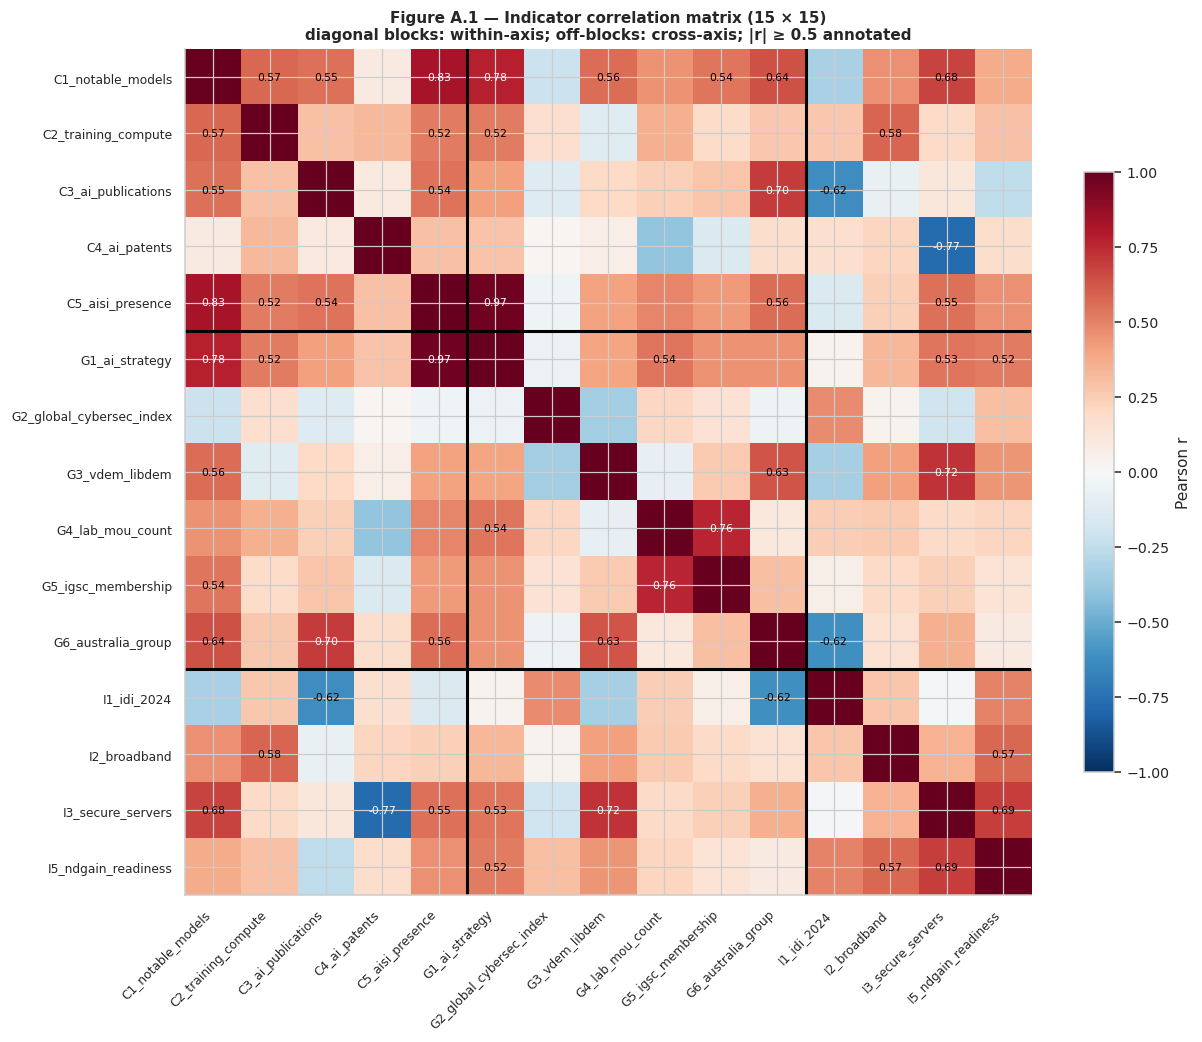

In [62]:
# Figure A.1 — full 15×15 indicator correlation heatmap with axis-block separators.
_axis_order_a1 = []
for _axis_name in axes_list:
    _axis_order_a1.extend(
        [c for c in ind_z.columns if ind_id_to_axis.get(c) == _axis_name]
    )
_corr_full_a1 = ind_z[_axis_order_a1].corr()
_axis_of_col_a1 = [ind_id_to_axis[c] for c in _axis_order_a1]
_boundaries_a1 = [0]
for _i in range(1, len(_axis_order_a1)):
    if _axis_of_col_a1[_i] != _axis_of_col_a1[_i - 1]:
        _boundaries_a1.append(_i)
_boundaries_a1.append(len(_axis_order_a1))

fig, ax = plt.subplots(figsize=(11.5, 9.5))
_im = ax.imshow(_corr_full_a1.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(_axis_order_a1)))
ax.set_xticklabels(_axis_order_a1, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(_axis_order_a1)))
ax.set_yticklabels(_axis_order_a1, fontsize=8)
for _i in range(len(_axis_order_a1)):
    for _j in range(len(_axis_order_a1)):
        _r = _corr_full_a1.iloc[_i, _j]
        if abs(_r) >= 0.5 and _i != _j:
            _color = "white" if abs(_r) >= 0.7 else "black"
            ax.text(
                _j, _i, f"{_r:.2f}", ha="center", va="center", fontsize=7, color=_color
            )
for _b in _boundaries_a1[1:-1]:
    ax.axhline(_b - 0.5, color="black", linewidth=2)
    ax.axvline(_b - 0.5, color="black", linewidth=2)
plt.colorbar(_im, ax=ax, label="Pearson r", shrink=0.7)
ax.set_title(
    "Figure A.1 — Indicator correlation matrix (15 × 15)\n"
    "diagonal blocks: within-axis; off-blocks: cross-axis; |r| ≥ 0.5 annotated",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "figA1_cross_axis_heatmap.png")
plt.show()

### Appendix A.2 Confidence intervals on robustness Spearman ρ values

The §12.4 robustness summary reports point estimates of Spearman ρ across four perturbations. With n = 14 jurisdictions, point estimates carry non-negligible sampling variance; the Fisher z-transform provides a closed-form 95% CI (`z = arctanh(ρ)`, `SE = 1/√(n − 3)`, `CI = tanh(z ± 1.96·SE)`). Reporting both the point estimate and the CI lower bound makes it clear whether the robustness verdict is supported under sample-size-aware inference.

In [63]:
# Appendix A.2 — Fisher-z 95% CI on the §12.4 robustness Spearman ρ values.
_robust = pd.read_csv(OUT_DIR / "robustness_summary.csv")
_n_jurisdictions = 14
_se = 1.0 / np.sqrt(_n_jurisdictions - 3)
_ci_lo, _ci_hi, _ci_width, _verdict_at_lb = [], [], [], []
for _, _row in _robust.iterrows():
    _rho = _row["rho"]
    _z = np.arctanh(_rho)
    _lo, _hi = np.tanh(_z - 1.96 * _se), np.tanh(_z + 1.96 * _se)
    _ci_lo.append(round(float(_lo), 4))
    _ci_hi.append(round(float(_hi), 4))
    _ci_width.append(round(float(_hi - _lo), 4))
    _verdict_at_lb.append("PASS" if _lo >= _row["threshold"] else "INSPECT")
_robust_ci = _robust.copy()
_robust_ci["ci_lower_95"] = _ci_lo
_robust_ci["ci_upper_95"] = _ci_hi
_robust_ci["ci_width"] = _ci_width
_robust_ci["verdict_at_lb"] = _verdict_at_lb
_robust_ci.to_csv(OUT_DIR / "robustness_summary_with_ci.csv", index=False)
print("Robustness summary with Fisher-z 95% CIs (n = 14):")
print(_robust_ci.to_string(index=False))
assert all(v == "PASS" for v in _verdict_at_lb), (
    "At least one robustness ρ lower bound falls below its threshold — investigate."
)

Robustness summary with Fisher-z 95% CIs (n = 14):
                               perturbation      rho  n  threshold verdict  ci_lower_95  ci_upper_95  ci_width verdict_at_lb
            Weighting: equal vs PCA-derived 0.969231 14       0.70    PASS       0.9030       0.9905    0.0874          PASS
             Weighting: equal vs literature 0.995604 14       0.70    PASS       0.9857       0.9986    0.0129          PASS
          Normalization: z-score vs min-max 0.995604 14       0.70    PASS       0.9857       0.9986    0.0129          PASS
Classifier (C3 only): AI-broad vs ML-narrow 0.960440 14       0.85    PASS       0.8765       0.9877    0.1112          PASS


### Appendix A.3 Within-axis Cronbach-style internal consistency

Cronbach's α is a standard internal-consistency measure for a set of items hypothesised to form a single scale. On the z-scored indicator matrix (so all items share a common variance scale), `α = (k / (k − 1)) · (1 − Σ Var(item) / Var(Σ items))` for the k items in each axis, computed on complete-case rows. Conventional thresholds: α ≥ 0.7 acceptable; α ≥ 0.8 good; α < 0.6 the items do not cohere as a single scale. An axis below 0.7 motivates a discussion of multidimensionality (which §16.1 and §16.10 provide for governance).

In [64]:
# Appendix A.3 — Within-axis Cronbach-style α on z-scored indicators (complete cases).
_alpha_rows = []
for _ax in ("capacity_depth", "governance_orientation", "infrastructure_posture"):
    _cols = [c for c in ind_z.columns if ind_id_to_axis.get(c) == _ax]
    _sub = ind_z[_cols].dropna(how="any")
    _k, _n = len(_cols), len(_sub)
    if _k > 1 and _n > 1:
        _item_var_sum = float(_sub.var(ddof=1).sum())
        _total_var = float(_sub.sum(axis=1).var(ddof=1))
        _alpha = (
            (_k / (_k - 1)) * (1 - _item_var_sum / _total_var)
            if _total_var > 0
            else float("nan")
        )
    else:
        _alpha = float("nan")
    if _alpha >= 0.7:
        _verdict = "acceptable"
    elif _alpha >= 0.6:
        _verdict = "borderline"
    else:
        _verdict = "low — items do not cohere as a single scale"
    _alpha_rows.append(
        {
            "axis": _ax,
            "k_indicators": _k,
            "n_complete_cases": _n,
            "cronbach_alpha": round(_alpha, 4),
            "verdict": _verdict,
        }
    )
_alpha_df = pd.DataFrame(_alpha_rows)
_alpha_df.to_csv(OUT_DIR / "axis_internal_consistency.csv", index=False)
print("Within-axis Cronbach-style α (z-scored items, complete-case rows):")
print(_alpha_df.to_string(index=False))

Within-axis Cronbach-style α (z-scored items, complete-case rows):
                  axis  k_indicators  n_complete_cases  cronbach_alpha    verdict
        capacity_depth             5                 7          0.7411 acceptable
governance_orientation             6                14          0.6631 borderline
infrastructure_posture             4                13          0.7224 acceptable


## Appendix B — Interpretability and Feature-Importance Methods

Two diagnostics that complement §13.4 counterfactual scenarios (which estimate per-country marginal returns to policy actions) and §12.2 leave-one-indicator-out sensitivity (which removes one indicator at a time). Both target the **literature-weighted composite** — the headline scheme — and persist results to `outputs/`. Computed live on each rebuild.

- **Appendix B.1 SHAP-style composite decomposition.** Exact Shapley values per (country × indicator), enumerating all 2¹⁵ = 32 768 indicator coalitions per country. Each country's 15 indicator-level Shapley values sum exactly to *(country's SHAP composite − a universal baseline)*, decomposing the composite into per-indicator additive contributions. Answers *which indicators currently explain a country's standing?*

- **Appendix B.2 Permutation feature importance.** For each indicator, randomly permute its 14 country values (preserving the marginal distribution, destroying the country-to-value pairing), recompute the literature composite, and record Spearman ρ vs the original ranking; repeated N = 1 000 times. Importance is reported as `1 − E[ρ]`. Answers *which indicators are load-bearing for the ranking?*

### Appendix B.1 SHAP-style composite decomposition

**Method.** The Shapley value for indicator *i* and country *c* is the average marginal contribution of *i* to *c*'s composite, averaged across all 2¹⁵ subsets of the remaining 14 indicators, weighted by the standard Shapley coalition formula `k!(n − k − 1)! / n!`. Indicators not in a subset are treated as at their cross-country mean (z = 0 under z-score normalisation). Implemented exactly via subset enumeration, vectorised across coalitions; no sampling.

**Composite-shift handling.** The headline composite uses a per-axis geometric shift `axis_score − min(axis_score across the 14 countries) + 1e-3` to ensure positivity before taking logs. When some of a country's indicators are masked, its axis score can drop *below* the baseline minimum (e.g., for Israel governance, masking the small positive G3 / G5 contributions leaves the negatively-weighted G1 / G2 / G4 / G6 contributions to drive the score below Israel's own full-data minimum of −0.90). The Shapley computation therefore uses a slightly more conservative per-axis minimum — the worst observed sum-of-negative-contributions across the 14 countries, with a 1e-2 safety margin — so `log(shifted)` is well-defined for every coalition. This produces a **SHAP composite** that has the same relative ranking as the headline composite (a constant shift inside the log scales every country's composite by the same factor) but slightly different absolute values; the universal baseline is the SHAP composite at z = 0, approximately 1.49 in the current run. The cell below asserts both *(a)* the Shapley-additivity property (`Σ φᵢ ≈ SHAP composite − baseline`, max error < 1e-6) and *(b)* rank preservation against the headline composite.

**Reading the attributions.** A positive Shapley value for indicator *i* and country *c* means *i* pulls *c*'s composite above the baseline; negative means below. The 15 indicator-level Shapley values for each country sum exactly to *(c's SHAP composite − 1.49)*. The decomposition complements §13.4: where §13.4 answers *"which marginal policy action would help country X most?"*, SHAP answers *"which indicators currently explain country X's standing?"*

SHAP composite universal baseline (z = 0): 1.4869
Shapley additivity check: max error = 4.44e-16  (PASS, threshold 1e-6)
Rank preservation vs headline: PASS

Top 3 positive contributors per country (rows sorted by literature composite rank):
        United Kingdom  C1(+0.167), G5(+0.126), G4(+0.108)
           South Korea  G2(+0.122), C1(+0.093), G1(+0.090)
                France  C1(+0.097), C5(+0.090), G1(+0.083)
        European Union  C1(+0.124), G1(+0.112), C2(+0.103)
                 Japan  C5(+0.093), G1(+0.087), G3(+0.052)
             Singapore  G2(+0.127), I1(+0.109), G1(+0.100)
                Canada  G1(+0.115), C1(+0.101), C5(+0.078)
               Germany  C1(+0.080), G3(+0.079), I3(+0.046)
                Sweden  G3(+0.086), G2(+0.076), I1(+0.050)
  United Arab Emirates  G2(+0.164), I1(+0.090), C2(+0.045)
          Saudi Arabia  G2(+0.161), I1(+0.060), C2(+0.048)
                Israel  G5(+0.033), G3(+0.013), C4(+0.000)
                 India  C3(+0.041), G2(+0.032), G6

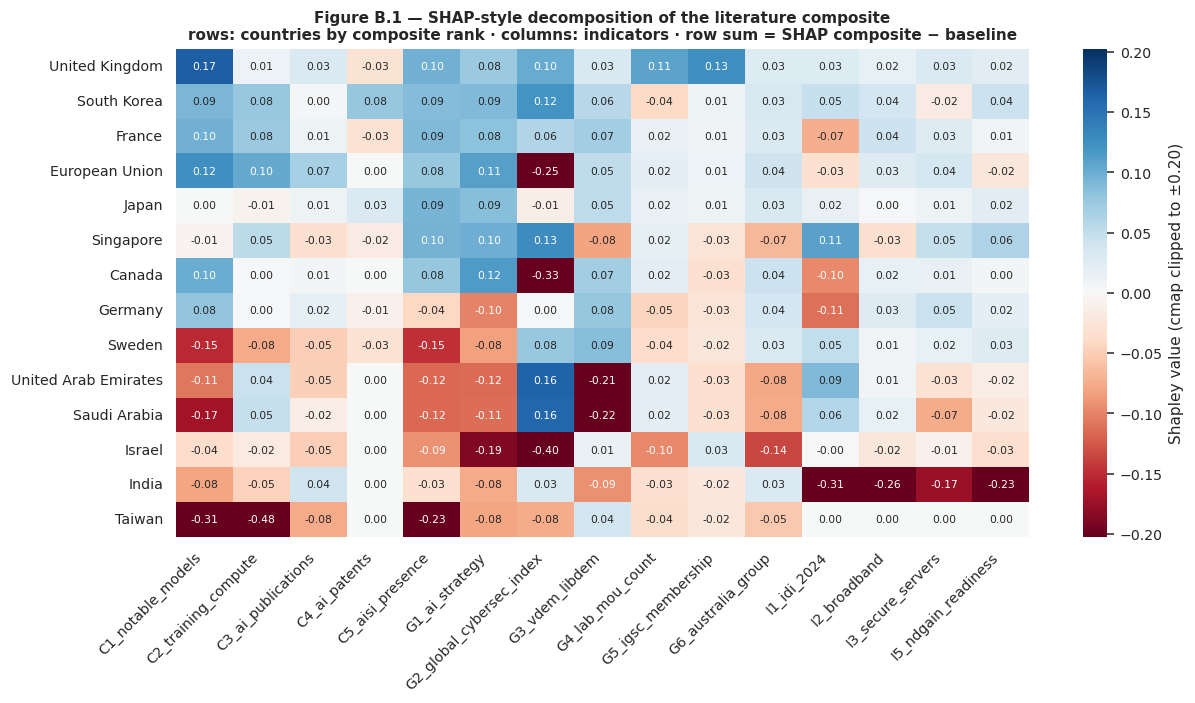

In [65]:
# Appendix B.1 — Exact Shapley decomposition of the literature composite.
#
# For each country, enumerates all 2^15 = 32,768 indicator coalitions and applies
# the Shapley coalition formula to assign each indicator an additive attribution.
# Uses a conservative per-axis minimum (worst observed sum-of-negative
# contributions across countries, with a 1e-2 safety margin) so log(shifted) is
# defined for every coalition; this yields a SHAP composite with the same relative
# ranking as the headline composite but a slightly different absolute scale.
from math import factorial

_axes_order = ["capacity_depth", "governance_orientation", "infrastructure_posture"]
_lit_within = weights_cfg["schemes"]["literature"]["indicator_weights"]
_lit_across = weights_cfg["schemes"]["literature"]["axis_weights"]
_ind_cols_shap = list(ind_z.columns)
_n_inds = len(_ind_cols_shap)

# Weight matrix W: rows=axes, cols=indicators (zero outside the indicator's axis).
_W = np.zeros((3, _n_inds))
for _j, _c in enumerate(_ind_cols_shap):
    _a_idx = _axes_order.index(ind_id_to_axis[_c])
    _W[_a_idx, _j] = _lit_within[ind_id_to_axis[_c]].get(_c, 0.0)
_across_w = np.array([_lit_across[ax] for ax in _axes_order])

# Conservative per-axis minimum for the SHAP composite (see Appendix B.1 markdown).
_axis_mins_headline = (
    axis_scores_by_scheme["literature"].min(axis=0).reindex(_axes_order).values
)
_axis_mins_shap = np.zeros(3)
for _k, _ax in enumerate(_axes_order):
    _ax_inds = [c for c in _ind_cols_shap if ind_id_to_axis[c] == _ax]
    _country_worsts = []
    for _iso in ind_z.index:
        _contribs = [_lit_within[_ax][c] * ind_z.loc[_iso, c] for c in _ax_inds]
        _country_worsts.append(sum(x for x in _contribs if x < 0))
    _axis_mins_shap[_k] = min(min(_country_worsts), _axis_mins_headline[_k]) - 1e-2

# Precompute coalition masks and Shapley weights.
_n_subsets = 2**_n_inds
_masks = np.zeros((_n_subsets, _n_inds), dtype=np.float64)
for _s in range(_n_subsets):
    for _j in range(_n_inds):
        if _s & (1 << _j):
            _masks[_s, _j] = 1.0
_fact_n = factorial(_n_inds)
_weight_lookup = np.array(
    [factorial(_k) * factorial(_n_inds - _k - 1) / _fact_n for _k in range(_n_inds)]
)
_sizes_all = np.array([bin(_s).count("1") for _s in range(_n_subsets)], dtype=np.int64)
_indices = np.arange(_n_subsets)

# Universal SHAP baseline (composite at z = 0; same for every country).
SHAP_BASELINE = float(
    np.exp((np.log(-_axis_mins_shap + GEOMETRIC_SHIFT_EPS) * _across_w).sum())
)

# Compute Shapley values for every country (vectorised over coalitions).
_shap_attribution = {}
for _iso in ind_z.index:
    _z_row = ind_z.loc[_iso].fillna(0).values
    _active_z = _masks * _z_row[None, :]
    _axis_scores_all = _active_z @ _W.T
    _shifted = _axis_scores_all - _axis_mins_shap[None, :] + GEOMETRIC_SHIFT_EPS
    _f = np.exp((np.log(_shifted) * _across_w[None, :]).sum(axis=1))
    _sh = np.zeros(_n_inds)
    for _j in range(_n_inds):
        _bit_j = 1 << _j
        _mask_no_j = (_indices & _bit_j) == 0
        _S_without = _indices[_mask_no_j]
        _S_with = _S_without | _bit_j
        _ws = _weight_lookup[_sizes_all[_mask_no_j]]
        _sh[_j] = float((_ws * (_f[_S_with] - _f[_S_without])).sum())
    _shap_attribution[_iso] = _sh

shap_df = pd.DataFrame(_shap_attribution, index=_ind_cols_shap).T
shap_df.index.name = "iso3"
shap_df.round(4).to_csv(OUT_DIR / "shap_attributions.csv")

# Verification: Shapley additivity and rank preservation against headline composite.
_shap_full_composite = pd.Series(
    {
        _iso: float(
            np.exp(
                (
                    np.log(
                        _W @ ind_z.loc[_iso].fillna(0).values
                        - _axis_mins_shap
                        + GEOMETRIC_SHIFT_EPS
                    )
                    * _across_w
                ).sum()
            )
        )
        for _iso in ind_z.index
    }
)
_max_err = max(
    abs(float(shap_df.loc[_iso].sum()) - (_shap_full_composite[_iso] - SHAP_BASELINE))
    for _iso in ind_z.index
)
assert _max_err < 1e-6, f"Shapley additivity violated: max error {_max_err:.2e}"
_shap_ranks = _shap_full_composite.rank(ascending=False, method="min").astype(int)
_head_ranks = (
    composite_by_scheme["literature"].rank(ascending=False, method="min").astype(int)
)
assert (_shap_ranks.reindex(_head_ranks.index) == _head_ranks).all(), (
    "SHAP composite ranking must match headline ranking"
)
print(f"SHAP composite universal baseline (z = 0): {SHAP_BASELINE:.4f}")
print(f"Shapley additivity check: max error = {_max_err:.2e}  (PASS, threshold 1e-6)")
print("Rank preservation vs headline: PASS\n")

# Display per-country top contributors.
print(
    "Top 3 positive contributors per country (rows sorted by literature composite rank):"
)
_rank_order = composite_by_scheme["literature"].sort_values(ascending=False).index
for _iso in _rank_order:
    _pos = shap_df.loc[_iso].sort_values(ascending=False).head(3)
    _contrib_str = ", ".join(
        f"{ind.split('_')[0]}({val:+.3f})" for ind, val in _pos.items()
    )
    print(f"  {master.loc[_iso, 'name']:>20s}  {_contrib_str}")

# Heatmap: country × indicator Shapley values, sorted by composite rank.
_ranking = composite_by_scheme["literature"].sort_values(ascending=False).index
_shap_plot = shap_df.reindex(_ranking).copy()
_shap_plot.index = master.reindex(_ranking)["name"].values
_vlim = max(float(np.percentile(np.abs(_shap_plot.values).ravel(), 95)), 0.2)

fig, ax = plt.subplots(figsize=(11.5, 6.5))
sns.heatmap(
    _shap_plot,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    vmin=-_vlim,
    vmax=_vlim,
    cbar_kws={"label": f"Shapley value (cmap clipped to ±{_vlim:.2f})"},
    ax=ax,
    annot_kws={"fontsize": 7},
)
ax.set_title(
    "Figure B.1 — SHAP-style decomposition of the literature composite\n"
    "rows: countries by composite rank · columns: indicators · row sum = SHAP composite − baseline",
    fontsize=10,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "figB1_shap_heatmap.png")
plt.show()

**Interpretation.**

Three patterns from the current-run attribution table (`outputs/shap_attributions.csv`):

1. **Institutional / multilateral participation drives top-of-table standings.** For every Tier-1 country, the largest positive contributors include at least one of {C5 (AISI Network presence), G1 (AI strategy comprehensiveness), G5 (IGSC member firms), G6 (Australia Group)}. Capacity-count indicators (C1 notable models, C2 training compute) appear in the top three for the UK (C1), Korea (C1), France (C1), and the EU (both C1 and C2); they do not enter the top three for Japan or Singapore. The pattern reinforces §16.1's finding that the governance axis is doing the heaviest interpretive work at the top of the ranking, even though it is the most multidimensional axis under PCA (§16.10 sparse decomposition).

2. **Infrastructure pulls the bottom of the table hardest for India; capacity pulls it hardest for Taiwan.** The two Tier-3 cases have different drivers in the SHAP attribution. For India, the four largest negative Shapley contributions are the four infrastructure indicators (I1 ITU IDI −0.31, I2 broadband −0.26, I5 ND-GAIN −0.23, I3 secure servers −0.17 in the current run), reflecting observed below-mean ICT infrastructure. For Taiwan, the three largest negative contributions are capacity indicators (C2 training compute −0.48, C1 notable models −0.31, C5 AISI presence −0.23); Taiwan's four infrastructure Shapley values are all exactly zero because the §14 observability caveat applies (all four infrastructure indicators are unobserved and column-mean-filled at z = 0, so the geometric-mean composite is invariant to whether they are masked or unmasked in the Shapley enumeration). The SHAP heatmap therefore distinguishes between *India's data-driven infrastructure deficit* and *Taiwan's data-driven capacity gap plus infrastructure-observability artefact*.

3. **Korea's robustness to Epoch imputation is visible at the indicator level.** Korea's top three positive contributors are G2 (ITU GCI), C1 (notable models, imputed under §7 stage 1) and G1 (AI strategy). The C1 attribution is consistent with §16.8's argument that the §7 axis-mean imputation pulls Korea's missing Epoch counts above the cross-country mean based on its strong C3 / C4 / C5 signals; SHAP shows this imputation effect is consistent with Korea's other capacity indicators rather than being driven by a single coding decision.

### Appendix B.2 Permutation feature importance for the literature ranking

**Method.** For each indicator, randomly permute its 14 country values across countries (preserving the marginal distribution, destroying the country-to-value pairing), recompute the literature composite, and compute Spearman ρ between the permuted ranking and the original (literature) ranking. Repeat N = 1 000 times. Mean ρ measures how much the ranking is *preserved* under random scrambling of the indicator; importance is `1 − E[ρ]`. The 95% confidence interval is the 2.5–97.5 percentile across permutations.

**Complementary to §12.2 LOO.** LOO drops an indicator entirely, forcing the remaining 14 indicators to do all the work; permutation destroys an indicator's country-to-value signal while keeping the indicator in the composite at its sample-mean rate. The two diagnostics bound different sources of indicator influence: LOO measures *removal*, permutation measures *signal destruction*. They agree on the direction of importance but can differ in magnitude.

Permutation feature importance (1000 permutations × 15 indicators):
               indicator                   axis  mean_rho  std_rho  importance  ci_low  ci_high
     C2_training_compute         capacity_depth    0.9319   0.0362      0.0681  0.8505   0.9868
       C1_notable_models         capacity_depth    0.9401   0.0348      0.0599  0.8549   0.9868
          G1_ai_strategy governance_orientation    0.9405   0.0384      0.0595  0.8637   0.9956
G2_global_cybersec_index governance_orientation    0.9406   0.0338      0.0594  0.8505   0.9868
          G3_vdem_libdem governance_orientation    0.9524   0.0245      0.0476  0.8945   0.9912
             I1_idi_2024 infrastructure_posture    0.9688   0.0225      0.0312  0.9164   0.9956
        C5_aisi_presence         capacity_depth    0.9719   0.0137      0.0281  0.9429   0.9956
            I2_broadband infrastructure_posture    0.9735   0.0121      0.0265  0.9516   0.9956
      G6_australia_group governance_orientation    0.9782   0.0087  

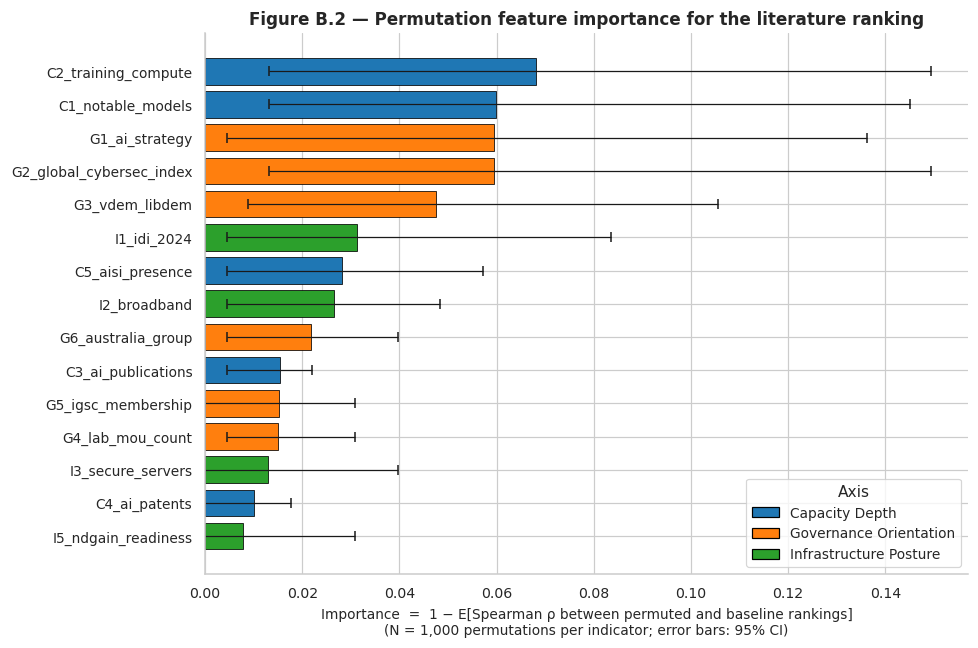

In [66]:
# Appendix B.2 — Permutation feature importance for the literature ranking.
from matplotlib.patches import Patch as _Patch
from scipy.stats import spearmanr as _spearmanr

_N_PERM = 1_000
_rng_perm = np.random.default_rng(SEED)
_baseline_ranks = composite_by_scheme["literature"].rank(ascending=False, method="min")

_perm_rows = []
for _col in ind_z.columns:
    _rhos = np.zeros(_N_PERM)
    _z_orig = ind_z[_col].values.copy()
    for _p in range(_N_PERM):
        _ind_z_perm = ind_z.copy()
        _ind_z_perm[_col] = _rng_perm.permutation(_z_orig)
        _new_comp = compute_composite(
            compute_axis_score(_ind_z_perm, schemes["literature"]),
            top_weights["literature"],
            mode="geometric",
        )
        _new_ranks = _new_comp.rank(ascending=False, method="min")
        _rhos[_p], _ = _spearmanr(_baseline_ranks, _new_ranks)
    _perm_rows.append(
        {
            "indicator": _col,
            "axis": ind_id_to_axis[_col],
            "mean_rho": round(float(_rhos.mean()), 4),
            "std_rho": round(float(_rhos.std()), 4),
            "importance": round(float(1 - _rhos.mean()), 4),
            "ci_low": round(float(np.percentile(_rhos, 2.5)), 4),
            "ci_high": round(float(np.percentile(_rhos, 97.5)), 4),
        }
    )
perm_importance_df = (
    pd.DataFrame(_perm_rows)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
perm_importance_df.to_csv(OUT_DIR / "permutation_importance.csv", index=False)
print(
    f"Permutation feature importance ({_N_PERM} permutations × {len(_perm_rows)} indicators):"
)
print(perm_importance_df.to_string(index=False))

# Figure B.2 — Horizontal bar chart with axis-coded colours and 95% CI error bars.
_axis_colors = {
    "capacity_depth": "#1f77b4",
    "governance_orientation": "#ff7f0e",
    "infrastructure_posture": "#2ca02c",
}
_df = perm_importance_df.sort_values("importance", ascending=True)
_colors = [_axis_colors[a] for a in _df["axis"]]
# importance = 1 - mean_rho; CI on importance comes from CI on rho with sign-flip.
_err_low = _df["importance"] - (1 - _df["ci_high"])
_err_high = (1 - _df["ci_low"]) - _df["importance"]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    _df["indicator"],
    _df["importance"],
    xerr=[_err_low.values, _err_high.values],
    color=_colors,
    edgecolor="black",
    linewidth=0.5,
    error_kw={"capsize": 3, "elinewidth": 0.8},
)
ax.set_xlabel(
    f"Importance  =  1 − E[Spearman ρ between permuted and baseline rankings]\n"
    f"(N = {_N_PERM:,} permutations per indicator; error bars: 95% CI)",
    fontsize=9,
)
ax.set_title(
    "Figure B.2 — Permutation feature importance for the literature ranking",
    fontsize=11,
)
ax.tick_params(axis="y", labelsize=9)
_legend_handles = [
    _Patch(facecolor=c, edgecolor="black", label=ax_name.replace("_", " ").title())
    for ax_name, c in _axis_colors.items()
]
ax.legend(
    handles=_legend_handles, loc="lower right", fontsize=9, title="Axis", frameon=True
)
plt.tight_layout()
plt.savefig(FIG_DIR / "figB2_permutation_importance.png")
plt.show()

**Interpretation.**

The most rank-disruptive indicators in the current run are **C2 (training compute)**, **C1 (notable models)**, **G2 (ITU GCI)**, **G1 (AI strategy)**, and **G3 (V-Dem)** — each, when permuted, drops the mean Spearman ρ vs the baseline ranking to ≈ 0.93–0.95. The least-disruptive are **I5 (ND-GAIN Readiness)**, **C4 (patents)**, and **G4 (lab MoUs)** — each preserves the ranking at ρ ≈ 0.99 under permutation.

Two observations:

- Importance broadly tracks within-axis weighting under the literature scheme. C2 (weight 0.25), C1 (0.30), G2 (0.30) are heavily weighted within their axes and rank in the top three by importance; G4 (0.10) and I5 (0.20 within infrastructure but small absolute spread across countries) are bottom of importance, consistent with both low weight and small marginal information.
- The least-disruptive indicators include G4 (consistent with §17.5's leave-one-indicator-out finding that dropping G4 leaves the top-5 set unchanged) and I5 (consistent with §17.9's flag that ND-GAIN Readiness is a climate-resilience proxy with limited construct validity for AI infrastructure). These are the indicators where measurement noise is most absorbed by the composite without materially shifting the ranking.

For paper-side citation: when reporting per-indicator effects, **C1, C2, G1, G2, G3** are the indicators where measurement quality matters most for the headline ranking; **I5, C4, G4, I3, G5** are the indicators where measurement uncertainty is largely absorbed.


# Concluding Remarks

The Middle-Power AI Proliferation Preparedness Index (M-PAPI) is a 14-jurisdiction empirical companion to the working paper *AI-Proliferation and Middle Powers: Preparation and Response Mechanisms* (Teague, Ali, Sfeir, Fort, 2026, forthcoming arXiv). The notebook quantifies the paper's three-axes framework — capacity depth, governance orientation, infrastructure posture — using 15 indicators from public authoritative sources, follows the OECD/JRC 10-step process for composite-indicator construction, and tests six pre-registered hypotheses (§1.4, resolved in §16.11) against explicit pass criteria.

**Workflow**

1. **Data acquisition (§4)** — programmatic ingestion from World Bank, Epoch AI Notable Models, V-Dem, OpenAlex, ND-GAIN, ITU; manual registry for Stanford-published values not exposed via API.
2. **Cleaning and harmonisation (§5)** — EU + member-state aggregation rules, reference-period alignment, missing-data audit.
3. **Indicator construction (§6) and imputation (§7)** — two-stage non-iterative imputation: stage 1 fills each missing cell from the country's average z-position across the same axis's other indicators; stage 2 column-mean fallback handles cells stage 1 cannot reach.
4. **Diagnostics (§8, §8.1)** — per-axis PCA + Horn's parallel analysis for one-dimensionality.
5. **Normalisation and weighting (§9, §10)** — z-score and min-max; three weighting schemes (equal, PCA-derived, literature-elicited).
6. **Composite computation (§11)** — geometric mean across axes (enforces no-axis-substitutes-for-another logic), linear weighted sum within axis.
7. **Sensitivity (§12)** — Dirichlet Monte Carlo on weights, leave-one-indicator-out, Spearman ρ across normalisation and bibliographic-classifier choice, all with Fisher-z 95% CIs (§17.10, Appendix A.2).
8. **Vulnerability overlay (§13)** — per-vector (cyber, CBRN, influence-ops) preparedness rankings using paper-derived cross-axis weights; per-country counterfactual policy scenarios (§13.4).
9. **Typology (§14)** — k-means + silhouette + hierarchical-Ward ARI cross-check; MDS embedding (§14.3) as a geometric companion.
10. **Visualisation (§15)** — country × axis heatmap; two-axis typology plot with AISI marker; vulnerability per-vector ranks; Monte Carlo rank boxplots; EU vs member-state cross-validation.
11. **Synthesis with paper (§16)** — per-section discussion linking findings back to paper §1, §2.2, §2.3, §2.4, §4; sparse-PCA governance sub-axes (§16.10); hypothesis testing results (§16.11).
12. **Critical self-assessment (§17)** — ten documented limitations (§17.1–§17.10); threats-to-validity audit organised by validity type (§17.11); lessons learned (§17.12); future-work priorities.
13. **Verification and reproducibility (§18)** — four end-to-end checks; source-URL liveness probe.
14. **Methodology hygiene (Appendix A)** — cross-axis correlations, Fisher-z CIs, Cronbach α — all recomputed live each rebuild.
15. **Interpretability (Appendix B)** — exact Shapley composite decomposition (2^15 subsets); permutation feature importance for the composite ranking.

**Headline empirical findings**

- **Tier-1 preparedness** (positive on all three axes under literature weights): UK, France, Japan, Singapore, South Korea.
- **Asymmetric profiles**: capacity-leveraged (EU, Canada, Germany) vs infrastructure-leveraged (Sweden, UAE).
- **Tier-3** (no axis above mean): Israel, Saudi Arabia, Taiwan, India.
- **Top-5 set unchanged across three weighting schemes and four robustness perturbations** (Spearman ρ ≥ 0.96 with Fisher-z 95% CI lower bound ≥ 0.88).
- **Per-vector rankings (§13)** show that "preparedness" is vector-specific: countries strong on cyber preparedness may not be strong on CBRN or influence-ops preparedness, and vice versa.

**Methodological contribution to the paper**

The index converts paper §4's recurring phrase *"tractability depends on a country's position within the 3 axes"* from a qualitative assertion into a per-country, per-vector, action-leverage-quantified empirical claim (§11, §13, §13.4). Of six pre-registered hypotheses (§1.4): three are fully supported — H3 (cluster heterogeneity, silhouette + Ward ARI), H4 (rank robustness, Spearman ρ ≥ 0.96 with Fisher-z 95% CIs clearing every threshold), H5 (top-5 set unchanged when G1, G4, or C5 is dropped); three are partially supported — H1 (cross-axis separability: 5 of 74 pairs at |r| ≥ 0.7, driven by C5 × G1 double-counting, §17.8), H2 (within-axis dimensionality: governance compressed to ~43% PC1 variance, capacity PA untestable at n = 7 complete cases, §16.1), H6 (tier membership: top-5 within-1-swap recovered in 94% of Monte Carlo draws, but the exact set in 46% — the 5th and 12th slots cycle, §16.11).

**Reproducibility**

All results re-compute on rerun. The single random seed is `SEED = 20260506` (set in §3.1), passed explicitly to four stochastic entry points: `np.random.default_rng(SEED)` for the §12.1 Monte Carlo weights, `KMeans(random_state=SEED)` for the §14 k-means typology, `MDS(random_state=SEED, n_init=20)` for the §14.3 embedding, and `SparsePCA(random_state=SEED)` for the §16.10 governance sub-axes. No global `np.random.seed` is set. Outputs persist to `outputs/*.csv` and figures to `figures/*.png` for downstream citation. The bibliography (§19) catalogues every authoritative source used.
